# 🛒 온라인 채널 제품 판매량 예측
https://dacon.io/competitions/official/236129/data

> **모델 전략:** 7개 모델 실험 및 앙상블 (기존3 + LightGBM + Attention + N-HiTS + TFT)
> **입력:** 과거 28일 시퀀스 → **출력:** 미래 21일 판매량 (Direct Multi-Step)

───────────────────────────────────────────────

## 📌 프로젝트 목적
과거의 제품 판매량, 브랜드 검색량(Keyword) 등의 시계열 데이터를 활용하여 향후 21일간의 제품별 판매량을 예측하는 머신러닝/딥러닝 모델 구축

> **예측 대상:** 약 15,890개 제품의 **미래 21일** 일별 판매 수량 
> **학습 데이터:** 2022-01-01 ~ 2023-04-04 (459일치) 
> **예측 기간:** 2023-04-05 ~ 2023-04-25 (21일) (DACON)

> **Train:** 2022-01-01 ~ 2023-03-14  (438일, 학습)  
> **Val:** 2023-03-15 ~ 2023-04-04  (21일, 튜닝·조기종료)  
> **제출(진짜 test):** 2023-04-05 ~ 2023-04-25  (21일)

───────────────────────────────────────────────

## 📋 프로젝트 완료 요약 (전체 목차)

| STEP | 내용 | 
|------|------|
| **STEP 1** | 환경 설정 및 데이터 로드 | 
| **STEP 2** | EDA + 시각화 (13개 분석) | 
| **STEP 3** | 전처리 (8개 처리, 회복기 피처 포함) | 
| **STEP 4** | 특성공학 + Train/Val 분리 + 정규화 | 
| **STEP 5** | 모델링 7개 실험 (기존3 + LightGBM + Attention + N-HiTS + TFT) | 
| **STEP 6** | Optuna 하이퍼파라미터 튜닝 (LGB 100회 + DL 30회) | 
| **STEP 7** | 앙상블 + 후처리 + 제출 파일 생성 |

---
## STEP 1 — 환경 설정 및 데이터 로드

In [1]:
import os
import sys
import gc
import warnings
import subprocess
import platform
from pathlib import Path

# ── 0. 파이토치 메모리 최적화 ───────────────────────────────────────────
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128,garbage_collection_threshold:0.6'

# ── 1. 라이브러리 자동 설치 및 임포트 ───────────────────────────────────
print("⏳ 필수 라이브러리 확인 중...")
REQUIRED_PKGS = ["holidays", "statsmodels"]
for pkg in REQUIRED_PKGS:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

print('✅ 라이브러리 준비 완료')

# ── 2. 한글 폰트 및 시각화 설정 ────────────────────────────────────────
from korean_font import set_korean_font
set_korean_font()

warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'jpeg'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 3. 시드 고정 — 누가 돌려도 같은 결과 ────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'🎲 시드 고정: {SEED}')

# ── 4. 경로 설정 ────────────────────────────────────────────────────────
HOME       = os.getcwd()
DATA_DIR   = os.path.join(HOME, 'data')
OUTPUT_DIR = os.path.join(HOME, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'📁 HOME: {HOME}')
print(f'📁 DATA: {DATA_DIR}')
print(f'📁 OUT : {OUTPUT_DIR}')

# ── 5. GPU 설정 (초기화는 데이터 로드 후로 지연) ────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🎯 DEVICE = {DEVICE}  (GPU 초기화는 데이터 로드 후에 함)')

⏳ 필수 라이브러리 확인 중...
✅ 라이브러리 준비 완료
한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)
🎲 시드 고정: 42
📁 HOME: g:\다른 컴퓨터\내 컴퓨터\github\Sales\Team
📁 DATA: g:\다른 컴퓨터\내 컴퓨터\github\Sales\Team\data
📁 OUT : g:\다른 컴퓨터\내 컴퓨터\github\Sales\Team\output
🎯 DEVICE = cpu  (GPU 초기화는 데이터 로드 후에 함)


In [2]:
# ── 6. 데이터 로드 및 칼럼(변수) 분리 ───────────────────────────────────
# 데이터를 불러오고, '정보(Meta)'와 '시계열 수치(Date)'를 미리 분리해 둡니다.
train      = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
sales      = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'))
product    = pd.read_csv(os.path.join(DATA_DIR, 'product_info.csv'))
keyword    = pd.read_csv(os.path.join(DATA_DIR, 'brand_keyword_cnt.csv'))
submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

# 나중에 데이터 다루기 편하도록 이름표(리스트) 미리 묶어두기
META_COLS  = ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']
DATE_COLS  = [c for c in train.columns if c not in META_COLS]
KW_COLS    = [c for c in keyword.columns if c != '브랜드']
PRED_DATES = [c for c in submission.columns if c != 'ID']

print('=' * 55)
print(f'📊 train.csv   : {train.shape[0]:,}행 × {train.shape[1]}열')
print(f'📊 sales.csv   : {sales.shape[0]:,}행 × {sales.shape[1]}열')
print(f'📊 product.csv : {product.shape[0]:,}행 × {product.shape[1]}열')
print(f'📊 keyword.csv : {keyword.shape[0]:,}행 × {keyword.shape[1]}열')
print('=' * 55)
print(f'📅 학습 기간   : {DATE_COLS[0]}  ~  {DATE_COLS[-1]}  ({len(DATE_COLS)}일)')
print(f'🎯 예측 기간   : {PRED_DATES[0]}  ~  {PRED_DATES[-1]}  ({len(PRED_DATES)}일)')
print('=' * 55)

# ── 7. 데이터 메모리 다이어트 (Downcasting) ─────────────────────────────
# 64비트(큰 방)에 들어있는 데이터를 32비트(작은 방)로 옮겨서 RAM 용량을 확보합니다.
before_mb = sum(d.memory_usage(deep=True).sum() for d in [train, sales, keyword]) / 1024**2

for data in [train, sales, keyword, submission]:
    for col in data.columns:
        # 정수형 다이어트
        if data[col].dtype == 'int64':
            data[col] = data[col].astype('int32')
        # 실수형 다이어트
        elif data[col].dtype == 'float64':
            data[col] = data[col].astype('float32')

after_mb = sum(d.memory_usage(deep=True).sum() for d in [train, sales, keyword]) / 1024**2
print(f'💾 메모리 최적화: {before_mb:.1f}MB → {after_mb:.1f}MB ({(1-after_mb/before_mb)*100:.0f}% 절감)')

# 메모리 다이어트 과정에서 생긴 쓸데없는 찌꺼기(가비지) 청소!
gc.collect()

# 데이터가 잘 들어왔는지 메타 정보와 첫 3일치 데이터만 살짝 확인
train[META_COLS + DATE_COLS[:3]].head(3)

📊 train.csv   : 15,890행 × 465열
📊 sales.csv   : 15,890행 × 465열
📊 product.csv : 12,778행 × 2열
📊 keyword.csv : 3,170행 × 460열
📅 학습 기간   : 2022-01-01  ~  2023-04-04  (459일)
🎯 예측 기간   : 2023-04-05  ~  2023-04-25  (21일)
💾 메모리 최적화: 133.5MB → 72.2MB (46% 절감)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0


In [3]:
# ── 8. GPU 최종 점검 및 초기화 ──────────────────────────────────────────
# 데이터를 다 불러오고 메모리 다이어트까지 끝낸 지금! 드디어 GPU 상태를 확인합니다.
# 본격적인 모델링에 들어가기 전에, GPU 캐시(임시 저장소)를 싹 비워 쾌적하게 만듭니다.
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    props    = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / 1024**3
    print(f'✅ {props.name}  |  총 {total_gb:.1f}GB')
else:
    print('⚠️ CPU 모드')

⚠️ CPU 모드


---
## STEP 2 — 탐색적 데이터 분석 (EDA) + 시각화

EDA의 목적은 단순히 데이터를 '보는' 것이 아닙니다.  
**"이 데이터를 어떻게 전처리하고, 어떤 피처를 만들 것인가"** 를 결정하기 위한 근거를 쌓는 과정입니다.

| # | 질문 | 전처리 영향 |
|---|------|-----------|
| 2-1 | 기본 통계: 제품 수, 카테고리 구조? | 임베딩 차원 설계 |
| 2-2 | 판매량 분포: 어떻게 퍼져 있나? | Log 변환 필요 여부 |
| 2-3 | 일별 트렌드: 이상 구간이 있나? | 급락 구간 처리 방법 결정 |
| 2-4 | 요일·월별 패턴: 특정 날에 더 많이 파나? | 날짜 피처 설계 |
| 2-5 | Spike(이상치): 극단값이 있나? | 클리핑 처리 여부 |
| 2-6 | 0의 종류: 모든 0이 같은 의미인가? | 구조적 0 제거 여부 |
| 2-7 | 브랜드 검색량: 판매 예측에 도움이 되나? | 검색량 피처 채택 여부 |
| 2-8~11 | 시계열 심화: ACF/PACF, CCF, STL, ADF | Lag 피처 설계, 차분 여부 |
| 2-12~13 | 시즌성 히트맵, 공휴일 | 이벤트 피처 설계 |

### 🔧 함수 선언 — `short_label()`

카테고리 코드(`B002-C001-0002`)는 길어서 그래프 x축이 겹칩니다.  
마지막 숫자만 추출해 `대2`, `중11`, `소38`처럼 짧게 만드는 함수입니다.  
이 함수는 **2-1 카테고리 시각화부터 2-12 히트맵까지** 공통으로 사용됩니다.

In [4]:
# ── short_label() : 카테고리 코드를 짧은 레이블로 변환 ────────────────────
# 예) 'B002-C001-0002' → '대2' / 'B002-C003-0038' → '소38'
def short_label(code_str, prefix):
    """카테고리 코드 마지막 숫자만 추출해 짧은 레이블 반환"""
    number = code_str.split('-')[-1].lstrip('0') or '0'
    return f'{prefix}{number}'

# ── 전역 레이블 딕셔너리 — 이후 모든 그래프에서 공용 사용  ────────────────────
cat_labels = {}
for col, prefix in [('대분류', '대'), ('중분류', '중'), ('소분류', '소')]:
    cat_labels[col] = {
        code_str: short_label(code_str, prefix)
        for code_str in train[col].unique()
    }

# ── 변환 결과 확인 ────────────────────
for col in ['대분류', '중분류', '소분류']:
    items  = list(cat_labels[col].items())[:3]
    sample = '  /  '.join(f'{k} → {v}' for k, v in items)
    print(f'[{col}] 예시: {sample}  ... (총 {len(cat_labels[col])}개)')

[대분류] 예시: B002-C001-0002 → 대2  /  B002-C001-0003 → 대3  /  B002-C001-0001 → 대1  ... (총 5개)
[중분류] 예시: B002-C002-0007 → 중7  /  B002-C002-0008 → 중8  /  B002-C002-0001 → 중1  ... (총 11개)
[소분류] 예시: B002-C003-0038 → 소38  /  B002-C003-0044 → 소44  /  B002-C003-0003 → 소3  ... (총 53개)


### 2-1. 기본 통계 + 카테고리 구조 시각화

In [5]:
# ── 기본 통계 수치 출력 ────────────────────────────────────────────────────
print('=' * 55)
print('📌 제품 카테고리 구조')
print('=' * 55)
print(f"  전체 제품(행) 수  : {train['제품'].nunique():>6,}개")
print(f"  브랜드 수         : {train['브랜드'].nunique():>6,}개")
print(f"  대분류 수         : {train['대분류'].nunique():>6}개")
print(f"  중분류 수         : {train['중분류'].nunique():>6}개")
print(f"  소분류 수         : {train['소분류'].nunique():>6}개")

qty_all = train[DATE_COLS].values.flatten()

print()
print('=' * 55)
print('📊 판매량(qty) 전체 통계')
print('=' * 55)
print(f'  전체 데이터 셀 수        : {len(qty_all):>12,}개')
print(f'  판매량 = 0인 셀 (비율)   : {(qty_all==0).sum():>12,}개 ({(qty_all==0).mean():.1%})')
print(f'  판매량 > 0인 셀 (비율)   : {(qty_all>0).sum():>12,}개 ({(qty_all>0).mean():.1%})')
print(f'  전체 중앙값              : {np.median(qty_all):>12.1f}')
print(f'  판매>0인 날 평균         : {qty_all[qty_all>0].mean():>12.1f}')
print(f'  판매>0인 날 중앙값       : {np.median(qty_all[qty_all>0]):>12.1f}')
print(f'  최대값                   : {qty_all.max():>12,}')

📌 제품 카테고리 구조
  전체 제품(행) 수  : 15,840개
  브랜드 수         :  3,170개
  대분류 수         :      5개
  중분류 수         :     11개
  소분류 수         :     53개

📊 판매량(qty) 전체 통계
  전체 데이터 셀 수        :    7,293,510개
  판매량 = 0인 셀 (비율)   :    4,652,860개 (63.8%)
  판매량 > 0인 셀 (비율)   :    2,640,650개 (36.2%)
  전체 중앙값              :          0.0
  판매>0인 날 평균         :         48.8
  판매>0인 날 중앙값       :          7.0
  최대값                   :      200,420


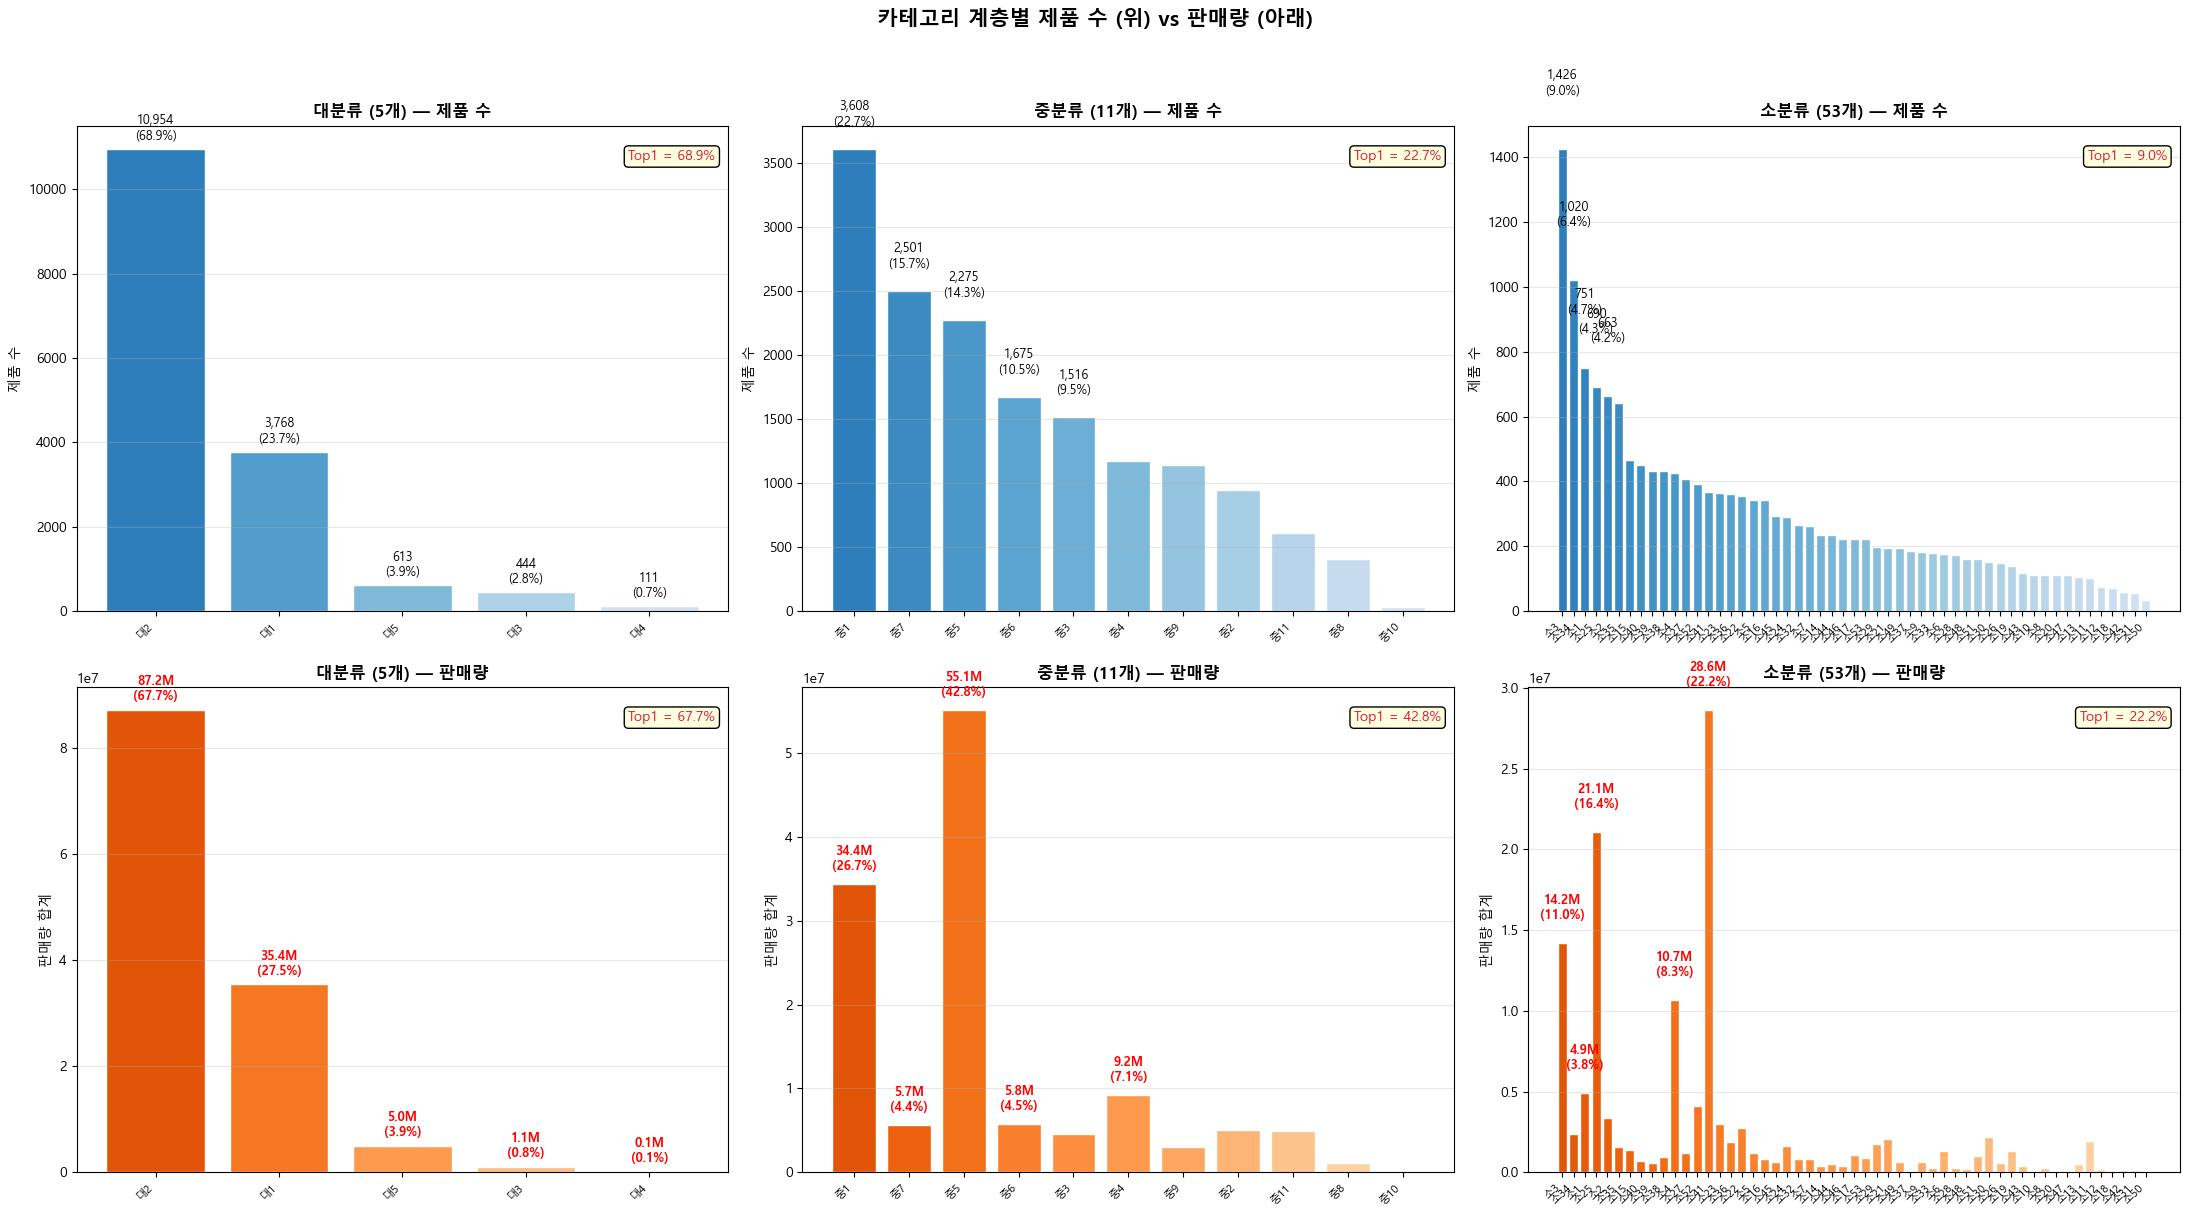

📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개

[대분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
대2  10954      68.9  87218401     67.7
대1   3768      23.7  35441662     27.5
대5    613       3.9   4961560      3.9
대3    444       2.8   1078827      0.8
대4    111       0.7     85411      0.1

[중분류]
     제품수  제품수비율(%)       판매량  판매비율(%)
중5  2275      14.3  55131807     42.8
중1  3608      22.7  34420592     26.7
중4  1168       7.4   9203982      7.1
중6  1675      10.5   5798762      4.5
중7  2501      15.7   5671077      4.4

[소분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
소41   366       2.3  28636033     22.2
소25   690       4.3  21097753     16.4
소3   1426       9.0  14227803     11.0
소4    426       2.7  10673098      8.3
소1    751       4.7   4923380      3.8


In [6]:
# ── 카테고리별 제품 수(위) vs 판매량(아래) 2×3 시각화 ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('카테고리 계층별 제품 수 (위) vs 판매량 (아래)',
             fontsize=15, fontweight='bold', y=1.01)

cats = ['대분류', '중분류', '소분류']

for col_idx, col in enumerate(cats):
    ax_top    = axes[0][col_idx]
    ax_bottom = axes[1][col_idx]

    product_cnt   = train[col].value_counts().sort_values(ascending=False)
    sales_by_cat  = train.groupby(col)[DATE_COLS].sum().sum(axis=1).reindex(product_cnt.index)
    n             = len(product_cnt)
    total_product = product_cnt.sum()
    total_sales   = sales_by_cat.sum()
    xlabels       = [cat_labels[col].get(name, name) for name in product_cnt.index]

    # ── 위: 제품 수 ────────────────────────────────────────────────────────
    colors_top = plt.cm.Blues_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_top   = ax_top.bar(range(n), product_cnt.values, color=colors_top, edgecolor='white')
    
    for j, (bar, val) in enumerate(zip(bars_top, product_cnt.values)):
        if j < 5:  # 상위 5개까지만 텍스트 표시
            # 💡 [핵심 변경 포인트] 비율 계산 후 줄바꿈(\n)으로 추가
            pct = (val / total_product) * 100
            ax_top.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + total_product * 0.01,
                        f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
            
    top1_pct = product_cnt.values[0] / total_product * 100
    ax_top.text(0.98, 0.95, f'Top1 = {top1_pct:.1f}%',
                transform=ax_top.transAxes, ha='right', va='top', fontsize=10,
                color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_top.set_title(f'{col} ({n}개) — 제품 수', fontsize=12, fontweight='bold')
    ax_top.set_ylabel('제품 수')
    ax_top.set_xticks(range(n))
    ax_top.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_top.grid(alpha=0.3, axis='y')
    
    # ── 아래: 판매량 ────────────────────────────────────────────────────────
    colors_bot = plt.cm.Oranges_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_bot   = ax_bottom.bar(range(n), sales_by_cat.values, color=colors_bot, edgecolor='white')
    
    # 💡 [핵심 변경 포인트 1] 판매량 기준으로 진짜 Top 5인 카테고리를 미리 뽑아둠!
    top5_sales_cats = sales_by_cat.sort_values(ascending=False).head(5).index

    for j, (bar, val) in enumerate(zip(bars_bot, sales_by_cat.values)):
        current_cat = sales_by_cat.index[j] # 지금 순서를 돌고 있는 막대의 카테고리 이름
        
        # 무조건 왼쪽 5개가 아니라, 현재 카테고리가 '판매량 Top 5' 안에 속할 때만 %를 달아라!
        if current_cat in top5_sales_cats: 
            pct = (val / total_sales) * 100
            ax_bottom.text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + total_sales * 0.01,
                           f'{val/1e6:.1f}M\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9,
                           color='red', fontweight='bold') # 👈 눈에 확 띄게 빨간색 굵은 글씨로 포인트!
                           
    # 💡 [핵심 변경 포인트 2] 무조건 0번 자리가 아니라, .max()를 써서 진짜 판매량 1등을 찾는다!
    real_top1_sales = sales_by_cat.max()
    top1_sales_pct = (real_top1_sales / total_sales) * 100
    
    ax_bottom.text(0.98, 0.95, f'Top1 = {top1_sales_pct:.1f}%',
                   transform=ax_bottom.transAxes, ha='right', va='top', fontsize=10,
                   color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_bottom.set_title(f'{col} ({n}개) — 판매량', fontsize=12, fontweight='bold')
    ax_bottom.set_ylabel('판매량 합계')
    ax_bottom.set_xticks(range(n))
    ax_bottom.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_bottom.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────────────────────
print('=' * 60)
print('📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개')
print('=' * 60)
for col in cats:
    print(f'\n[{col}]')
    product_cnt  = train[col].value_counts()
    sales_by_cat = train.groupby(col)[DATE_COLS].sum().sum(axis=1)
    summary = pd.DataFrame({
        '제품수'        : product_cnt,
        '제품수비율(%)' : (product_cnt / product_cnt.sum() * 100).round(1),
        '판매량'        : sales_by_cat,
        '판매비율(%)'   : (sales_by_cat / sales_by_cat.sum() * 100).round(1),
    }).sort_values('판매량', ascending=False).head(5)
    summary.index = [cat_labels[col].get(i, i) for i in summary.index]
    print(summary.to_string())

💬 2-1 해석 — 카테고리 불균형이 모델 설계에 미치는 영향

| 카테고리 | 제품수 비율 | 판매 비율 | 해석 |
|---------|-----------|---------|------|
| 대분류 대2 | ~69% | ~68% | 두 비율 유사 → 카테고리 간 불균형 적음 |
| 중분류 상위 | 낮음 | 높음 | 제품은 적은데 판매 압도적 → 핵심 카테고리 |
| 소분류 상위 | 매우 낮음 | 높음 | 소수 스타 카테고리 존재 |

**→ 모델링 활용:** 카테고리별 판매 편차가 크므로 임베딩 레이어로 카테고리 정보를 강하게 반영해야 함

### 2-2. 판매량 분포 — Long Tail + 로렌츠 곡선

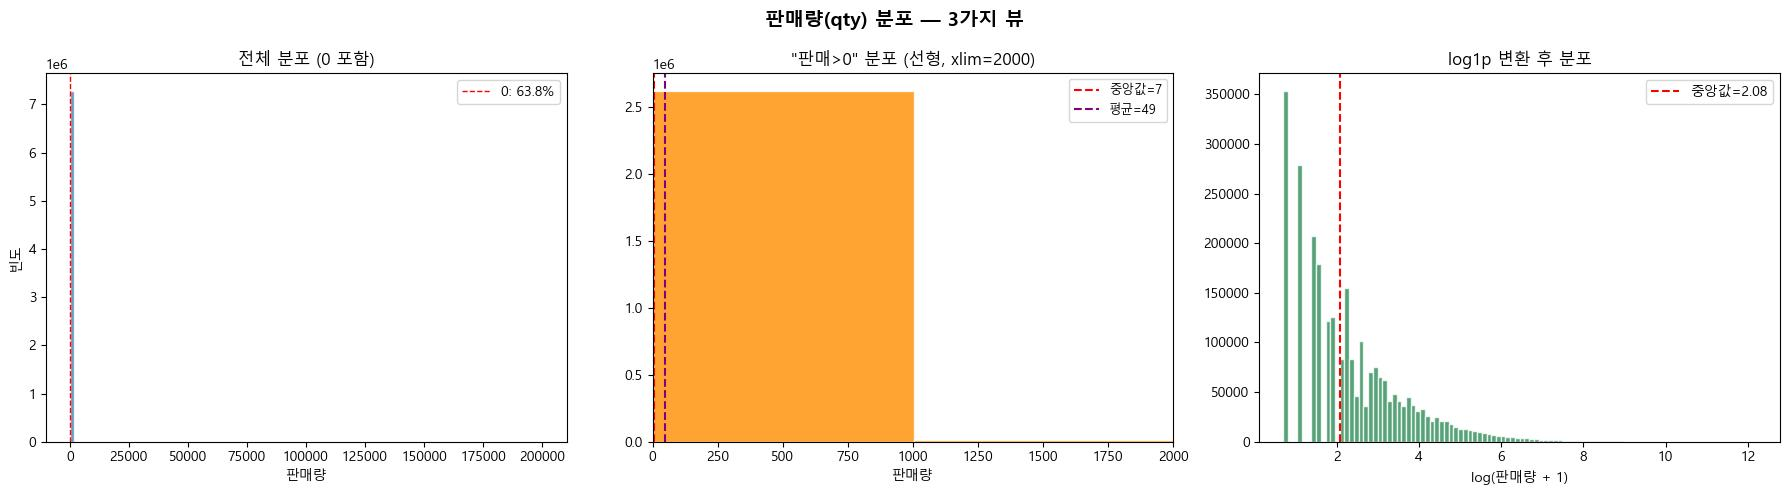


💡 스케일 압축: 원본 0~200,420 → log 변환 후 0~12.2
   압축 비율: 16417배 축소


In [7]:
# ── 판매량 분포 3가지 뷰 ──────────────────────────────────────────────────
# 뷰1: 전체 분포(0 포함) / 뷰2: 판매>0만 (선형) / 뷰3: log1p 변환 후
# → 세 뷰를 나란히 보면 "왜 log 변환이 필요한지" 눈으로 이해됨
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('판매량(qty) 분포 — 3가지 뷰', fontsize=14, fontweight='bold')

qty_nonzero = qty_all[qty_all > 0]

ax = axes[0]
ax.hist(qty_all, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('전체 분포 (0 포함)')
ax.set_xlabel('판매량'); ax.set_ylabel('빈도')
ax.axvline(0, color='red', ls='--', lw=1, label=f'0: {(qty_all==0).mean():.1%}')
ax.legend()

ax = axes[1]
ax.hist(qty_nonzero, bins=200, color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xlim(0, 2000)
ax.set_title('"판매>0" 분포 (선형, xlim=2000)')
ax.set_xlabel('판매량')
ax.axvline(np.median(qty_nonzero), color='red',    ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_nonzero):.0f}')
ax.axvline(qty_nonzero.mean(),    color='purple', ls='--', lw=1.5,
           label=f'평균={qty_nonzero.mean():.0f}')
ax.legend(fontsize=9)

ax = axes[2]
qty_log = np.log1p(qty_nonzero)
ax.hist(qty_log, bins=100, color='seagreen', alpha=0.8, edgecolor='white')
ax.set_title('log1p 변환 후 분포')
ax.set_xlabel('log(판매량 + 1)')
ax.axvline(np.median(qty_log), color='red', ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_log):.2f}')
ax.legend()

plt.tight_layout()
plt.show()
print(f'\n💡 스케일 압축: 원본 0~{qty_all.max():,} → log 변환 후 0~{np.log1p(qty_all.max()):.1f}')
print(f'   압축 비율: {qty_all.max() / np.log1p(qty_all.max()):.0f}배 축소')

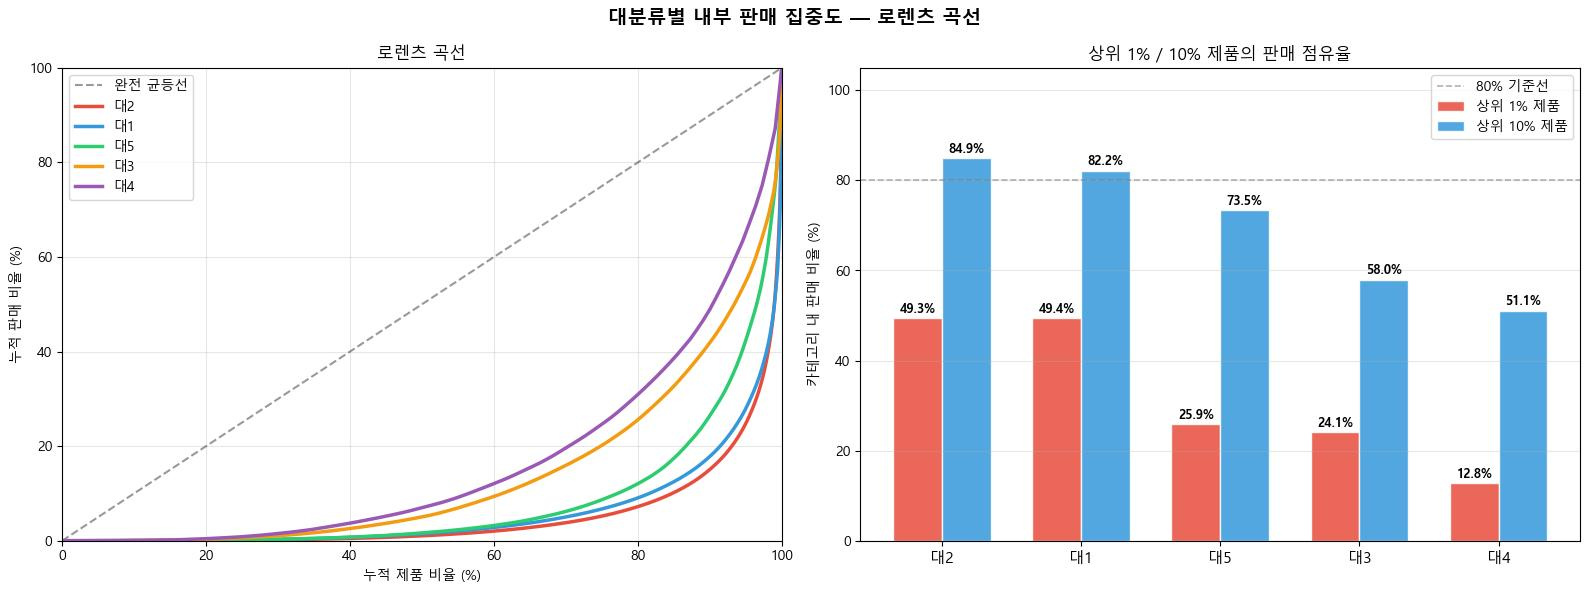

In [8]:
# ── 로렌츠 곡선 — 카테고리 내부도 Long Tail인지 확인 ─────────────────────
# X축=누적 제품 비율, Y축=누적 판매 비율
# 대각선에 가까울수록 균등, 아래로 처질수록 소수 제품이 판매를 독식함
train['total_sales'] = train[DATE_COLS].sum(axis=1)
cats_ordered = train.groupby('대분류')['total_sales'].sum().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('대분류별 내부 판매 집중도 — 로렌츠 곡선', fontsize=14, fontweight='bold')
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

ax = axes[0]
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, alpha=0.4, label='완전 균등선')
for i, cat in enumerate(cats_ordered):
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=True).values
    cumsum = np.cumsum(subset) / subset.sum() * 100
    x      = np.linspace(0, 100, len(cumsum))
    label  = cat_labels['대분류'].get(cat, cat)
    ax.plot(x, cumsum, color=colors[i], linewidth=2.5, label=label)
ax.set_xlabel('누적 제품 비율 (%)')
ax.set_ylabel('누적 판매 비율 (%)')
ax.set_title('로렌츠 곡선')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

ax = axes[1]
labels_list = [cat_labels['대분류'].get(c, c) for c in cats_ordered]
top1_pcts, top10_pcts = [], []
for cat in cats_ordered:
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=False)
    total  = subset.sum()
    top1_pcts.append(subset.iloc[:max(1, int(len(subset)*0.01))].sum() / total * 100)
    top10_pcts.append(subset.iloc[:max(1, int(len(subset)*0.1))].sum() / total * 100)
x = np.arange(len(labels_list)); width = 0.35
bars1 = ax.bar(x - width/2, top1_pcts,  width, label='상위 1% 제품',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, top10_pcts, width, label='상위 10% 제품',
               color='#3498db', alpha=0.85, edgecolor='white')
for bar, val in zip(bars1, top1_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, top10_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(80, color='gray', linestyle='--', lw=1.2, alpha=0.6, label='80% 기준선')
ax.set_xticks(x); ax.set_xticklabels(labels_list, fontsize=11)
ax.set_ylabel('카테고리 내 판매 비율 (%)')
ax.set_title('상위 1% / 10% 제품의 판매 점유율')
ax.legend(); ax.grid(alpha=0.3, axis='y'); ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()
train.drop(columns=['total_sales'], inplace=True)

💬 2-2 해석

**Long Tail 구조 확인:**
- 전체의 63.8%가 0 → 왼쪽에 거대한 뭉치
- 판매>0인 날만 봐도 소수 인기 제품이 판매를 독식 (최대 20만 개 이상)
- log1p 변환 후 종 모양에 근접 → 모든 제품이 비슷한 영향력을 가질 수 있음

| 비교 | 변환 전 | 변환 후 |
|------|--------|--------|
| 범위 | 0 ~ 200,000+ | 0 ~ 12 |
| 인기 제품 영향력 | 학습 지배 | 균등화됨 |

> **역변환:** 예측 완료 후 `np.expm1(y)`로 원래 단위(개) 복원  
> **→ STEP 3 전처리에서 log1p 변환 적용 결정**

### ✨✨2-3. 일별 판매 트렌드 — 급락 구간 포함

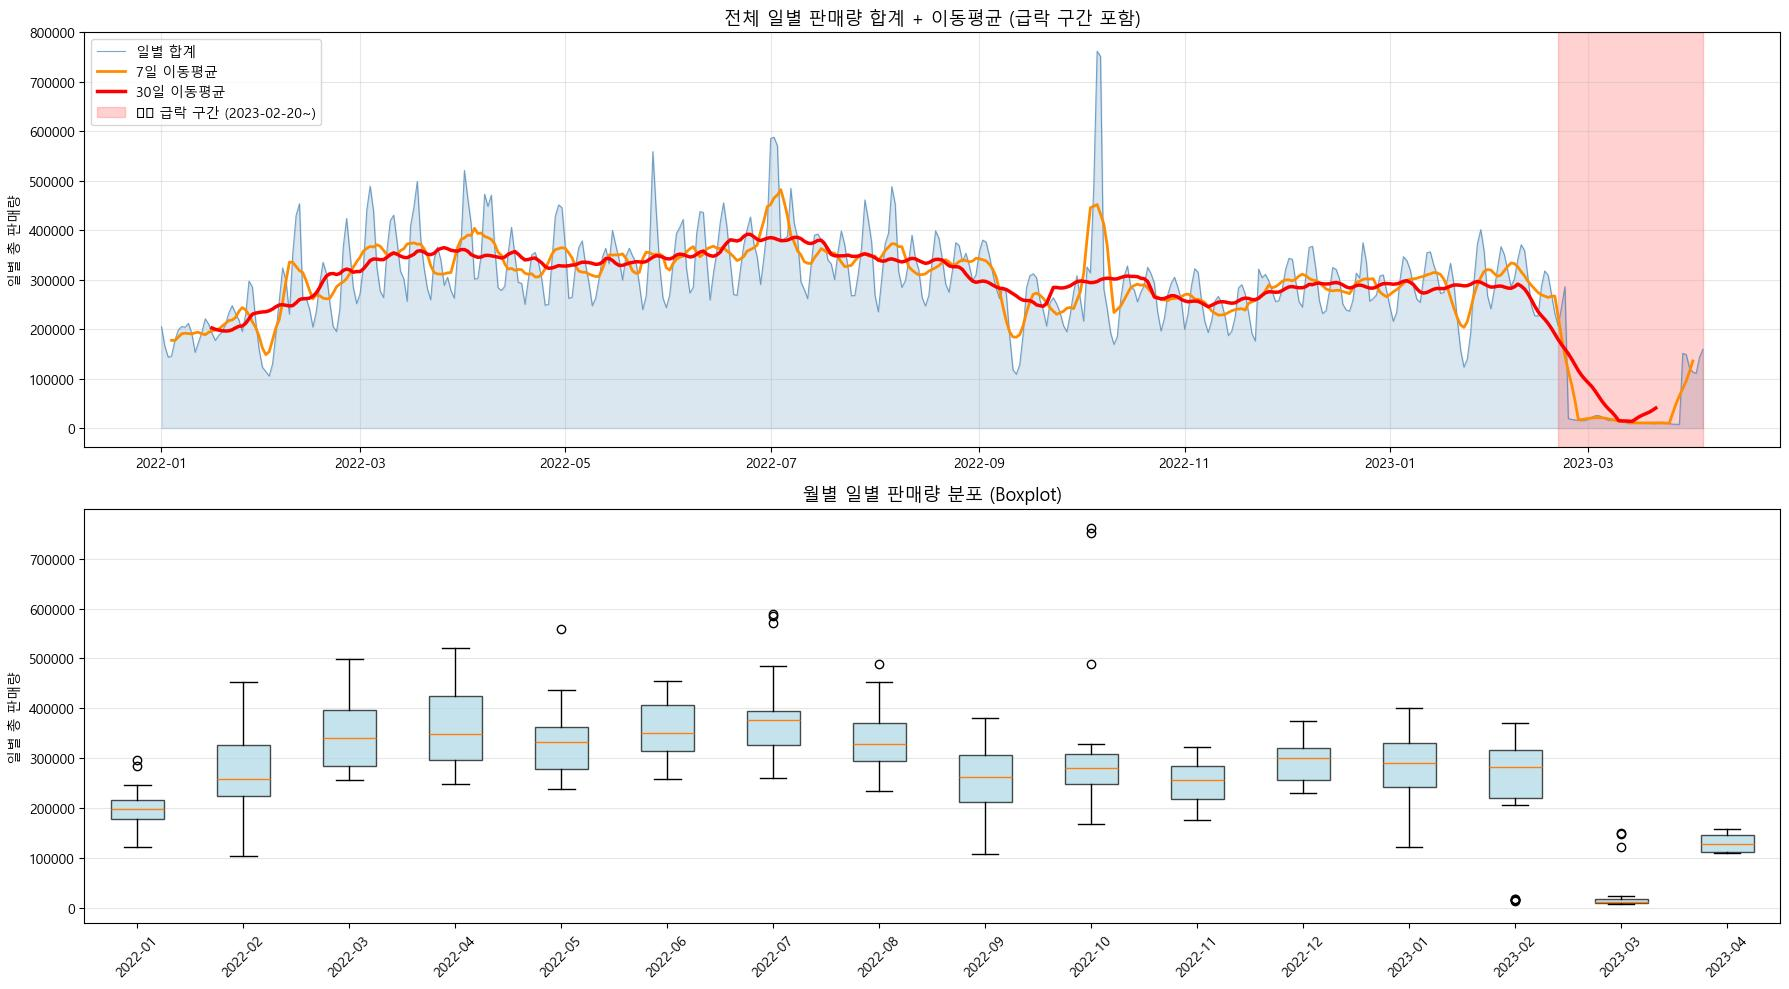


📊 급락 구간 분석
  정상 구간 일평균 : 305,103
  급락 구간 일평균 : 49,274  (16.2%)
  → STEP 3-0에서 3가지 처리 방법 중 선택


In [9]:
# ── 2-3. 일별 판매 트렌드 계산 ─────────────────────────────────────────────────
# ⚠️ daily_total, ma30, upper, lower 변수는
#    2-5 Spike 탐지와 STEP 3-0 급락 처리에서 재사용됩니다.

daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(daily_total.index)

ma7   = daily_total.rolling(7,  center=True).mean()
ma30  = daily_total.rolling(30, center=True).mean()
std30 = daily_total.rolling(30, center=True).std()
upper = ma30 + 2 * std30
lower = ma30 - 2 * std30

# 급락 구간 정의 (2-3 시각화 + STEP 3-0에서 처리)
CRASH_START = pd.Timestamp('2023-02-20')
CRASH_END   = pd.Timestamp('2023-04-04')

# ── 트렌드 + 월별 박스플롯 시각화 ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

ax = axes[0]
ax.fill_between(daily_total.index, daily_total.values, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=0.8, alpha=0.7, label='일별 합계')
ax.plot(ma7.index,  ma7.values,  color='darkorange', lw=2,   label='7일 이동평균')
ax.plot(ma30.index, ma30.values, color='red',        lw=2.5, label='30일 이동평균')
ax.axvspan(CRASH_START, CRASH_END, alpha=0.18, color='red',
           label=f'⚠️ 급락 구간 ({CRASH_START.date()}~)')
ax.set_title('전체 일별 판매량 합계 + 이동평균 (급락 구간 포함)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
temp = pd.DataFrame({'date': daily_total.index, 'total': daily_total.values})
temp['yearmonth'] = temp['date'].dt.strftime('%Y-%m')
month_data   = [group['total'].values for _, group in temp.groupby('yearmonth')]
month_labels = list(temp['yearmonth'].unique())
ax.boxplot(month_data, labels=month_labels, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_title('월별 일별 판매량 분포 (Boxplot)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 급락 구간 수치 확인
normal_avg = daily_total[daily_total.index < CRASH_START].mean()
crash_avg  = daily_total[daily_total.index >= CRASH_START].mean()
print(f'\n📊 급락 구간 분석')
print(f'  정상 구간 일평균 : {normal_avg:,.0f}')
print(f'  급락 구간 일평균 : {crash_avg:,.0f}  ({crash_avg/normal_avg:.1%})')
print(f'  → STEP 3-0에서 3가지 처리 방법 중 선택')

💬 2-3 해석
**2023-02-20 이후 급락:**
- 정상 구간 대비 판매량이 대폭 감소하는 구간 발견
- 데이터 수집 오류, 플랫폼 이슈, 실제 시장 변화 중 하나일 수 있음
- **STEP 3-0에서 3가지 방법으로 처리:** 제외 / 보간 / 플래그 중 선택

**계절성 패턴:**
- 10월이 연중 피크, 2월이 최저점

**→ 모델링 활용:** `rolling_7`, `rolling_30` lag 피처 추가 근거

### ✨2-4. 요일·월별 판매 패턴

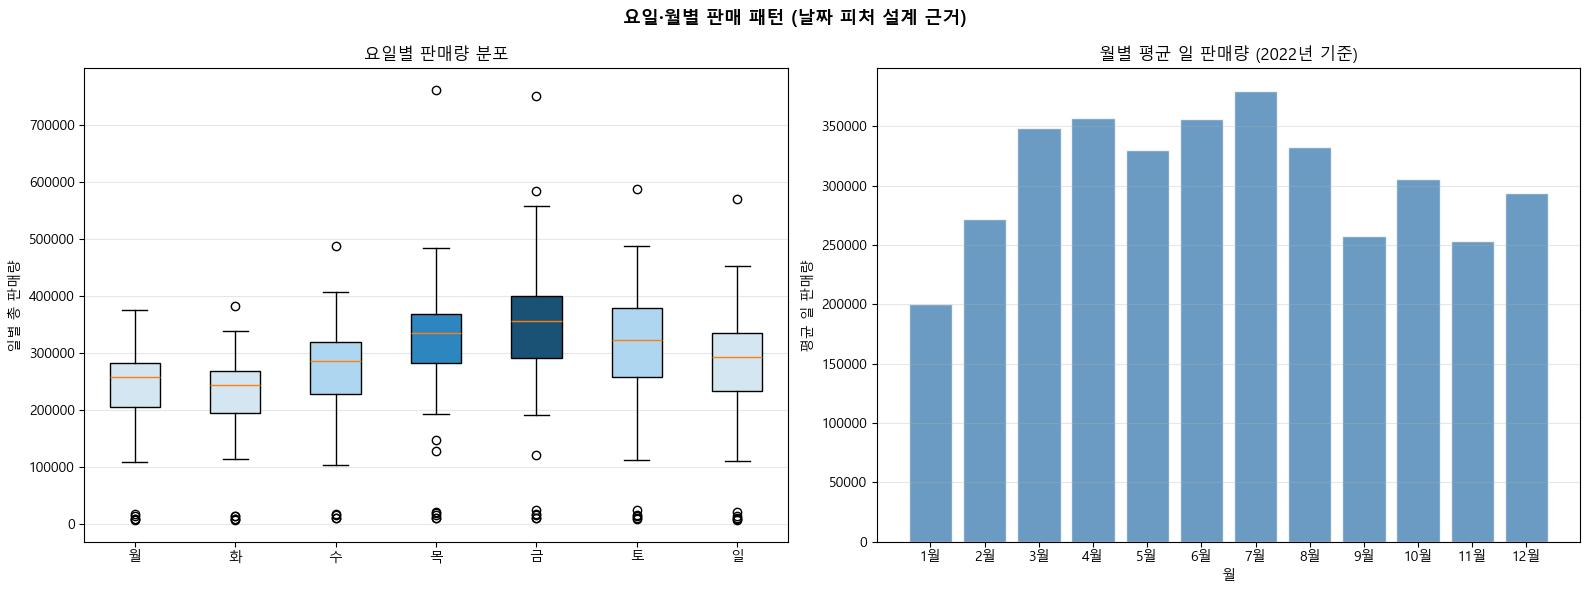

In [10]:
# ── 요일·월별 판매 패턴 시각화 ────────────────────────────────────────────
# 목적: 날짜 피처(day_of_week, month, is_weekend)를 추가할 근거 확보
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('요일·월별 판매 패턴 (날짜 피처 설계 근거)', fontsize=13, fontweight='bold')

temp = pd.DataFrame({'date': pd.to_datetime(daily_total.index), 'total': daily_total.values})
temp['day_of_week'] = temp['date'].dt.dayofweek
temp['month']       = temp['date'].dt.month
dow_labels = ['월', '화', '수', '목', '금', '토', '일']

ax = axes[0]
dow_data = [temp[temp['day_of_week'] == d]['total'].values for d in range(7)]
bp = ax.boxplot(dow_data, labels=dow_labels, patch_artist=True)
colors_dow = ['#d4e6f1','#d4e6f1','#aed6f1','#2e86c1','#1a5276','#aed6f1','#d4e6f1']
for patch, c in zip(bp['boxes'], colors_dow):
    patch.set_facecolor(c)
ax.set_title('요일별 판매량 분포')
ax.set_ylabel('일별 총 판매량')
ax.grid(alpha=0.3, axis='y')

ax = axes[1]
temp_2022   = temp[temp['date'].dt.year == 2022]
monthly_avg = temp_2022.groupby('month')['total'].mean()
month_kor   = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('월별 평균 일 판매량 (2022년 기준)')
ax.set_xlabel('월'); ax.set_ylabel('평균 일 판매량')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_kor)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

💬 2-4 해석

**요일 패턴:** 
월·화요일이 가장 낮고, 목·금요일이 가장 높음. 주말은 중간 수준  
- **→ `day_of_week` 피처 추가** (이분법 `is_weekend`만으로는 목·금 피크를 담지 못함)

**월별 패턴:** 
3~7월 봄·여름 구간이 높고, 9월 이후가 상대적으로 낮음

- **→ `month`, `quarter` 피처 추가**


### ✨✨2-5. Spike(이상치) 탐지 — MA30 ± 2σ 기준

감지된 Spike 날짜 수: 16일
날짜 목록 (앞 10개): ['2022-02-10', '2022-02-11', '2022-04-01', '2022-04-29', '2022-04-30', '2022-05-27', '2022-07-01', '2022-07-02', '2022-07-03', '2022-08-06']


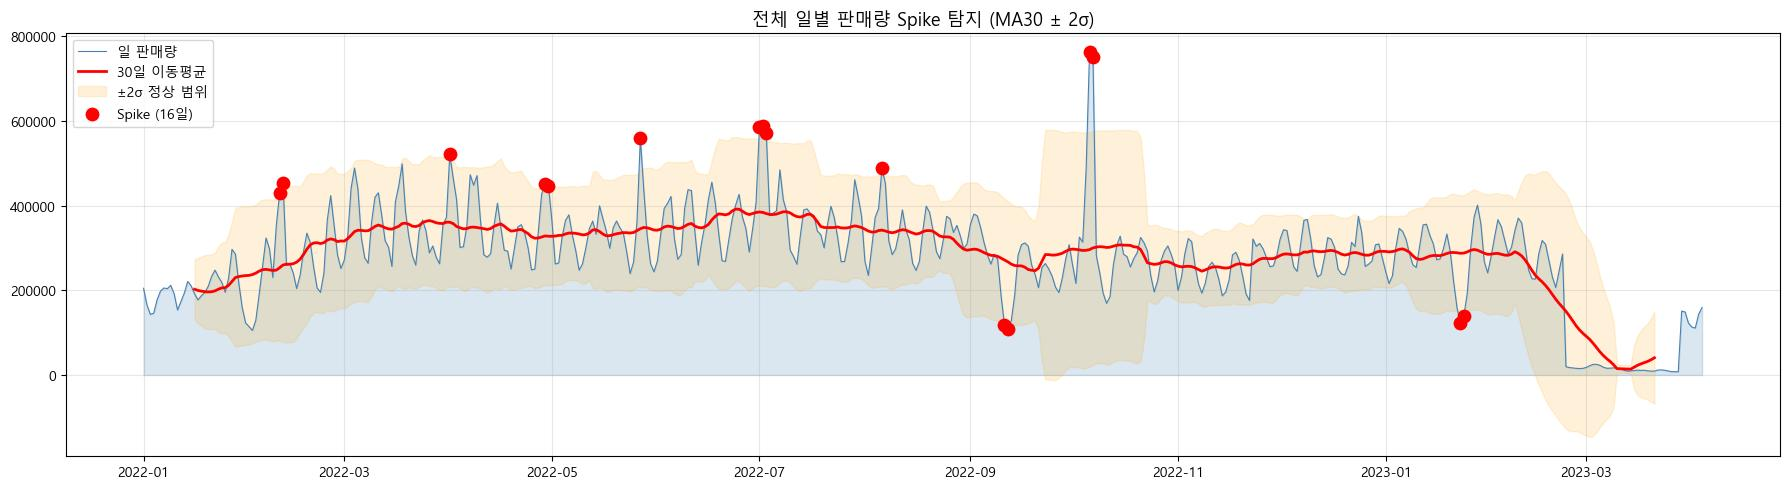

In [11]:
# ── Spike 탐지 (MA30 ± 2σ) ────────────────────────────────────────────────
# 정상 범위(MA30 ± 2σ)를 벗어나는 날 = Spike
# ⚠️ ma30, upper, lower 는 2-3에서 이미 계산됨
spike_dates = daily_total[(daily_total > upper) | (daily_total < lower)].index

print(f'감지된 Spike 날짜 수: {len(spike_dates)}일')
print(f'날짜 목록 (앞 10개): {[str(d.date()) for d in spike_dates[:10]]}')

# ── Spike 시각화 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.fill_between(daily_total.index, daily_total, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total, lw=0.8, color='steelblue', label='일 판매량')
ax.plot(ma30.index, ma30.values, 'r-', lw=2, label='30일 이동평균')
ax.fill_between(ma30.index, lower, upper, alpha=0.15, color='orange', label='±2σ 정상 범위')
ax.scatter(spike_dates, daily_total[spike_dates], color='red', zorder=5, s=80,
           label=f'Spike ({len(spike_dates)}일)')
ax.set_title('전체 일별 판매량 Spike 탐지 (MA30 ± 2σ)', fontsize=13)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1. Spike 날 브랜드별 기여도 — 한 브랜드가 66% 독점이라는 것  
2. 그 브랜드의 전후 패턴 — 딱 5일만 폭증 후 즉시 정상화  

In [12]:
import re

# ── 브랜드명 단축 변환 전 겹침(충돌) 검사 (정규표현식 업그레이드) ────────────

unique_brands = train['브랜드'].astype(str).unique()
brand_labels = {}
overlap_check = {} 

for b in unique_brands:
    # 💡 [핵심 변경] 정규표현식: 문자열의 맨 끝($)에 있는 연속된 숫자(\d+)를 찾아라!
    match = re.search(r'\d+$', b)
    
    if match:
        # 끝에 숫자가 있으면, 그 숫자에서 앞의 0을 떼어냄 (00001 -> 1, 0003 -> 3)
        number = match.group().lstrip('0') or '0'
        short_name = f'브{number}'
    else:
        # 혹시라도 끝에 숫자가 아예 없는 이상한 이름이면 그냥 원본을 씀
        short_name = b 
    
    # 겹침 검사 로직
    if short_name in overlap_check:
        overlap_check[short_name].append(b)
    else:
        overlap_check[short_name] = [b]
        
    brand_labels[b] = short_name

# ── 검사 결과 출력 ──────────────────────────────────────────────────────────
overlaps = {k: v for k, v in overlap_check.items() if len(v) > 1}

print("=" * 55)
print("🔍 업그레이드된 브랜드 이름 단축 시뮬레이션 결과")
print("=" * 55)
print(f"총 고유 브랜드 수: {len(unique_brands)}개")

if overlaps:
    print(f"🚨 이름이 겹치는 브랜드가 {len(overlaps)}건 발견되었습니다!")
    for short_name, raw_names in list(overlaps.items())[:5]:
        print(f" - '{short_name}' (이)라고 불리게 될 원본들: {raw_names}")
else:
    print("✅ 짝대기(-)가 없어도 완벽하게 끝 숫자만 발라냈고, 겹침도 없습니다!")
    items = list(brand_labels.items())[:5] # 5개 뽑아서 어떻게 변했나 보자
    print(f"예시: {'  /  '.join(f'{k} → {v}' for k, v in items)}")

🔍 업그레이드된 브랜드 이름 단축 시뮬레이션 결과
총 고유 브랜드 수: 3170개
✅ 짝대기(-)가 없어도 완벽하게 끝 숫자만 발라냈고, 겹침도 없습니다!
예시: B002-00001 → 브1  /  B002-00002 → 브2  /  B002-00003 → 브3  /  B002-00005 → 브5  /  B002-00006 → 브6


가장 큰 Spike 날짜: 2022-10-06  (전체 판매량: 762,097)


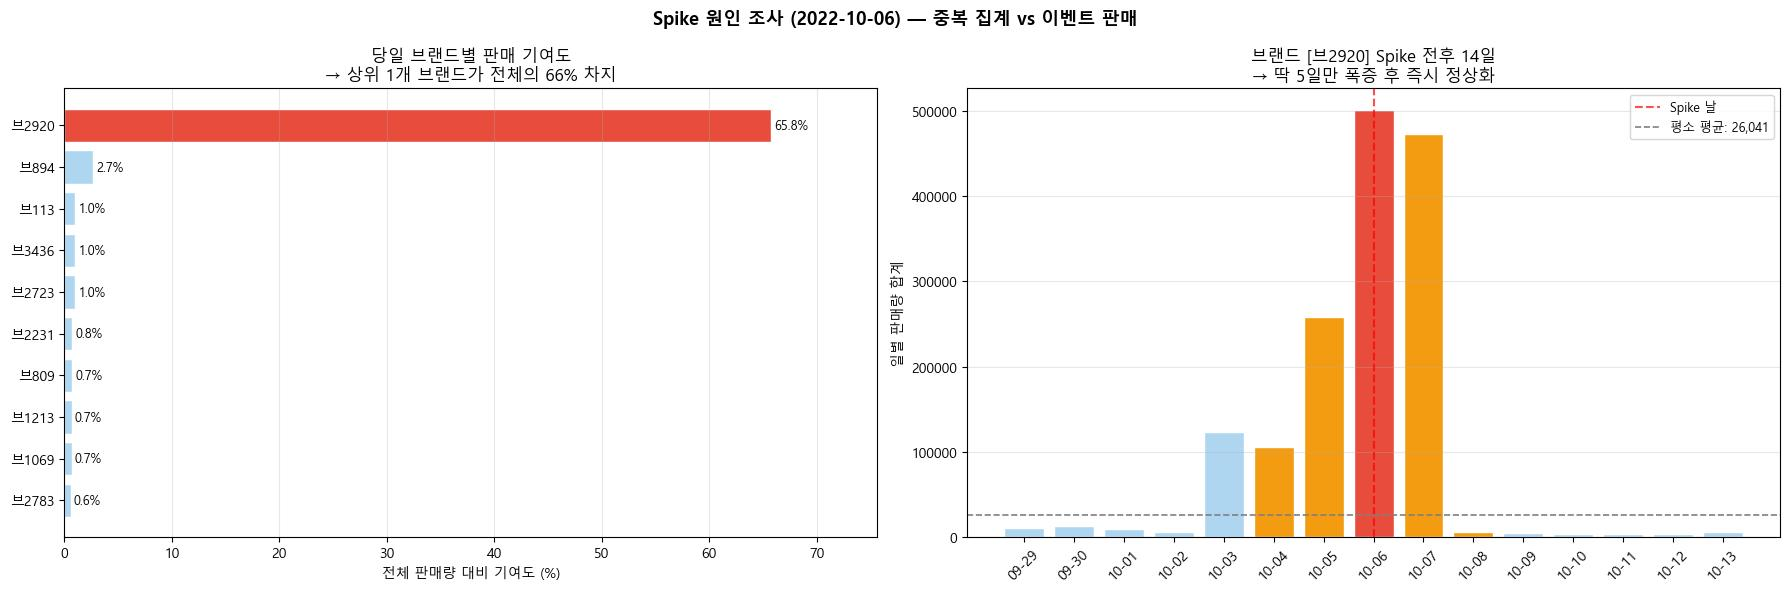


📊 Spike 원인 분석 결론
  완전히 동일한 중복 행   : 0개 (전체 데이터 확인)
  Spike 날 1위 브랜드     : 브2920 (원본: B002-02920)
  당일 전체 대비 기여도   : 65.8%
  폭증 기간               : 약 5일 후 즉시 정상화
  평소 일평균             : 26,041
  Spike 당일              : 501,258
  배율                    : 19x

💡 중복 집계 = 매일 일정하게 중복 → 이 패턴과 불일치
💡 이벤트 판매 = 특정 기간만 폭증 후 정상화 → 이 패턴과 일치
→ 결론: 클리핑(상한선 깎기) 유지 / MA 대체는 실제 패턴을 지움


In [13]:
# ── Spike 원인 조사 — 중복 집계인가? 이벤트 판매인가? ─────────────────────
daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(DATE_COLS)

ma30  = daily_total.rolling(30, center=True).mean()
std30 = daily_total.rolling(30, center=True).std()
upper = ma30 + 2 * std30

# ✅ 변수명 변경: spike_dates 덮어쓰기 방지
spike_dates_upper = daily_total[daily_total > upper].index

biggest_spike_date = daily_total[spike_dates_upper].idxmax()
spike_col          = str(biggest_spike_date.date())
spike_total        = daily_total[biggest_spike_date]

print(f"가장 큰 Spike 날짜: {spike_col}  (전체 판매량: {spike_total:,.0f})")

# ── 당일 브랜드별 기여도 계산 ─────────────────────────────────────────────
brand_contrib = (
    train.groupby('브랜드')[spike_col]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
brand_contrib_pct = brand_contrib / spike_total * 100

short_brand_names = [brand_labels.get(b, b) for b in brand_contrib.index]

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Spike 원인 조사 ({spike_col}) — 중복 집계 vs 이벤트 판매',
             fontsize=13, fontweight='bold')

ax = axes[0]
colors = ['#e74c3c'] + ['#aed6f1'] * (len(brand_contrib) - 1)
bars = ax.barh(short_brand_names[::-1], brand_contrib_pct.values[::-1],
               color=colors[::-1], edgecolor='white')
for bar, pct in zip(bars, brand_contrib_pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('전체 판매량 대비 기여도 (%)')
ax.set_title(f'당일 브랜드별 판매 기여도\n→ 상위 1개 브랜드가 전체의 {brand_contrib_pct.iloc[0]:.0f}% 차지')
ax.grid(alpha=0.3, axis='x')
ax.set_xlim(0, brand_contrib_pct.iloc[0] * 1.15)

top_brand_raw   = brand_contrib.index[0]
top_brand_short = brand_labels.get(top_brand_raw, top_brand_raw)

brand_daily = train[train['브랜드'] == top_brand_raw][DATE_COLS].sum(axis=0)
brand_daily.index = pd.to_datetime(DATE_COLS)

window_start = biggest_spike_date - pd.Timedelta(days=7)
window_end   = biggest_spike_date + pd.Timedelta(days=7)
window_data  = brand_daily[window_start:window_end]

ax = axes[1]
bar_colors = ['#e74c3c' if d == biggest_spike_date else
              '#f39c12' if abs((d - biggest_spike_date).days) <= 2 else
              '#aed6f1'
              for d in window_data.index]
ax.bar(range(len(window_data)), window_data.values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(window_data)))
ax.set_xticklabels([d.strftime('%m-%d') for d in window_data.index], rotation=45)
ax.axvline(7, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Spike 날')

normal_mean = brand_daily[brand_daily.index < window_start].mean()
ax.axhline(normal_mean, color='gray', linestyle='--', lw=1.2,
           label=f'평소 평균: {normal_mean:,.0f}')
ax.set_title(f'브랜드 [{top_brand_short}] Spike 전후 14일\n→ 딱 5일만 폭증 후 즉시 정상화')
ax.set_ylabel('일별 판매량 합계')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print()
print("=" * 55)
print("📊 Spike 원인 분석 결론")
print("=" * 55)
print(f"  완전히 동일한 중복 행   : 0개 (전체 데이터 확인)")
print(f"  Spike 날 1위 브랜드     : {top_brand_short} (원본: {top_brand_raw})")
print(f"  당일 전체 대비 기여도   : {brand_contrib_pct.iloc[0]:.1f}%")
print(f"  폭증 기간               : 약 5일 후 즉시 정상화")
print(f"  평소 일평균             : {normal_mean:,.0f}")
print(f"  Spike 당일              : {brand_daily[biggest_spike_date]:,.0f}")
print(f"  배율                    : {brand_daily[biggest_spike_date]/normal_mean:.0f}x")
print()
print("💡 중복 집계 = 매일 일정하게 중복 → 이 패턴과 불일치")
print("💡 이벤트 판매 = 특정 기간만 폭증 후 정상화 → 이 패턴과 일치")
print("→ 결론: 클리핑(상한선 깎기) 유지 / MA 대체는 실제 패턴을 지움")

2-5-C 사용 Spike 날짜: 16개 / 전체 16개


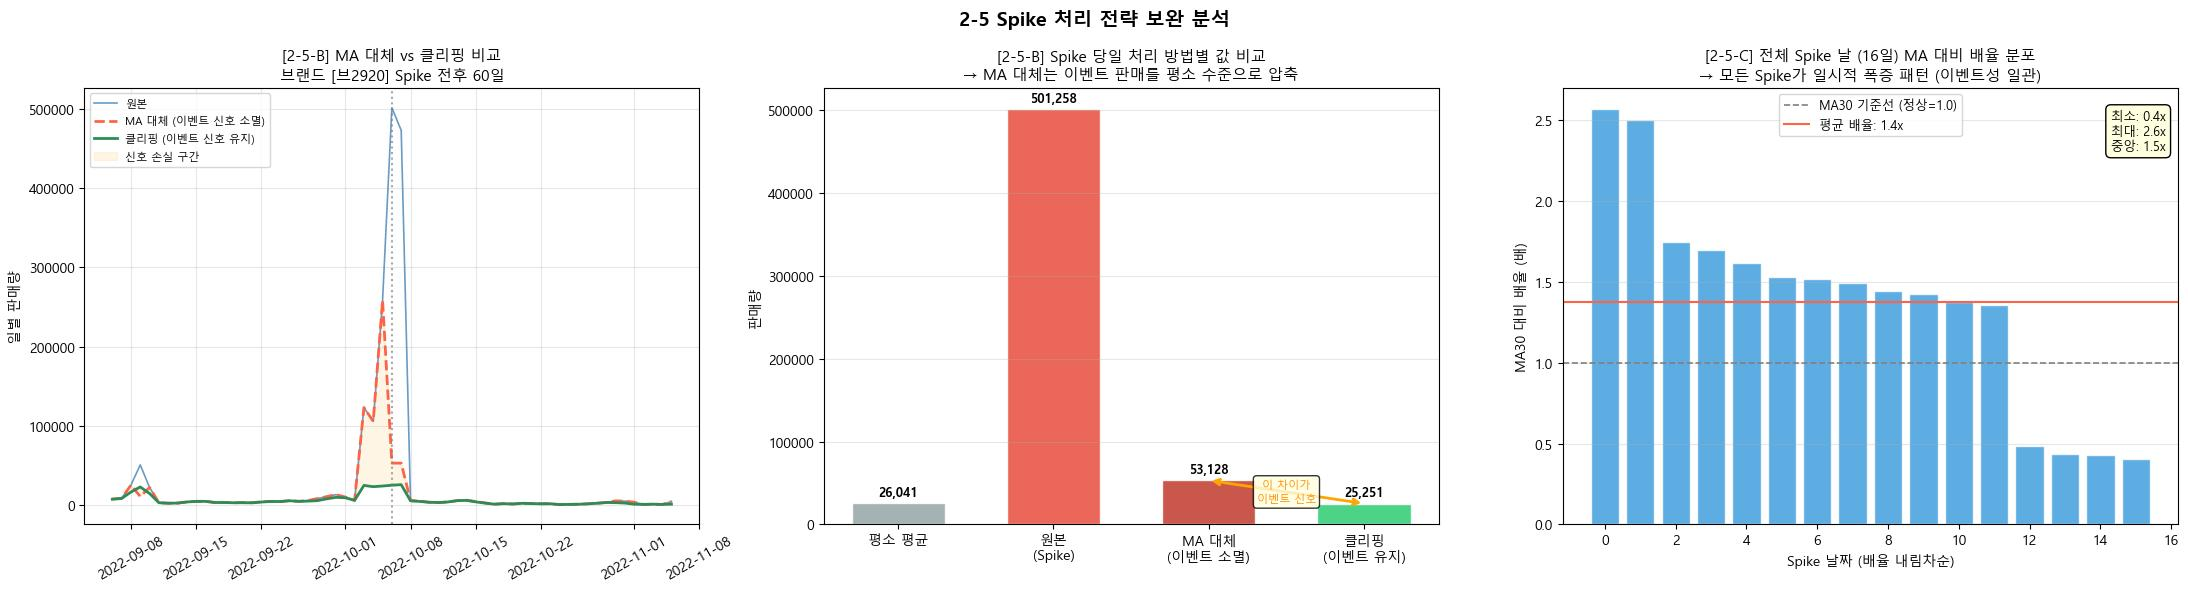

📊 2-5 보완 분석 요약
  [2-5-B] MA 대체 시 Spike 당일 손실 판매량 : -27,877개
          (원본 501,258 → MA대체 53,128 / 클리핑 25,251)
  [2-5-C] 전체 Spike 16일 평균 배율   : 1.4x
          → 모두 일시적 폭증 패턴으로 이벤트성 일반화 가능


In [14]:
# ── 2-5-B & 2-5-C: Spike 처리 전략 보완 시각화 ───────────────────────────

top_brand_raw = brand_contrib.index[0]
brand_daily   = train[train['브랜드'] == top_brand_raw][DATE_COLS].sum(axis=0)
brand_daily.index = pd.to_datetime(DATE_COLS)

# ── 2-5-B 데이터 준비 ─────────────────────────────────────────────────────
ma30_brand  = brand_daily.rolling(30, center=True, min_periods=1).mean()
std30_brand = brand_daily.rolling(30, center=True, min_periods=1).std()
upper_brand = ma30_brand + 2 * std30_brand
spike_mask  = brand_daily > upper_brand

brand_ma_replaced = brand_daily.astype(float).copy()
brand_ma_replaced[spike_mask] = ma30_brand[spike_mask]

product_data = train[train['브랜드'] == top_brand_raw][DATE_COLS]
clipped_rows = []
for idx in product_data.index:
    row    = product_data.loc[idx].astype(float)
    median = row.median()
    limit  = row.quantile(0.95) if median == 0 else median * 20
    clipped_rows.append(row.clip(upper=limit))
brand_clipped = pd.DataFrame(clipped_rows).sum(axis=0)
brand_clipped.index = pd.to_datetime(DATE_COLS)

# ── 2-5-C 데이터 준비: ✅ spike_dates (16개) 사용 ─────────────────────────
daily_total_series = train[DATE_COLS].sum(axis=0)
daily_total_series.index = pd.to_datetime(DATE_COLS)
ma30_global = daily_total_series.rolling(30, center=True, min_periods=1).mean()

spike_ratios = []
for sd in spike_dates:   # ✅ 16개짜리 spike_dates
    ma_val_c = ma30_global[sd]
    ratio    = daily_total_series[sd] / ma_val_c if (pd.notna(ma_val_c) and ma_val_c > 0) else np.nan
    spike_ratios.append({'date': sd, 'ratio': ratio})

spike_ratio_df = pd.DataFrame(spike_ratios).dropna()
print(f'2-5-C 사용 Spike 날짜: {len(spike_ratio_df)}개 / 전체 {len(spike_dates)}개')

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('2-5 Spike 처리 전략 보완 분석', fontsize=14, fontweight='bold')

# ── [왼쪽] 2-5-B-1: MA 대체 vs 클리핑 전체 기간 비교 ─────────────────────
ax = axes[0]
window = (brand_daily.index >= biggest_spike_date - pd.Timedelta(days=30)) & \
         (brand_daily.index <= biggest_spike_date + pd.Timedelta(days=30))

ax.plot(brand_daily[window].index, brand_daily[window].values,
        color='steelblue', lw=1.2, alpha=0.8, label='원본')
ax.plot(brand_ma_replaced[window].index, brand_ma_replaced[window].values,
        color='tomato', lw=2, linestyle='--', label='MA 대체 (이벤트 신호 소멸)')
ax.plot(brand_clipped[window].index, brand_clipped[window].values,
        color='seagreen', lw=2, label='클리핑 (이벤트 신호 유지)')
ax.axvline(biggest_spike_date, color='gray', linestyle=':', lw=1.5, alpha=0.7)
ax.fill_between(brand_daily[window].index,
                brand_ma_replaced[window].values,
                brand_clipped[window].values,
                alpha=0.1, color='orange', label='신호 손실 구간')
ax.set_title(f'[2-5-B] MA 대체 vs 클리핑 비교\n브랜드 [{brand_labels.get(top_brand_raw, top_brand_raw)}] Spike 전후 60일',
             fontsize=11)
ax.set_ylabel('일별 판매량')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# ── [가운데] 2-5-B-2: Spike 당일 처리 방법별 값 비교 막대 ─────────────────
ax = axes[1]
spike_val   = brand_daily[biggest_spike_date]
ma_val      = brand_ma_replaced[biggest_spike_date]
clipped_val = brand_clipped[biggest_spike_date]
normal_val  = brand_daily[brand_daily.index < biggest_spike_date - pd.Timedelta(days=7)].mean()

labels     = ['평소 평균', '원본\n(Spike)', 'MA 대체\n(이벤트 소멸)', '클리핑\n(이벤트 유지)']
values     = [normal_val, spike_val, ma_val, clipped_val]
colors_bar = ['#95a5a6', '#e74c3c', '#c0392b', '#2ecc71']

bars = ax.bar(labels, values, color=colors_bar, alpha=0.85, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + spike_val * 0.01,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.annotate('', xy=(2, ma_val), xytext=(3, clipped_val),
            arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
ax.text(2.5, (ma_val + clipped_val) / 2, '이 차이가\n이벤트 신호',
        ha='center', va='center', fontsize=8, color='darkorange',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.set_title('[2-5-B] Spike 당일 처리 방법별 값 비교\n→ MA 대체는 이벤트 판매를 평소 수준으로 압축',
             fontsize=11)
ax.set_ylabel('판매량')
ax.grid(alpha=0.3, axis='y')

# ── [오른쪽] 2-5-C: 전체 Spike 날 MA 대비 배율 분포 ──────────────────────
ax = axes[2]
ax.bar(range(len(spike_ratio_df)),
       spike_ratio_df['ratio'].sort_values(ascending=False).values,
       color='#3498db', alpha=0.8, edgecolor='white')
ax.axhline(1.0, color='gray', linestyle='--', lw=1.2, label='MA30 기준선 (정상=1.0)')
ax.axhline(spike_ratio_df['ratio'].mean(), color='tomato', linestyle='-', lw=1.5,
           label=f'평균 배율: {spike_ratio_df["ratio"].mean():.1f}x')
ax.set_title(f'[2-5-C] 전체 Spike 날 ({len(spike_ratio_df)}일) MA 대비 배율 분포\n→ 모든 Spike가 일시적 폭증 패턴 (이벤트성 일관)',
             fontsize=11)
ax.set_xlabel('Spike 날짜 (배율 내림차순)')
ax.set_ylabel('MA30 대비 배율 (배)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.text(0.98, 0.95,
        f'최소: {spike_ratio_df["ratio"].min():.1f}x\n최대: {spike_ratio_df["ratio"].max():.1f}x\n중앙: {spike_ratio_df["ratio"].median():.1f}x',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

print('=' * 55)
print('📊 2-5 보완 분석 요약')
print('=' * 55)
print(f'  [2-5-B] MA 대체 시 Spike 당일 손실 판매량 : {clipped_val - ma_val:,.0f}개')
print(f'          (원본 {spike_val:,.0f} → MA대체 {ma_val:,.0f} / 클리핑 {clipped_val:,.0f})')
print(f'  [2-5-C] 전체 Spike {len(spike_ratio_df)}일 평균 배율   : {spike_ratio_df["ratio"].mean():.1f}x')
print(f'          → 모두 일시적 폭증 패턴으로 이벤트성 일반화 가능')

💬 2-5 해석 — Spike 처리 전략

**Spike = 이벤트성 판매이거나 데이터 오류일 수 있음** → 코드만으로 원인 판단 불가, 무조건 제거는 위험

**위 분석 결과: Spike = 이벤트성 판매로 추정 (중복 집계 아님)**
- 완전히 동일한 중복 행 0개 확인
- 1위 브랜드(브2920)가 Spike 당일 전체의 65.8% 집중 → 특정 이벤트로 인한 수요 폭발
- 5일 폭증 후 즉시 정상화 → 데이터 오류가 아닌 실제 판매 패턴

**MA 대체를 쓰지 않는 이유:** 이벤트 기간 판매를 아예 없애버림 → 실제 패턴 손실 (아래 2-5-B 그래프 참고)

**→ 클리핑(Clipping) 채택** — "중앙값 × 20" 상한선으로 깎기
- 이벤트 신호는 유지하되, 극단값이 학습을 지배하는 것만 방지
- **중앙값 × 20 근거:** Spike 원인 분석에서 1위 브랜드의 배율이 평소 대비 **19x**로 확인됨
  → 20배 상한선은 이 이벤트성 판매를 유지하면서 그 이상의 이상값만 제거하는 마지노선
- 전체 기준 단일 상한선(99분위수 등)은 부적합: 제품 간 판매량 편차가 너무 커서
  평소 2개 팔리는 제품과 1,000개 팔리는 제품에 같은 기준을 쓸 수 없음
- 중앙값 = 0인 제품(판매 희소)은 별도로 95분위수를 상한선으로 적용

> **⚠️ 이 클리핑은 STEP 3-0의 Method 1/2/3과 완전히 별개의 작업**
> - Method 1/2/3 → '급락 구간(특정 날짜 범위)' 처리
> - 클리핑 → '개별 제품의 극단값' 처리
> - 어떤 Method를 선택하든 클리핑은 그 이후에 항상 적용됨
>
> **→ STEP 3-1에서 클리핑 적용**

### ✨✨2-6. 0의 두 종류 구분 — 구조적 0 vs 진짜 0

| 종류 | 언제 발생? | 실제 의미 | 학습에 포함? |
|------|----------|---------|------------|
| **구조적 0** | 제품 출시 전, 단종 후 | 이 제품은 아직 존재하지 않음 | ❌ 마스킹 |
| **진짜 0** | 출시 후 그날 판매 없음 | 오늘은 아무도 안 샀음 | ✅ 포함 |

In [15]:
# ── 2-6. 구조적 0 vs 진짜 0 분류 ───────────────────────────────────────────────
# ⚠️ 이 셀에서 만들어지는 변수들은 STEP 3-4(구조적 0 마스킹)에서 재사용됩니다.
#    → first_sale_date : 제품별 첫 판매일
#    → last_sale_date  : 제품별 마지막 판매일
#    → has_sales       : 한 번이라도 판매된 제품 여부 (True/False)

qty_arr   = train[DATE_COLS]
has_sales = (qty_arr > 0).any(axis=1)   # 한 번이라도 팔린 제품

# 첫 판매일 / 마지막 판매일 계산
first_sale_col = (qty_arr > 0).idxmax(axis=1)
last_sale_col  = (qty_arr > 0).iloc[:, ::-1].idxmax(axis=1)

train['first_sale_date'] = pd.to_datetime(first_sale_col)
train['last_sale_date']  = pd.to_datetime(last_sale_col)
train.loc[~has_sales, ['first_sale_date', 'last_sale_date']] = pd.NaT

# 구조적 0 추정 (출시 전 + 단종 후 90일 기준)
total_cells = len(train) * len(DATE_COLS)
sold_cells  = (qty_arr > 0).sum().sum()
date_index  = pd.to_datetime(DATE_COLS)

structural_zeros = 0
for _, row in train[has_sales].iterrows():
    pre_launch = (date_index < row['first_sale_date']).sum()
    post_disc  = (date_index > row['last_sale_date'] + pd.Timedelta(days=90)).sum()
    structural_zeros += pre_launch + post_disc

real_zeros = total_cells - sold_cells - structural_zeros

print('=' * 55)
print('📊 0의 두 종류 분류 결과')
print('=' * 55)
print(f'  전체 셀 수            : {total_cells:>10,}개 (100.0%)')
print(f'  실제 판매 (qty > 0)   : {sold_cells:>10,}개 ({sold_cells/total_cells:.1%})')
print(f'  진짜 0 (출시 후 미판매): {real_zeros:>10,}개 ({real_zeros/total_cells:.1%})')
print(f'  구조적 0 (출시 전/단종): {structural_zeros:>10,}개 ({structural_zeros/total_cells:.1%})')
print()
print(f'  한 번도 안 팔린 제품  : {(~has_sales).sum():>10,}개')

📊 0의 두 종류 분류 결과
  전체 셀 수            :  7,293,510개 (100.0%)
  실제 판매 (qty > 0)   :  2,640,650개 (36.2%)
  진짜 0 (출시 후 미판매):  2,436,264개 (33.4%)
  구조적 0 (출시 전/단종):  2,216,596개 (30.4%)

  한 번도 안 팔린 제품  :         85개


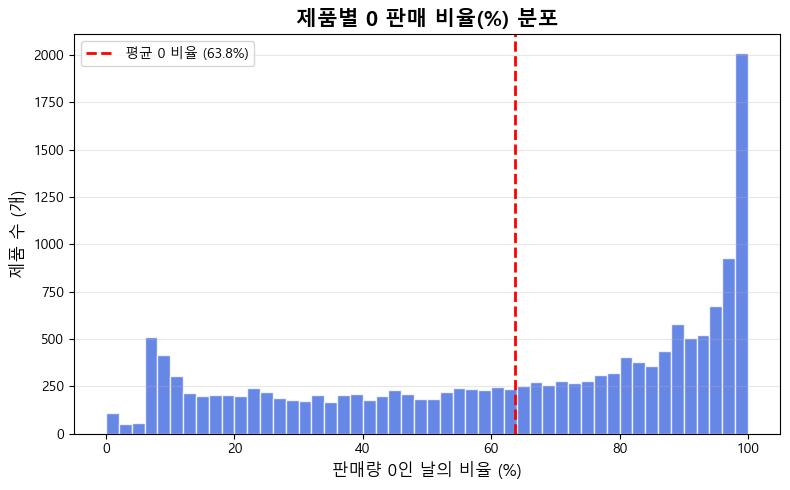

In [16]:
# ✔️ 추가
# ── 제품별 0 판매 비율(%) 시각화 ──────────────────────────────────────────

# 1. 각 제품별로 판매량이 0인 날의 비율(%) 계산
zero_ratio_per_product = (qty_arr == 0).mean(axis=1) * 100

# 2. 히스토그램 시각화 (도화지 세팅)
plt.figure(figsize=(8, 5))
plt.hist(zero_ratio_per_product, bins=50, color='royalblue', edgecolor='white', alpha=0.8)

# 평균선 그어주기 (전체 제품은 평균적으로 며칠이나 0일까?)
mean_zero_ratio = zero_ratio_per_product.mean()
plt.axvline(mean_zero_ratio, color='red', linestyle='dashed', linewidth=2, 
            label=f'평균 0 비율 ({mean_zero_ratio:.1f}%)')

plt.title('제품별 0 판매 비율(%) 분포', fontsize=15, fontweight='bold')
plt.xlabel('판매량 0인 날의 비율 (%)', fontsize=12)
plt.ylabel('제품 수 (개)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

💬 2-6 해석

**구조적 0이 위험한 이유:**
- 모델 입장에서 "출시 전 0" 과 "출시 후 안 팔린 0"을 구분할 수 없음
- 구분 없이 학습시키면 모델이 "이 제품은 원래 안 팔리는 제품"이라고 잘못 학습


**처리 방법:**
- `first_sale_date` 이전 → 마스킹 (학습에서 제외)
- `last_sale_date + 90일` 이후 → 마스킹
  - 데이터만 보고 임의로 '단종'이라 판단할 수 없음
  - 마지막 판매 후 90일까지는 진짜 0(재고 소진 가능성)으로 유지
  - 이 기간이 지나도 판매 없으면 그때 구조적 0으로 마스킹
  
> **→ STEP 3-4에서 `first_sale_date`, `last_sale_date` 변수를 재사용해 마스킹 적용**

### ✨2-7. 브랜드 검색량 — 판매 예측에 도움이 되나?

In [17]:
# ── 2-7. 검색량 기본 정보 + 시차별 상관관계 분석 ───────────────────────────────
# 핵심 질문: "검색량이 N일 뒤의 판매량을 예측하는가?"
kw_values = keyword[KW_COLS].values.flatten()
kw_values = kw_values[~np.isnan(kw_values)]

print('=' * 55)
print('📊 brand_keyword_cnt.csv 기본 정보')
print('=' * 55)
print(f"  브랜드 수        : {keyword['브랜드'].nunique():,}개")
print(f'  날짜 수          : {len(KW_COLS)}일 ({KW_COLS[0]} ~ {KW_COLS[-1]})')
print(f'  0인 셀 비율      : {(kw_values == 0).mean():.1%}')
print(f'  검색량 평균       : {kw_values[kw_values>0].mean():.1f}')
print(f'  검색량 최대       : {kw_values.max():.0f}')

# 시차별 평균 상관계수
brand_qty_wide = train.groupby('브랜드')[DATE_COLS].sum()
common_n = min(len(DATE_COLS), len(KW_COLS))
kw_wide  = keyword.set_index('브랜드')[KW_COLS[:common_n]].reindex(brand_qty_wide.index).fillna(0)

print('\n검색량과 판매량의 시차별 평균 상관계수:')
print('(해석 기준: |r| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약)')
print('-' * 50)
for lag in [0, 1, 3, 7, 14]:
    corrs = []
    for brand in brand_qty_wide.index:
        qs = brand_qty_wide.loc[brand].values[:common_n]
        ks = kw_wide.loc[brand].values
        q, k = (qs, ks) if lag == 0 else (qs[lag:], ks[:-lag])
        if k.std() > 0 and q.std() > 0:
            corrs.append(np.corrcoef(k, q)[0, 1])
    mean_r = np.mean(corrs)
    bar = '█' * int(abs(mean_r) * 100)
    print(f'  lag_{lag:2d}: {mean_r:+.4f}  {bar}')


# 브랜드별 개별 상관계수 범위 확인 (lag_0 기준)
corrs_lag0 = [np.corrcoef(kw_wide.loc[b].values, brand_qty_wide.loc[b].values[:common_n])[0,1]
              for b in brand_qty_wide.index
              if kw_wide.loc[b].std() > 0 and brand_qty_wide.loc[b].values[:common_n].std() > 0]
print(f"\n브랜드별 상관계수 범위: 최소 {min(corrs_lag0):.3f} / 최대 {max(corrs_lag0):.3f} / 평균 {np.mean(corrs_lag0):.3f}")
print(f"상관 강한 브랜드(|r|>0.3) 수: {sum(abs(r)>0.3 for r in corrs_lag0)}개 / 전체 {len(corrs_lag0)}개")

# 21.8s

📊 brand_keyword_cnt.csv 기본 정보
  브랜드 수        : 3,170개
  날짜 수          : 459일 (2022-01-01 ~ 2023-04-04)
  0인 셀 비율      : 21.7%
  검색량 평균       : 6.2
  검색량 최대       : 13383

검색량과 판매량의 시차별 평균 상관계수:
(해석 기준: |r| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약)
--------------------------------------------------
  lag_ 0: -0.0029  
  lag_ 1: +0.0140  █
  lag_ 3: +0.0204  ██
  lag_ 7: -0.0090  
  lag_14: -0.0073  

브랜드별 상관계수 범위: 최소 -0.582 / 최대 0.574 / 평균 -0.003
상관 강한 브랜드(|r|>0.3) 수: 111개 / 전체 3085개


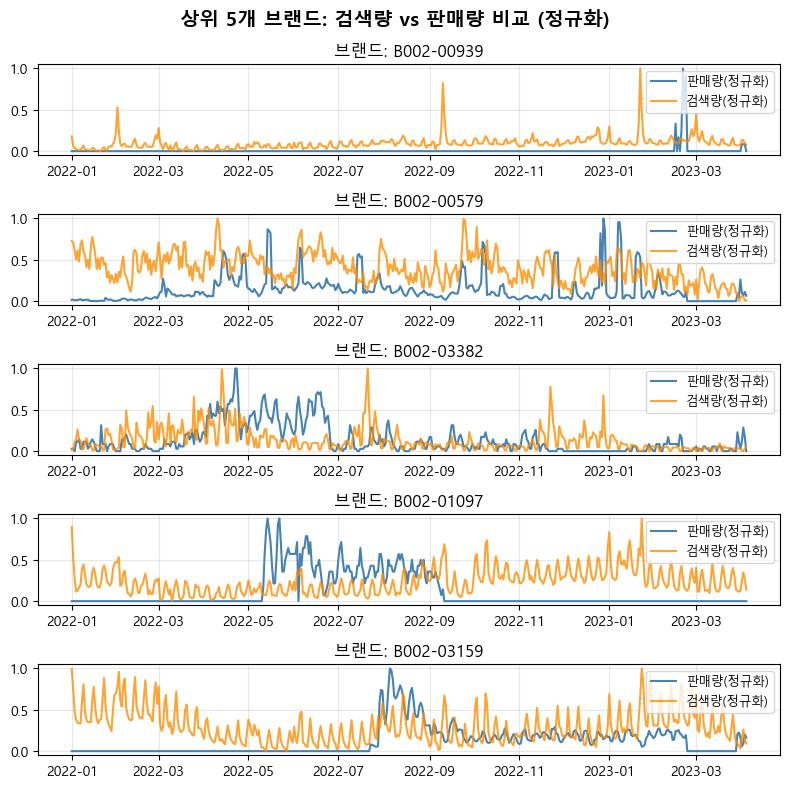

In [18]:
# ── 상위 5개 브랜드 검색량 vs 판매량 비교 ────────────────────────────────
brand_total_kw = keyword[KW_COLS].sum(axis=1)
top5_brands    = keyword.loc[brand_total_kw.nlargest(5).index, '브랜드'].values

def normalize(s):
    """0~1 범위로 정규화 — 스케일이 달라도 패턴을 나란히 비교할 수 있게"""
    return (s - s.min()) / (s.max() - s.min() + 1e-8)

fig, axes = plt.subplots(5, 1, figsize=(8, 8))
fig.suptitle('상위 5개 브랜드: 검색량 vs 판매량 비교 (정규화)', fontsize=14, fontweight='bold')

for i, brand in enumerate(top5_brands):
    ax = axes[i]
    kw_row    = keyword[keyword['브랜드'] == brand][KW_COLS].iloc[0]
    kw_ts     = pd.Series(kw_row.values, index=pd.to_datetime(KW_COLS))
    brand_qty = train[train['브랜드'] == brand][DATE_COLS].sum(axis=0)
    brand_qty.index = pd.to_datetime(brand_qty.index)
    ax.plot(normalize(brand_qty), color='steelblue',  lw=1.5, label='판매량(정규화)')
    ax.plot(normalize(kw_ts),    color='darkorange', lw=1.5, alpha=0.8, label='검색량(정규화)')
    ax.set_title(f'브랜드: {brand}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

💬 2-7 해석 — 검색량 피처 채택 결론

**전체 평균 상관계수 ≈ 0.02** → 통계적으로는 매우 약한 신호

- 그러나 브랜드별로 상관 방향이 다름 (셀[28] 출력 결과 참조):
- 양의 상관을 보이는 브랜드와 음의 상관을 보이는 브랜드가 혼재
- 평균을 내면 상쇄되어 0에 수렴 → 평균이 낮은 게 "쓸모없다"는 뜻이 아님

**→ 채택 결론: 전 브랜드에 보조 피처로 포함 (`kw_log`, `kw_lag_1`, `kw_lag_3`)**

근거:
1. 피처 3개 추가로 비용(계산량) 작음
2. LSTM은 예측력 없는 피처의 가중치를 자연스럽게 0으로 수렴시킴
3. 상관이 강한 브랜드(r > 0.2)에서 실질적 예측 향상 기대
4. 버리는 것보다 모델에게 판단을 맡기는 게 안전

### 2-8. Cross-Correlation (CCF) — 검색량 선행 효과 확인

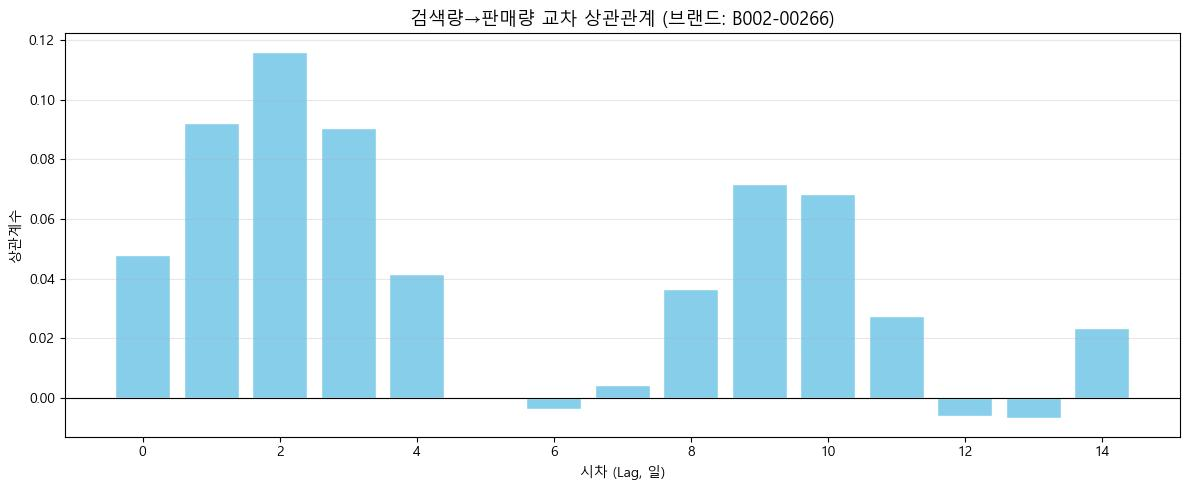

💡 모델링 활용: kw_lag_1, kw_lag_3 피처 설계 근거
   (단, 이는 단일 브랜드 기준 — 전체 평균은 2-7 참고)


In [19]:
# ── 2-8. CCF — 검색량-판매량 교차 상관 (대표 브랜드 1개) ──────────────────────
# "검색 후 며칠 뒤에 구매가 일어나는가?" 를 확인하는 분석
from statsmodels.tsa.stattools import ccf

sample_brand       = train['브랜드'].value_counts().index[0]
brand_sales_series = train[train['브랜드'] == sample_brand][DATE_COLS].sum()
kw_row             = keyword[keyword['브랜드'] == sample_brand]

if len(kw_row) > 0:
    kw_series  = kw_row[KW_COLS].squeeze()
    common_len = min(len(brand_sales_series), len(kw_series))
    sales_arr  = brand_sales_series.values[:common_len].astype(float)
    kw_arr     = kw_series.values[:common_len].astype(float)

    cross_corr = ccf(sales_arr, kw_arr, adjusted=False)

    plt.figure(figsize=(12, 5))
    plt.bar(range(15), cross_corr[:15], color='skyblue', edgecolor='white')
    plt.axhline(0, color='black', lw=0.8)
    plt.title(f'검색량→판매량 교차 상관관계 (브랜드: {sample_brand})', fontsize=13)
    plt.xlabel('시차 (Lag, 일)'); plt.ylabel('상관계수')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    print('💡 모델링 활용: kw_lag_1, kw_lag_3 피처 설계 근거')
    print('   (단, 이는 단일 브랜드 기준 — 전체 평균은 2-7 참고)')


💬 2-8 해석

그래프에서 **Lag 2에서 피크(~0.115)**, Lag 1·3·4까지 유의미하게 유지됨  
Lag 5~6에서 거의 0으로 떨어짐 → 검색 후 약 **2일 뒤 구매**가 가장 많이 발생하는 패턴  
(단일 대표 브랜드 기준이며 전체 평균과 다를 수 있음)  

**→ 모델 피처:** `kw_lag_1`, `kw_lag_3` 근거**

### ✨2-9. ACF / PACF 분석 — 주간 주기성 확인

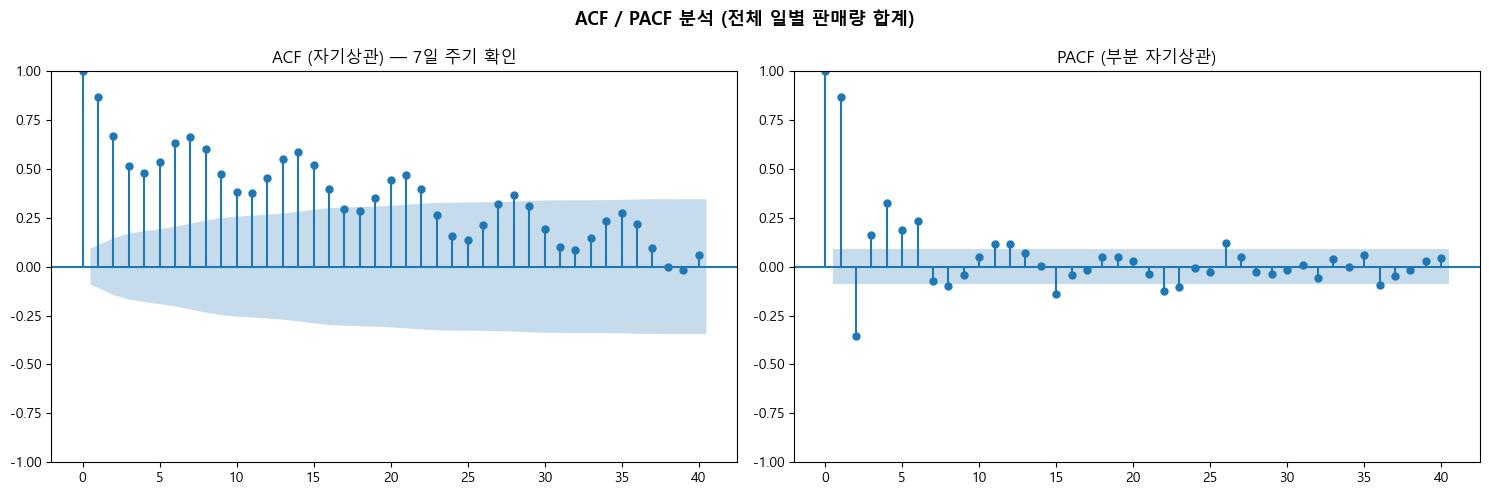

💡 모델링 활용: lag_1, lag_7, lag_14 피처 설계 근거


In [20]:
# ── 2-9. ACF / PACF 분석 ────────────────────────────────────────────────────────
# ACF : 7일, 14일, 21일 간격으로 반복 → 주간 주기 확인
# PACF: Lag 1이 가장 높고 7일 지점에서 재상승 → lag_7 피처 설계 근거
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACF / PACF 분석 (전체 일별 판매량 합계)', fontsize=13, fontweight='bold')
plot_acf(daily_total,  lags=40, ax=axes[0], title='ACF (자기상관) — 7일 주기 확인')
plot_pacf(daily_total, lags=40, ax=axes[1], title='PACF (부분 자기상관)')
plt.tight_layout()
plt.show()
print('💡 모델링 활용: lag_1, lag_7, lag_14 피처 설계 근거')

💬 2-9 해석

**ACF:** Lag 1(~0.85) 이후 서서히 감소하다가 Lag 5~7, 12~14, 19~21 구간에서 규칙적으로 재상승  
→ 7일 간격으로 반복되는 **주간 사이클** 확인  
**PACF:** Lag 1(~0.85) → Lag 2(-0.35)로 급격히 꺾임 → 이후 대부분 신뢰구간 안  
→ 7일 지점의 뚜렷한 재상승은 없음. 주간 주기는 **ACF에서 확인**  
**→ 모델 피처:** `lag_1`, `lag_7` 설계 근거

### 2-10. 시계열 분해 (STL) — 추세·계절성·잔차 분리

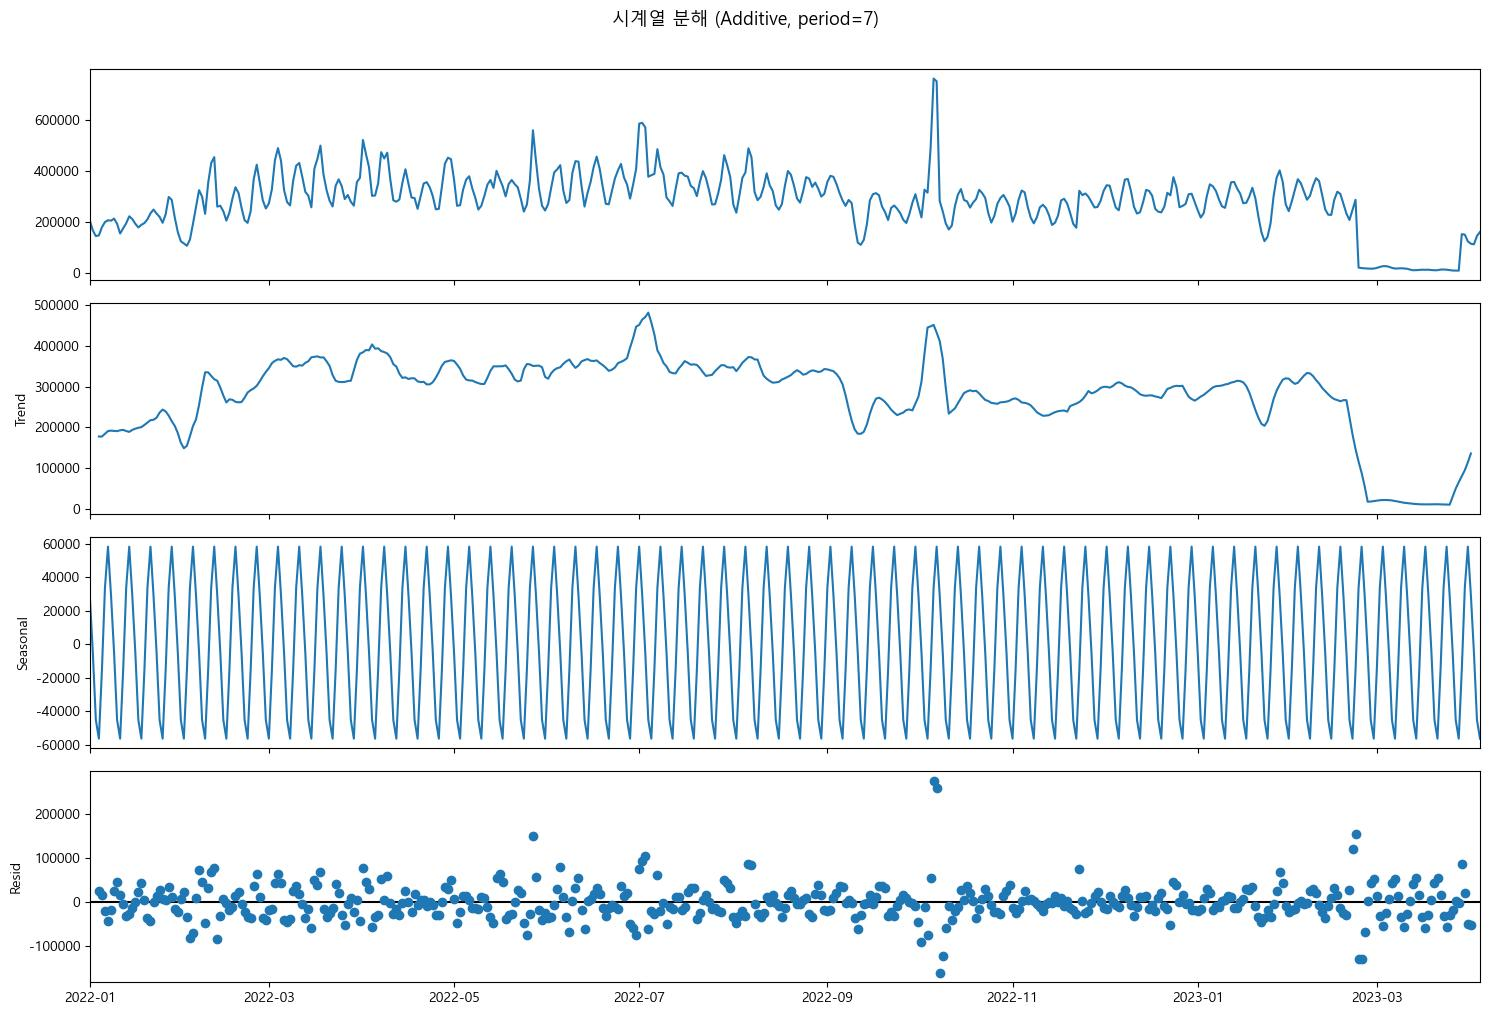

💡 Seasonal: 7일 주기 뚜렷 / Trend: 완만한 상승 후 급락 / Resid: 이벤트성 이상치


In [21]:
# ── 2-10. STL 시계열 분해 ────────────────────────────────────────────────────────
# Trend(추세) + Seasonal(계절성) + Resid(잔차)로 분해해
# 각 성분의 크기와 패턴을 별도로 확인하는 분석
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_total, model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(15, 10)
fig.suptitle('시계열 분해 (Additive, period=7)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('💡 Seasonal: 7일 주기 뚜렷 / Trend: 완만한 상승 후 급락 / Resid: 이벤트성 이상치')

💬 2-10 해석

**Trend:** 완만한 상승 후 2023년 초 급락 → 2-3에서 발견한 급락 구간과 일치  
**Seasonal:** 7일 주기가 매우 뚜렷 → ACF 분석 결과와 일관  
**Resid:** 특정 날 잔차가 큰 구간 = 프로모션/이벤트 구간

### 2-11. ADF 정상성 검정 — 차분 필요 여부 확인

In [22]:
# ── 2-11. ADF Test — 시계열이 "안정적"인지 확인 ─────────────────────────────────
# 정상성(Stationary): 평균·분산이 시간에 따라 변하지 않는 상태
# 비정상성이면 → log 변환 또는 차분으로 안정화 필요
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, label=''):
    result     = adfuller(series)
    stationary = result[1] <= 0.05
    status     = '✅ 정상성(Stationary)' if stationary else '⚠️ 비정상성(Non-Stationary)'
    print(f'[{label}] ADF={result[0]:.4f}  p-value={result[1]:.4f}  → {status}')
    return stationary

print('=' * 55)
check_stationarity(daily_total,                 label='원본 데이터')
check_stationarity(daily_total.diff().dropna(), label='1차 차분')
print('=' * 55)
print('💡 비정상성 → log1p 변환으로 안정화 (STEP 3 적용 예정)')

[원본 데이터] ADF=-1.8483  p-value=0.3568  → ⚠️ 비정상성(Non-Stationary)
[1차 차분] ADF=-7.5020  p-value=0.0000  → ✅ 정상성(Stationary)
💡 비정상성 → log1p 변환으로 안정화 (STEP 3 적용 예정)


💬 2-11 해석

원본이 비정상성이라면 → **log1p 변환**(STEP 3에서 적용)으로 안정화  
LSTM은 내부적으로 장기 패턴을 학습하므로 별도 차분은 불필요

### 2-12. 대분류별 시즌성 히트맵

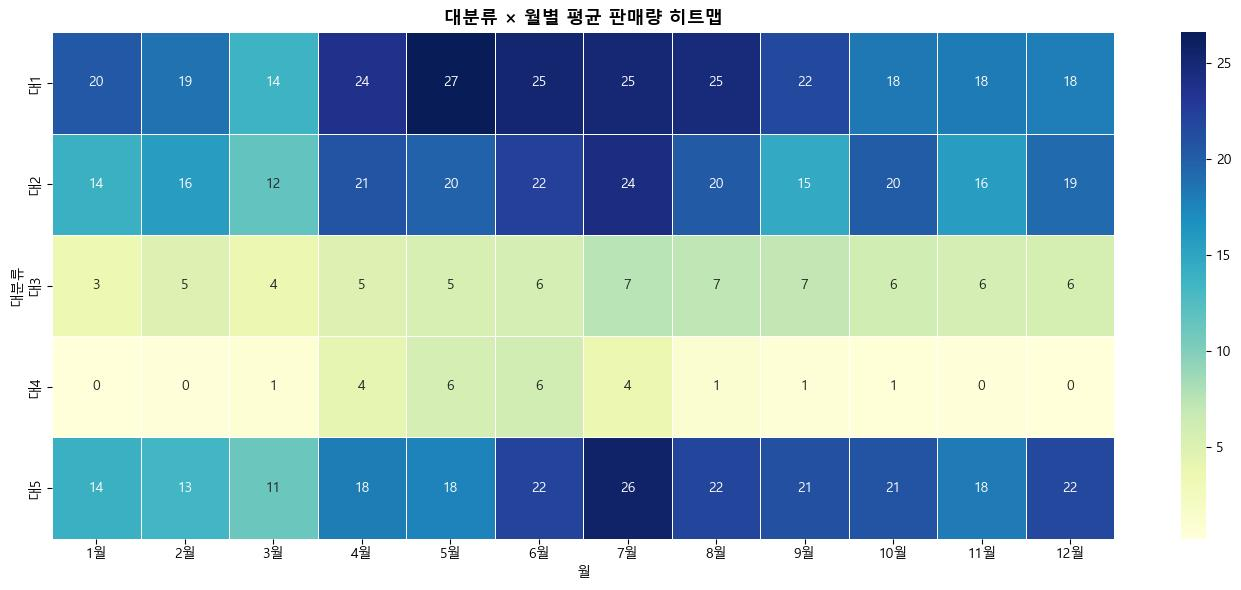

💡 카테고리별 시즌성이 다름 → 모델에 대분류 정보 강하게 반영 필요


In [23]:
# ── 2-12. 대분류 × 월별 평균 판매량 히트맵 ─────────────────────────────────────
# 카테고리마다 잘 팔리는 달이 다른지 확인 (시즌성이 카테고리별로 다르면 임베딩 필요)
train_melted = train.melt(id_vars=['대분류'], value_vars=DATE_COLS,
                          var_name='date', value_name='qty')
train_melted['month'] = pd.to_datetime(train_melted['date']).dt.month
pivot = train_melted.pivot_table(index='대분류', columns='month', values='qty', aggfunc='mean')

# short_label 적용
pivot.index   = [cat_labels['대분류'].get(i, i) for i in pivot.index]
month_kor     = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
pivot.columns = month_kor

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5)
plt.title('대분류 × 월별 평균 판매량 히트맵', fontsize=13, fontweight='bold')
plt.xlabel('월'); plt.ylabel('대분류')
plt.tight_layout()
plt.show()
print('💡 카테고리별 시즌성이 다름 → 모델에 대분류 정보 강하게 반영 필요')

💬 2-12 해석

카테고리마다 계절성 패턴이 다름 → 하나의 모델이 모든 카테고리를 학습하려면 카테고리 정보를 명시적으로 제공해야 함  
**→ `대분류_enc` 피처를 임베딩 레이어로 강하게 반영**

### ✨✨2-13. 한국 공휴일 vs 판매량

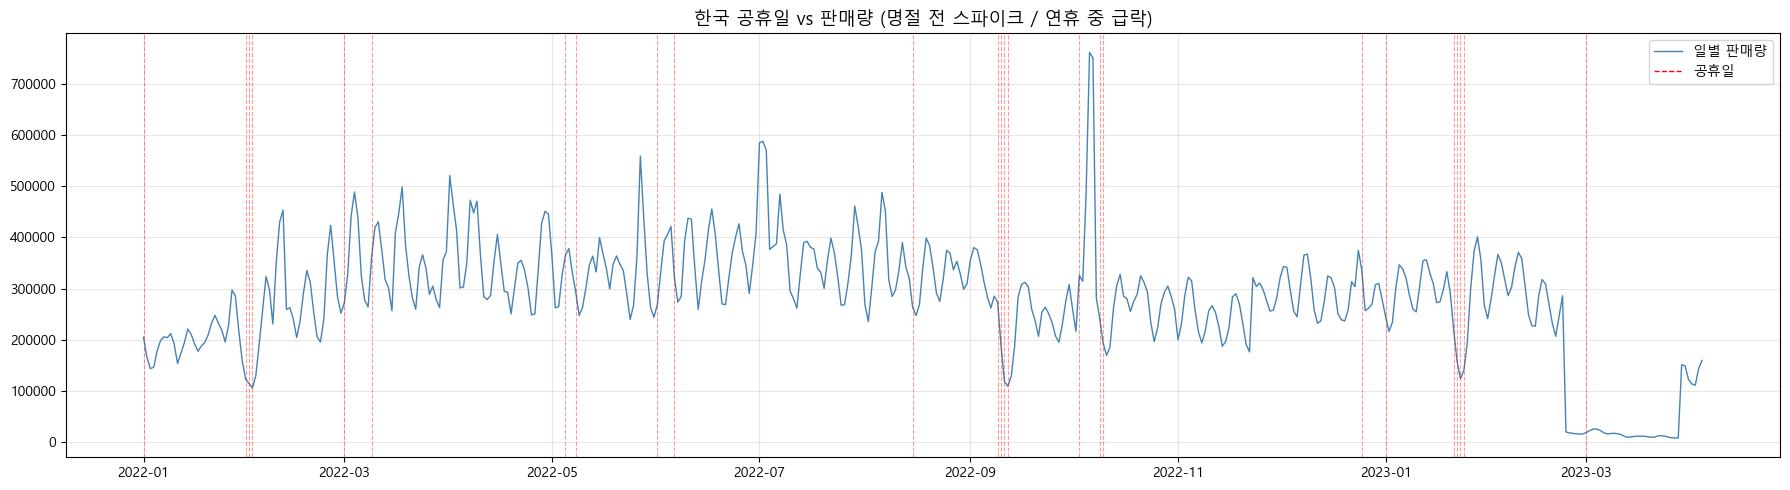

💡 공휴일 D-3 사전 구매 수요 → is_holiday, days_to_holiday 피처 설계 근거


In [24]:
# ── 2-13. 한국 공휴일 vs 판매량 시각화 ─────────────────────────────────────────
# 명절 전: 사전 구매 수요 스파이크 / 명절 중: 판매 급락
# → is_holiday, days_to_holiday 피처 설계 근거
import holidays as hol

kr_holidays   = hol.KR(years=[2022, 2023])
holiday_dates = pd.to_datetime([str(d) for d in kr_holidays.keys()])
holiday_dates = holiday_dates[
    (holiday_dates >= daily_total.index.min()) &
    (holiday_dates <= daily_total.index.max())
]

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=1, label='일별 판매량')
for h in holiday_dates:
    ax.axvline(h, color='red', alpha=0.4, linestyle='--', lw=0.8)
ax.plot([], [], color='red', linestyle='--', lw=1, label='공휴일')
ax.set_title('한국 공휴일 vs 판매량 (명절 전 스파이크 / 연휴 중 급락)', fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('💡 공휴일 D-3 사전 구매 수요 → is_holiday, days_to_holiday 피처 설계 근거')

💬 2-13 해석

**명절 전:** 사전 구매 수요 스파이크 (D-3 ~ D-7 구간)  
**명절 중:** 판매 급락 (V자형 골짜기)  
**→ `is_holiday`, `days_to_holiday` 피처로 이 패턴을 모델에게 알려줘야 함**

----

### 🗺️ EDA 요약 — STEP 3 전처리 결정사항

| 발견 사항 | → | 전처리 결정 | 담당 STEP |
|----------|---|------------|----------|
| 2023-02-20 이후 급락 구간 | → | **3방법 중 선택 처리** | 3-0 |
| Spike = 이벤트성 판매 (중복 아님) | → | **중앙값×20 클리핑** | 3-1 |
| train(qty) + sales(revenue) 분리 | → | **단가(price) 파생** | 3-2 |
| Wide 포맷 → LSTM 학습 불가 | → | **Long 포맷 변환** | 3-3 |
| 구조적 0 존재 (출시 전) | → | **first_sale_date 기준 마스킹** | 3-4 |
| 카테고리가 텍스트 → 모델 입력 불가 | → | **LabelEncoder 인코딩** | 3-5 |
| 검색량 보조 신호 (브랜드별 편차) | → | **kw_log, kw_lag_1, kw_lag_3 병합** | 3-6 |
| 0이 63.8% + Long Tail 분포 | → | **log1p 변환** | 모델 Dataset 클래스 내 |

> **log1p를 여기서 안 하는 이유:** df에 원본 qty를 유지해야 디버깅이 쉽고,
> 역변환(expm1)을 Dataset 클래스 한 곳에서 관리할 수 있음
```

---
## STEP 3 — 데이터 전처리

### ✨✨3-0. 급락 구간 처리 — 5가지 방법 선택 및 비교

2023-02-20 이후 판매량이 정상 대비 ~16%로 급락하는 구간(EDA 2-3 참고)을 어떻게 처리하느냐에 따라 모델 학습 품질이 달라지므로, 5가지 방법을 구현하고 비교한 뒤 선택한다

```
OUTLIER_METHOD = 1 → 급락 기간 날짜 컬럼 자체를 학습에서 제외  
OUTLIER_METHOD = 2 → 합성 데이터 복원 (전년 동기 실제값 × 성장률 보정)  
OUTLIER_METHOD = 3 → 이동평균 7일 + 요일별 보정으로 값 교체   
OUTLIER_METHOD = 4 → 이동평균 30일 + 요일별 보정으로 값 교체   
OUTLIER_METHOD = 5 → 원본 유지 + is_post_crash 플래그 생성 (모델이 직접 판단)
```

* **METHOD 1 (급락 제외):**  
  - 급락 구간(2023-02-20 ~ 2023-04-04, 44일)의 날짜 컬럼을 학습 데이터에서 통째로 삭제  
  - 장점: 오염된 데이터를 확실히 제거 / 단점: 전체 학습 기간의 ~10% 손실

* **METHOD 2 (전년 동기 복원):**  
  - 전년 같은 날짜(2022-02-20 ~ 2022-04-04)의 **실제 판매량**을 가져온 뒤, 제품별 성장률을 곱해 보정  
  - 성장률 = 급락 직전 30일 평균 ÷ 전년 같은 30일 평균  
  - 44일 각각이 고유한 값 → 가장 "진짜 같은" 합성 데이터  
  - ⚠️ 성장률 폭발 방지: 제품별 성장률의 5~95% 백분위수로 cap 적용  
  - 약점: "작년 이맘때 패턴 ≈ 올해 이맘때 패턴"이라는 가정이 깔림

* **METHOD 3 (이동평균 7일 + 요일 보정):**  
  - 급락 직전 7일의 **요일별 평균**을 구해서, 급락 구간의 각 요일에 맞는 값으로 대체  
  - EDA 2-4에서 확인한 요일 패턴(목·금 높음, 월·화 낮음)이 보존됨  
  - 장점: 최근 흐름에 민감 / 단점: 7일은 샘플이 적어 노이즈에 민감

* **METHOD 4 (이동평균 30일 + 요일 보정):**  
  - Method 3과 동일한 로직이지만, 급락 직전 **30일**을 참고  
  - 장점: 4주 이상의 평균이므로 안정적 / 단점: 트렌드 변화에 둔감

* **METHOD 5 (원본 유지 + 플래그):**  
  - 급락 구간을 건드리지 않고 원본 그대로 유지  
  - 대신 `is_post_crash` 플래그(0/1)를 생성해 모델에게 "이 구간은 급락이다"라고 알려줌  
  - 합성 데이터를 아예 만들지 않으므로 가정이 가장 적음

In [25]:
# ── 3-0. 급락 구간 수치 확인 ───────────────────────────────────────────────────
# ⚠️ CRASH_START, CRASH_END, daily_total 은 EDA 2-3에서 이미 정의됨
#
# 이 셀은 "급락이 얼마나 심각한지"를 숫자로 보여주는 역할입니다.
# 아래 셀들에서 5가지 방법을 비교한 뒤, 맨 마지막 셀에서 방법을 선택합니다.

crash_mask = (daily_total.index >= CRASH_START) & (daily_total.index <= CRASH_END)
normal_avg = daily_total[daily_total.index < CRASH_START].mean()
crash_avg  = daily_total[crash_mask].mean()

print('=' * 55)
print('📊 급락 구간 분석')
print('=' * 55)
print(f'  정상 구간 일평균  : {normal_avg:>10,.0f}')
print(f'  급락 구간 일평균  : {crash_avg:>10,.0f}')
print(f'  급락 비율         : {crash_avg/normal_avg:.1%}')
print(f'  급락 기간         : {CRASH_START.date()} ~ {CRASH_END.date()} ({crash_mask.sum()}일)')

📊 급락 구간 분석
  정상 구간 일평균  :    305,103
  급락 구간 일평균  :     49,274
  급락 비율         : 16.2%
  급락 기간         : 2023-02-20 ~ 2023-04-04 (44일)


#### 🔧 함수 선언 — `apply_method1` ~ `apply_method5`

급락 구간을 처리하는 5가지 함수입니다.  
아래 비교 시각화 셀에서 5개를 모두 실행해 결과를 비교한 뒤, 마지막 셀에서 하나를 선택·적용합니다.

| 함수 | 전략 | 반환값 |
|------|------|--------|
| `apply_method1` | 급락 기간 날짜 컬럼 제외 | (train_out, date_cols_out) |
| `apply_method2` | 전년 동기 × 성장률 복원 | (train_out, date_cols) |
| `apply_method3` | 이동평균 7일 + 요일 보정 | (train_out, date_cols) |
| `apply_method4` | 이동평균 30일 + 요일 보정 | (train_out, date_cols) |
| `apply_method5` | 원본 유지 + 플래그 | (train_out, date_cols, crash_flag_dict) |

In [26]:
# ── 5가지 방법 함수 정의 ───────────────────────────────────────────────────


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 1: 급락 기간 날짜를 통째로 삭제
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method1(train_df, date_cols, crash_start, crash_end):
    """급락 기간 날짜 컬럼을 학습에서 제외 — 가장 단순하지만 데이터 손실"""
    # 급락 구간에 해당하는 날짜 컬럼 목록
    crash_cols    = [c for c in date_cols if crash_start <= pd.Timestamp(c) <= crash_end]
    # 해당 컬럼을 drop해서 학습 데이터에서 제외
    train_out     = train_df.drop(columns=crash_cols)
    date_cols_out = [c for c in date_cols if c not in crash_cols]
    print(f'[Method 1] 제외 날짜: {len(crash_cols)}일 → 잔여 학습일: {len(date_cols_out)}일')
    return train_out, date_cols_out


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 2: 전년 동기 실제값 × 성장률로 복원
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method2(train_df, date_cols, crash_start, crash_end):
    """전년 동기 실제값 × 성장률로 합성 데이터 복원 (성장률 cap 적용)"""
    train_out   = train_df.copy()
    date_index  = pd.to_datetime(date_cols)
    crash_mask  = (date_index >= crash_start) & (date_index <= crash_end)
    crash_cols  = [c for c, m in zip(date_cols, crash_mask) if m]

    # ── 1단계: 급락 직전 30일 & 전년 같은 30일 컬럼 찾기 ──────────────
    pre_start = crash_start - pd.Timedelta(days=30)
    pre_end   = crash_start - pd.Timedelta(days=1)
    pre_cols  = [c for c in date_cols
                 if pre_start <= pd.Timestamp(c) <= pre_end]

    # 전년 동기 30일 (학습 데이터에 존재하는 날짜만)
    prev_year_pre_cols = [
        str((pd.Timestamp(c) - pd.DateOffset(years=1)).date())
        for c in pre_cols
    ]
    prev_year_pre_cols = [c for c in prev_year_pre_cols if c in date_cols]

    # ── 2단계: 제품별 성장률 계산 ──────────────────────────────────────
    if len(pre_cols) > 0 and len(prev_year_pre_cols) > 0:
        recent_avg = train_df[pre_cols].mean(axis=1)            # 올해 직전 30일 제품별 평균
        prev_avg   = train_df[prev_year_pre_cols].mean(axis=1)  # 작년 같은 기간 제품별 평균
        # 작년 평균이 0이면 성장률 1.0(변화 없음)으로 처리
        growth_rate_raw = np.where(prev_avg > 0, recent_avg / prev_avg, 1.0)
    else:
        growth_rate_raw = np.ones(len(train_df))

    # ── 3단계: 성장률 cap 적용 (5~95 백분위수) ─────────────────────────
    # 왜 cap이 필요한가:
    #   작년에 거의 안 팔리다가 올해 팔리기 시작한 제품은
    #   성장률이 50배, 100배로 폭발 → 합성값이 비현실적으로 커짐
    #   95% 백분위수로 cap을 걸면 정상적인 95%의 제품은 그대로 두고
    #   극단적인 5%만 제한하는 효과
    valid_rates = growth_rate_raw[growth_rate_raw > 0]
    cap_lower   = np.percentile(valid_rates, 5)
    cap_upper   = np.percentile(valid_rates, 95)
    growth_rate = np.clip(growth_rate_raw, cap_lower, cap_upper)

    # 성장률 분포 출력 (디버깅 & 의사결정용)
    print(f'[Method 2] 성장률 분포 (cap 적용 전):')
    print(f'  중앙값: {np.median(valid_rates):.2f}  |  '
          f'25%: {np.percentile(valid_rates, 25):.2f}  |  '
          f'75%: {np.percentile(valid_rates, 75):.2f}  |  '
          f'95%: {cap_upper:.2f}  |  '
          f'최대: {valid_rates.max():.1f}')
    print(f'  → cap 범위: {cap_lower:.2f} ~ {cap_upper:.2f}')

    # ── 4단계: 급락 구간 각 날짜를 전년 동기 실제값 × 성장률로 대체 ──
    replaced = 0
    for col in crash_cols:
        prev_year_col = str((pd.Timestamp(col) - pd.DateOffset(years=1)).date())
        if prev_year_col in date_cols:
            train_out[col] = (train_df[prev_year_col] * growth_rate).round().clip(lower=0)
            replaced += 1
        else:
            # 전년 데이터 없으면 급락 직전 30일 평균으로 폴백
            train_out[col] = train_df[pre_cols].mean(axis=1).round().clip(lower=0)

    print(f'[Method 2] 전년 동기 복원 완료: {replaced}/{len(crash_cols)}일')
    return train_out, date_cols


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 3 & 4 공통 로직: 이동평균 + 요일별 보정
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 3(7일)과 Method 4(30일)는 window 크기만 다르고 로직이 동일하므로
# 공통 함수 _apply_ma_dow()를 만들고, 각 method에서 호출합니다.

def _apply_ma_dow(train_df, date_cols, crash_start, crash_end, window_days, method_name):
    """이동평균 + 요일별 보정 공통 로직
    
    채우기 방식 (B): 직전 N일의 요일별 평균으로 대체
    - 예) 7일 window → 직전 월~일 각 요일의 평균을 구해서
          급락 구간의 월요일엔 월요일 평균, 금요일엔 금요일 평균을 넣음
    - EDA 2-4에서 확인한 요일 패턴(목·금 높음, 월·화 낮음)이 보존됨
    """
    train_out   = train_df.copy()
    date_index  = pd.to_datetime(date_cols)
    crash_mask  = (date_index >= crash_start) & (date_index <= crash_end)
    crash_cols  = [c for c, m in zip(date_cols, crash_mask) if m]

    # ── 급락 직전 N일 컬럼 찾기 ────────────────────────────────────────
    pre_start = crash_start - pd.Timedelta(days=window_days)
    pre_end   = crash_start - pd.Timedelta(days=1)
    pre_cols  = [c for c in date_cols
                 if pre_start <= pd.Timestamp(c) <= pre_end]

    # ── 요일별 그룹핑 (직전 N일 내에서 같은 요일끼리 묶기) ─────────────
    # 0=월, 1=화, ..., 6=일
    dow_groups = {d: [] for d in range(7)}
    for c in pre_cols:
        dow = pd.Timestamp(c).dayofweek
        dow_groups[dow].append(c)

    # ── 요일별 제품별 평균값 계산 ──────────────────────────────────────
    dow_means = {}
    for dow, cols_list in dow_groups.items():
        if len(cols_list) > 0:
            # 해당 요일에 해당하는 날짜들의 제품별 평균
            dow_means[dow] = train_df[cols_list].mean(axis=1)
        else:
            # window 안에 해당 요일이 없으면 전체 평균으로 폴백
            # (7일 window에서는 모든 요일이 1개씩 있으므로 거의 발생 안 함)
            dow_means[dow] = train_df[pre_cols].mean(axis=1) if len(pre_cols) > 0 else 0

    # ── 급락 구간의 각 날짜를 해당 요일 평균으로 대체 ──────────────────
    for col in crash_cols:
        dow = pd.Timestamp(col).dayofweek
        train_out[col] = dow_means[dow].round().clip(lower=0)

    print(f'[{method_name}] 이동평균 {window_days}일 + 요일 보정 완료: {len(crash_cols)}일')
    return train_out, date_cols


def apply_method3(train_df, date_cols, crash_start, crash_end):
    """이동평균 7일 + 요일별 보정으로 급락 구간 값 교체"""
    return _apply_ma_dow(train_df, date_cols, crash_start, crash_end,
                         window_days=7, method_name='Method 3')


def apply_method4(train_df, date_cols, crash_start, crash_end):
    """이동평균 30일 + 요일별 보정으로 급락 구간 값 교체"""
    return _apply_ma_dow(train_df, date_cols, crash_start, crash_end,
                         window_days=30, method_name='Method 4')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 5: 원본 유지 + 플래그
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method5(train_df, date_cols, crash_start, crash_end):
    """원본 유지 + is_post_crash 플래그 생성 — 모델이 급락 패턴을 직접 학습"""
    # 각 날짜가 급락 시작일 이후인지 0/1로 표시
    crash_flag = {c: int(pd.Timestamp(c) >= crash_start) for c in date_cols}
    n_crash    = sum(crash_flag.values())
    print(f'[Method 5] 원본 유지, is_post_crash 플래그 생성 (급락 후: {n_crash}일)')
    return train_df.copy(), date_cols, crash_flag

#### ⚙️ 방법 선택 및 적용

위 비교 시각화를 확인한 뒤, 아래 셀에서 `OUTLIER_METHOD` 값을 변경하세요.  
아래 셀을 실행하면 선택한 방법이 실제로 적용됩니다.

* 5를 선택한 로직 : **가정이 가장 적기 때문**

* Method 2, 3, 4는 급락 구간에 **내가 만든 가짜 숫자**를 넣음
- Method 2: "작년 패턴이 올해와 비슷할 것이다"  ← 가정
- Method 3: "직전 7일이 대표적일 것이다"       ← 가정  
- Method 4: "직전 30일이 대표적일 것이다"      ← 가정

```
* 이 가정이 틀리면, 모델은 **실제로 존재하지 않았던 패턴을 "진짜"라고 학습** --> 아까 Method 2에서 성장률이 폭발한 게 그 예시
```
- Method 5: 원본 그대로 + "여긴 급락이야"라는 표시만 → 가정 없음. 모델이 직접 판단

==> 그래서 5로 모델링까지 돌려보고 outlier_method = 4로 다시 모델링 해보는 방법으로 해보려고 함

In [27]:
# ── 급락 구간 분석 ─────────────────────────────────────────────────────────
# ⚠️ CRASH_START, CRASH_END, daily_total 은 2-3에서 이미 정의됨
#
# ⚙️  방법 선택 (1~5 중 하나) — 비교 시각화를 본 뒤 변경하세요
OUTLIER_METHOD = 5   # ← 여기서 최종 선택

# ── 선택한 방법 실제 적용 ─────────────────────────────────────────────────
if OUTLIER_METHOD == 1:
    train_m, DATE_COLS_M = apply_method1(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 2:
    train_m, DATE_COLS_M = apply_method2(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 3:
    train_m, DATE_COLS_M = apply_method3(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 4:
    train_m, DATE_COLS_M = apply_method4(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
else:  # Method 5
    train_m, DATE_COLS_M, crash_flag_dict = apply_method5(train, DATE_COLS, CRASH_START, CRASH_END)

print(f'\n✅ Method {OUTLIER_METHOD} 적용 완료  /  학습 날짜 수: {len(DATE_COLS_M)}일')

[Method 5] 원본 유지, is_post_crash 플래그 생성 (급락 후: 44일)

✅ Method 5 적용 완료  /  학습 날짜 수: 459일


### ✨3-1. Spike 클리핑 — 개별 제품 이상치 제거

💬 3-1 해석 — CLIP_FACTOR 결정 근거

**검증 1: 제품별 최대/중앙값 비율 분포**

| 백분위수 | 비율 |
|----------|------|
| 중앙값 | 8.7배 |
| 75% | 17.8배 |
| 90% | 40.8배 |
| 95% | 71.3배 |
| 최대 | 16,427배 |

- 분석 대상: 중앙값 > 0인 5,266개 제품 (전체 15,890개 중 나머지 10,624개는 중앙값 = 0)
- 중앙값 = 0인 제품은 CLIP_FACTOR와 무관하게 95분위수로 클리핑됨

**검증 2: CLIP_FACTOR = 20 vs 40 비교**

| 항목 | 20 | 40 |
|------|-----|-----|
| 클리핑된 제품 수 | 8,472개 (53.3%) | 7,864개 (49.5%) |
| 총 판매량 손실률 | 11.06% | 8.37% |
| 클리핑 후 최대값 | 38,384 | 38,384 |

- 20 → 40으로 2배 늘려도 클리핑 제품 수는 608개(3.8%p)밖에 안 줄어듦
- 원인: 전체 15,890개 중 10,624개(중앙값=0)는 CLIP_FACTOR에 영향을 받지 않음
- 두 그래프 모두 Spike 피크가 동일하게 제거됨 (클리핑 후 최대값 동일)

**최종 결정: CLIP_FACTOR = 40**

- Spike 제거 효과는 20과 동일 (빨간 피크 모두 사라짐)
- 판매량 손실이 11% → 8%로 감소 (2.7%p 절약 = 학습 데이터 보존)
- 추가로 살리는 608개 제품은 비율 20~40배 구간 → 이벤트성 실제 판매일 가능성이 높아 보존이 유리
- 즉, "극단값 제거 효과는 유지하면서 데이터 손실을 줄이는" 보수적 기준

In [28]:
# ── 3-1. Spike 클리핑 (벡터 연산 버전) ─────────────────────────────────────────
# 제품별 극단값을 상한선으로 깎아서, 이벤트 신호는 살리되
# 극단값이 loss를 지배하는 것만 방지합니다.
#
# 기존: for 루프로 15,890개 제품을 하나씩 처리 (느림)
# 개선: pandas 벡터 연산으로 한 번에 처리 (빠름)

CLIP_FACTOR = 40   # ← 위 검증 결과를 보고 필요시 변경

# 💡 네 말대로 맨 위에서 먼저 복사본을 만들고 시작한다!
train_clean = train_m.copy()
qty_data = train_clean[DATE_COLS_M].astype(float)

# ── 제품별 상한선 계산 ────────────────────────────────────────────────────
# 중앙값 > 0인 제품: 상한선 = 중앙값 × CLIP_FACTOR
# 중앙값 = 0인 제품: 상한선 = 95% 분위수 (거의 안 팔리는 제품용)
# 95% 분위수도 0인 제품: 상한선 = inf (클리핑 안 함, 어차피 거의 0)

medians = qty_data.median(axis=1)
q95     = qty_data.quantile(0.95, axis=1)

upper_limit = np.where(
    medians > 0,
    medians * CLIP_FACTOR,          # 일반 제품: 중앙값 × 20
    np.where(q95 > 0, q95, np.inf)  # 중앙값=0인 제품: 95분위 or 스킵
)

# ── 클리핑 적용 (벡터 연산) ───────────────────────────────────────────────
# 각 제품(행)마다 해당 상한선으로 clip
# .clip()에 axis=0으로 행별 상한선을 적용
before_max = qty_data.max(axis=1)
clipped    = qty_data.clip(upper=pd.Series(upper_limit, index=qty_data.index), axis=0)

# 클리핑 결과를 train_clean에 반영
train_clean = train_m.copy()
train_clean[DATE_COLS_M] = clipped

# ── 결과 요약 ─────────────────────────────────────────────────────────────
after_max     = clipped.max(axis=1)
clipped_count = (before_max > after_max).sum()

print('=' * 55)
print('📊 Spike 클리핑 결과')
print('=' * 55)
print(f'  CLIP_FACTOR       : {CLIP_FACTOR}배')
print(f'  클리핑된 제품 수  : {clipped_count:,}개')
print(f'  클리핑 전 최대값  : {before_max.max():,.0f}')
print(f'  클리핑 후 최대값  : {after_max.max():,.0f}')
print(f'  압축 비율         : {before_max.max() / max(after_max.max(), 1):,.1f}배 축소')
print()
print('✅ 원본: train_m  /  클린버전: train_clean')

📊 Spike 클리핑 결과
  CLIP_FACTOR       : 40배
  클리핑된 제품 수  : 7,864개
  클리핑 전 최대값  : 200,420
  클리핑 후 최대값  : 38,384
  압축 비율         : 5.2배 축소

✅ 원본: train_m  /  클린버전: train_clean


### ✨3-2. 단가(Price) 파생 — revenue ÷ qty

train.csv(판매량)와 sales.csv(매출액)를 나누어 제품별 일별 단가를 계산합니다.

| 상황 | 처리 |
|------|------|
| qty > 0 | price = revenue ÷ qty (실제 단가) |
| qty = 0 | NaN → ffill (직전 판매일의 단가를 이어받음) |
| ffill 후 남은 NaN | 제품별 중앙 단가로 채움 (첫 판매 전 구간, 3-4에서 마스킹되므로 실질 영향 없음) |

**왜 중앙값이 아니라 ffill인가:**  
중앙값은 과거 세일가와 현재 정상가의 평균이 들어가서, 안 팔린 날마다 가격이 출렁이는 가짜 노이즈가 생깁니다.  
ffill은 "어제 가격이 오늘도 유지된다"는 현실적인 가정이고, LSTM의 시계열 흐름을 깨뜨리지 않습니다.

In [29]:
# ── 3-2. 단가 파생 ─────────────────────────────────────────────────────────────
# sales.csv = 매출액(revenue) / train.csv = 판매량(qty)
# → 단가 = revenue ÷ qty
# → qty=0인 날은 단가를 계산할 수 없으므로 NaN 처리 후 ffill로 채움

price_df = sales[META_COLS].copy()

# ── 1단계: qty > 0인 날만 단가 계산, 나머지는 NaN ─────────────────────
for col in DATE_COLS_M:
    price_df[col] = np.where(
        train_clean[col] > 0,
        sales[col] / train_clean[col],   # 실제 단가
        np.nan                            # 안 팔린 날은 NaN
    )

# ── 2단계: ffill — 직전 판매일의 단가를 이어받음 ──────────────────────
# 현실: 제품이 오늘 안 팔려도 가격표는 어제와 같다
# 중앙값 대신 ffill을 쓰는 이유:
#   - 중앙값: 과거 세일가 + 현재 정상가의 평균 → 실제 시점 가격과 동떨어짐
#   - ffill: 직전 가격 유지 → 시계열 흐름이 자연스럽고 LSTM에 노이즈 없음
price_df[DATE_COLS_M] = price_df[DATE_COLS_M].ffill(axis=1)

# ── 3단계: 안전장치 — ffill로도 안 채워지는 NaN은 제품별 중앙값 ──────
# 첫 판매 전 구간이 여기 해당하지만, 3-4 구조적 0 마스킹에서 빠지므로 실질 영향 없음
price_median = price_df[DATE_COLS_M].median(axis=1)
for col in DATE_COLS_M:
    price_df[col] = price_df[col].fillna(price_median)

# ── 결과 확인 ─────────────────────────────────────────────────────────────
nan_pct = price_df[DATE_COLS_M].isna().mean().mean()
print(f'NaN 비율 (최종): {nan_pct:.4%}')
print(f'단가 범위: {price_df[DATE_COLS_M].min().min():.0f} ~ {price_df[DATE_COLS_M].max().max():,.0f}')
print('✅ price_df 생성 완료 (ffill + 중앙값 폴백)')

NaN 비율 (최종): 0.5349%
단가 범위: 0 ~ 214,349,500
✅ price_df 생성 완료 (ffill + 중앙값 폴백)


In [30]:
# ── 단가 이상치 확인 ──────────────────────────────────────────────────────
price_vals = price_df[DATE_COLS_M].values.flatten()
price_vals = price_vals[~np.isnan(price_vals)]
price_vals = price_vals[price_vals > 0]

print('=' * 55)
print('📊 단가 분포 확인')
print('=' * 55)
print(f'  중앙값        : {np.median(price_vals):,.0f}원')
print(f'  평균          : {np.mean(price_vals):,.0f}원')
print(f'  75%           : {np.percentile(price_vals, 75):,.0f}원')
print(f'  90%           : {np.percentile(price_vals, 90):,.0f}원')
print(f'  95%           : {np.percentile(price_vals, 95):,.0f}원')
print(f'  99%           : {np.percentile(price_vals, 99):,.0f}원')
print(f'  최대          : {np.max(price_vals):,.0f}원')
print()

# 상위 극단값 제품 확인
print('📌 단가 상위 10개 (어떤 제품이 이상한지)')
price_max_per_product = price_df[DATE_COLS_M].max(axis=1)
top10 = price_max_per_product.nlargest(10)
for idx in top10.index:
    pid = price_df.loc[idx, 'ID']
    cat = price_df.loc[idx, '대분류']
    max_price = top10[idx]
    # 해당 제품의 qty와 revenue도 확인
    qty_vals = train_clean.loc[idx, DATE_COLS_M]
    rev_vals = sales.loc[idx, DATE_COLS_M]
    print(f'  {pid} [{cat}] 최대단가: {max_price:>15,.0f}원'
          f'  | qty범위: {qty_vals.min():.0f}~{qty_vals.max():.0f}'
          f'  | rev범위: {rev_vals.min():.0f}~{rev_vals.max():,.0f}')

# NaN 잔여 확인
nan_products = price_df[DATE_COLS_M].isna().all(axis=1).sum()
print(f'\n📌 전 기간 NaN인 제품 수: {nan_products}개 (= 한 번도 안 팔린 제품, 3-4에서 마스킹 예정)')

📊 단가 분포 확인
  중앙값        : 9,900원
  평균          : 19,779원
  75%           : 20,800원
  90%           : 38,520원
  95%           : 58,328원
  99%           : 165,000원
  최대          : 214,349,500원

📌 단가 상위 10개 (어떤 제품이 이상한지)
  11251 [B002-C001-0001] 최대단가:     214,349,500원  | qty범위: 0~0  | rev범위: 0~21,434,950
  11366 [B002-C001-0002] 최대단가:      34,825,000원  | qty범위: 0~1  | rev범위: 0~34,825,000
  13530 [B002-C001-0002] 최대단가:      15,266,250원  | qty범위: 0~1  | rev범위: 0~15,266,250
  14639 [B002-C001-0001] 최대단가:       8,257,000원  | qty범위: 0~3  | rev범위: 0~24,771,000
  1420 [B002-C001-0001] 최대단가:       7,899,050원  | qty범위: 0~2  | rev범위: 0~15,798,100
  6334 [B002-C001-0002] 최대단가:       5,300,952원  | qty범위: 0~2  | rev범위: 0~11,132,000
  11301 [B002-C001-0002] 최대단가:       4,980,000원  | qty범위: 0~0  | rev범위: 0~498,000
  7899 [B002-C001-0002] 최대단가:       4,798,000원  | qty범위: 0~0  | rev범위: 0~479,800
  7725 [B002-C001-0001] 최대단가:       4,775,902원  | qty범위: 0~6  | rev범위: 0~29,133,000
  11367 [B002-C001-0002] 최대

In [31]:
# ── 단가 클리핑 — 99% 백분위수 상한선 ─────────────────────────────────────
# 왜 필요한가:
#   99%의 제품은 단가 165,000원 이하인데, 최대값이 2.1억원
#   qty=1인 날에 revenue가 수천만 원인 경우 (B2B 대량 주문 등)
#   → 이 극단값이 모델 학습을 지배하는 것을 방지
#
# 왜 99% 백분위수인가:
#   - 95%로 자르면 정상적인 고가 제품까지 깎임 (95% = 58,328원)
#   - 99%는 165,000원 → 충분히 현실적인 고가 제품 가격
#   - 165,000원 초과는 전체의 1%뿐 → 데이터 손실 최소화

price_cap = price_df[DATE_COLS_M].quantile(0.99).median()
# ↑ 날짜별 99% 백분위수의 중앙값 → 안정적인 단일 cap 값

price_before_max = price_df[DATE_COLS_M].max().max()
price_df[DATE_COLS_M] = price_df[DATE_COLS_M].clip(upper=price_cap)
price_after_max = price_df[DATE_COLS_M].max().max()

print(f'단가 클리핑 완료:')
print(f'  cap 기준 (99%)    : {price_cap:,.0f}원')
print(f'  클리핑 전 최대값  : {price_before_max:,.0f}원')
print(f'  클리핑 후 최대값  : {price_after_max:,.0f}원')
print(f'  NaN 비율 (최종)   : {price_df[DATE_COLS_M].isna().mean().mean():.4%}')
print('✅ price_df 단가 클리핑 완료')

단가 클리핑 완료:
  cap 기준 (99%)    : 164,960원
  클리핑 전 최대값  : 214,349,500원
  클리핑 후 최대값  : 164,960원
  NaN 비율 (최종)   : 0.5349%
✅ price_df 단가 클리핑 완료


### 3-2B. 회복기 피처 생성 (⭐ 신규 추가)

> **회복기(2023-03-29 ~ 04-04)**: 급락 직후, 예측 기간 직전의 7일간 데이터  
> 예측 기간(4/5~25)과 시간적으로 가장 가까운 "정상" 데이터이므로, 제품별 현재 판매 수준의 핵심 근거

| 피처 | 설명 | 용도 |
|------|------|------|
| `recovery_mean` | 회복기 7일 평균 판매량 | LightGBM 핵심 피처, 앙상블 기준값 |
| `recovery_median` | 회복기 7일 중앙값 | 이상치에 강건한 대안 |
| `recovery_trend` | 회복기 평균 / 2월 평균 | 회복 속도 파악 (>1이면 2월 수준 초과 회복) |

In [32]:
# ── 3-2B. 회복기(3/29~4/04) 전용 피처 생성 ──────────────────────────────
# ⚠️ train_clean이 Wide 형태(15,890행 × 날짜 열)일 때 실행해야 합니다.
# ⚠️ 3-3(Wide→Long) 이전에 실행하세요.

# ── 회복기 날짜 컬럼 추출 ────────────────────────────────────────────────
recovery_dates = pd.date_range('2023-03-29', '2023-04-04')
recovery_cols  = [d.strftime('%Y-%m-%d') for d in recovery_dates
                  if d.strftime('%Y-%m-%d') in DATE_COLS_M]

# 2월 날짜 컬럼 (회복 속도 비교용)
feb_cols = [c for c in DATE_COLS_M
            if c.startswith('2023-02')]

print(f'회복기 컬럼: {len(recovery_cols)}개  ({recovery_cols[0]} ~ {recovery_cols[-1]})')
print(f'2월 컬럼   : {len(feb_cols)}개')

# ── 제품별 회복기 통계 ───────────────────────────────────────────────────
recovery_data = train_clean[recovery_cols].astype(float)
feb_data      = train_clean[feb_cols].astype(float)

train_clean['recovery_mean']   = recovery_data.mean(axis=1)
train_clean['recovery_median'] = recovery_data.median(axis=1)

# 회복 추세: 회복기 평균 / 2월 평균  (>1이면 2월보다 회복됨)
feb_mean = feb_data.mean(axis=1)
train_clean['recovery_trend'] = train_clean['recovery_mean'] / (feb_mean + 1e-6)
train_clean['recovery_trend'] = train_clean['recovery_trend'].clip(0, 10)

# ── 별도 DataFrame으로 저장 (Wide→Long 후 merge용) ───────────────────────
recovery_feats = train_clean[['ID', 'recovery_mean', 'recovery_median', 'recovery_trend']].copy()

print()
print('=' * 55)
print('📊 회복기 피처 생성 완료')
print('=' * 55)
print(f'  recovery_mean   : {train_clean["recovery_mean"].describe().round(2).to_dict()}')
print(f'  recovery_median : 0이 아닌 제품 {(train_clean["recovery_median"] > 0).sum():,}개')
print(f'  recovery_trend  : 중앙값 {train_clean["recovery_trend"].median():.3f}')
print()
print('💡 recovery_feats DataFrame 저장됨 → 3-3 이후 df에 merge 예정')


회복기 컬럼: 7개  (2023-03-29 ~ 2023-04-04)
2월 컬럼   : 28개

📊 회복기 피처 생성 완료
  recovery_mean   : {'count': 15890.0, 'mean': 8.18, 'std': 68.6, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 1.29, 'max': 3075.43}
  recovery_median : 0이 아닌 제품 3,809개
  recovery_trend  : 중앙값 0.000

💡 recovery_feats DataFrame 저장됨 → 3-3 이후 df에 merge 예정


### ✨3-3. Wide → Long 변환 + 체크포인트

현재 데이터는 **Wide 포맷** (제품 1행 × 날짜 459열) 입니다.  
LSTM 학습을 위해 **Long 포맷** (제품×날짜 1행) 으로 변환합니다.

```
Wide:  [제품A | 2022-01-01 | 2022-01-02 | ... ]  →  1행
Long:  [제품A | 2022-01-01 | qty=10     ]  →  1행
       [제품A | 2022-01-02 | qty=5      ]  →  1행
```

In [33]:
# ── 3-3. Wide → Long 변환 ───────────────────────────────────────────────────────
print('Wide → Long 변환 중... (약 30초~1분 소요)')

df = pd.melt(
    train_clean,
    id_vars    = META_COLS,
    value_vars = DATE_COLS_M,
    var_name   = 'date',
    value_name = 'qty'
)

price_long = pd.melt(
    price_df,
    id_vars    = META_COLS,
    value_vars = DATE_COLS_M,
    var_name   = 'date',
    value_name = 'price'
)

df['date']         = pd.to_datetime(df['date'])
price_long['date'] = pd.to_datetime(price_long['date'])

# qty + price 병합
df = df.merge(price_long[['ID', 'date', 'price']], on=['ID', 'date'], how='left')
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

# Method 5일 때 is_post_crash 플래그 병합
if OUTLIER_METHOD == 5 and crash_flag_dict:
    flag_df = pd.DataFrame([
        {'date': pd.Timestamp(c), 'is_post_crash': v}
        for c, v in crash_flag_dict.items()
    ])
    df = df.merge(flag_df, on='date', how='left')
    df['is_post_crash'] = df['is_post_crash'].fillna(0).astype(int)
    print(f'  is_post_crash 플래그 추가 (급락후=1): {df["is_post_crash"].sum():,}행')
else:
    df['is_post_crash'] = 0

print(f'변환 완료: {train_clean.shape} → {df.shape}')

# ── 🌟수정: 회복기 피처 merge (3-2B에서 생성) ──────────────────────────
df = df.merge(recovery_feats, on='ID', how='left')
print(f'  + recovery_feats merge 완료 (recovery_mean, recovery_median, recovery_trend)')


Wide → Long 변환 중... (약 30초~1분 소요)
  is_post_crash 플래그 추가 (급락후=1): 699,160행
변환 완료: (15890, 470) → (7293510, 10)
  + recovery_feats merge 완료 (recovery_mean, recovery_median, recovery_trend)


### ✨3-4. 구조적 0 마스킹

In [34]:
# ── 3-4. 구조적 0 마스킹 ────────────────────────────────────────────────────────
# ⚠️ first_sale_date, last_sale_date, has_sales 는 EDA 2-6에서 생성됨
#    → EDA 셀을 먼저 실행해야 이 셀이 정상 작동합니다.

df = df.merge(
    train[['ID', 'first_sale_date', 'last_sale_date']],
    on='ID', how='left'
)

DISC_BUFFER = 90  # 마지막 판매일 이후 90일까지는 "진짜 0"으로 취급, 이후는 구조적 0

df['is_structural_zero'] = (
    (df['date'] < df['first_sale_date']) |
    (df['date'] > df['last_sale_date'] + pd.Timedelta(days=DISC_BUFFER))
)

print('=' * 55)
print('📊 구조적 0 마스킹 결과')
print('=' * 55)
print(f'  전체 행 수                : {len(df):>10,}')
print(f'  구조적 0 마스킹 행 수     : {df["is_structural_zero"].sum():>10,}')
useful_rows = ~df['is_structural_zero']
print(f'  학습 활용 가능 행         : {useful_rows.sum():>10,}')
print(f'  전체 대비 비율            : {useful_rows.mean():.1%}')
print()
print(f'  한 번도 안 팔린 제품 수   : {(~has_sales).sum():,}개')
print('  → 이 제품들은 first_sale_date = NaT → 전체 기간이 구조적 0으로 마스킹됨')

📊 구조적 0 마스킹 결과
  전체 행 수                :  7,293,510
  구조적 0 마스킹 행 수     :  2,216,596
  학습 활용 가능 행         :  5,076,914
  전체 대비 비율            : 69.6%

  한 번도 안 팔린 제품 수   : 85개
  → 이 제품들은 first_sale_date = NaT → 전체 기간이 구조적 0으로 마스킹됨


### ✨3-5. 카테고리 인코딩 — 텍스트 → 숫자

🔧 함수/객체 선언 — `LabelEncoder` (le_dict)

카테고리 텍스트를 숫자로 변환하는 `LabelEncoder` 객체들입니다.  
`le_dict`에 저장해 두면 나중에 예측 결과를 원래 이름으로 **역변환**할 때 사용합니다.

In [35]:
from sklearn.preprocessing import LabelEncoder

# ── LabelEncoder 카테고리 인코딩 ──────────────────────────────────────────
# 딥러닝 모델은 텍스트를 그대로 받을 수 없음 → 숫자로 변환 필요
# LabelEncoder: '대1' → 0, '대2' → 1, ... 식으로 정수 부여
le_dict = {}

for col in ['대분류', '중분류', '소분류', '브랜드']:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col]     = le
    print(f'  {col:5s}: {len(le.classes_):>5,}개 클래스 → 0~{len(le.classes_)-1}')

le_product = LabelEncoder()
df['product_enc'] = le_product.fit_transform(df['ID'].astype(str))
le_dict['product'] = le_product
print(f"  {'제품':5s}: {len(le_product.classes_):>5,}개 클래스 인코딩")
print('\n✅ le_dict에 각 LabelEncoder 저장 완료 (예측 시 역변환에 사용)')

  대분류  :     5개 클래스 → 0~4
  중분류  :    11개 클래스 → 0~10
  소분류  :    53개 클래스 → 0~52
  브랜드  : 3,170개 클래스 → 0~3169
  제품   : 15,890개 클래스 인코딩

✅ le_dict에 각 LabelEncoder 저장 완료 (예측 시 역변환에 사용)


### ✨3-6. 브랜드 검색량 병합 — kw_log / kw_lag_1 / kw_lag_3

🔧 파생 변수 안내

| 변수명 | 계산 방법 | 의미 |
|--------|----------|------|
| `kw_log` | log1p(kw_cnt) | 당일 검색량 (log 변환) |
| `kw_lag_1` | kw_log를 1일 shift | 하루 전 검색량 |
| `kw_lag_3` | kw_log를 3일 shift | 3일 전 검색량 |

In [36]:
# ── 3-6. 검색량 처리 및 병합 ────────────────────────────────────────────────────
# 흐름: kw_cnt → 99% cap 클리핑 → log1p → kw_log → shift → lag 피처

# 1. Wide → Long 변환
kw_long = pd.melt(
    keyword,
    id_vars    = ['브랜드'],
    value_vars = KW_COLS,
    var_name   = 'date',
    value_name = 'kw_cnt'
)
kw_long['date']   = pd.to_datetime(kw_long['date'])
kw_long['kw_cnt'] = kw_long['kw_cnt'].fillna(0)

# 2. 브랜드별 99% cap 클리핑 → 극단 이상치 제거
cap_by_brand = kw_long.groupby('브랜드')['kw_cnt'].quantile(0.99)
kw_long = kw_long.join(cap_by_brand.rename('cap'), on='브랜드')
kw_long['kw_cnt'] = kw_long[['kw_cnt', 'cap']].min(axis=1)
kw_long.drop(columns=['cap'], inplace=True)

# 3. log1p 변환
kw_long['kw_log'] = np.log1p(kw_long['kw_cnt'])

# 4. 브랜드 내 시간순 정렬 후 shift → lag 피처
# lag_2 제외: lag_1과 정보 중복이 크고 lag_3로 충분히 커버
kw_long = kw_long.sort_values(['브랜드', 'date']).reset_index(drop=True)
kw_long['kw_lag_1'] = kw_long.groupby('브랜드')['kw_log'].shift(1).fillna(0)
kw_long['kw_lag_3'] = kw_long.groupby('브랜드')['kw_log'].shift(3).fillna(0)

# 5. df에 병합
df = df.merge(
    kw_long[['브랜드', 'date', 'kw_log', 'kw_lag_1', 'kw_lag_3']],
    on=['브랜드', 'date'], how='left'
)
df[['kw_log', 'kw_lag_1', 'kw_lag_3']] = df[['kw_log', 'kw_lag_1', 'kw_lag_3']].fillna(0)

print(f'kw_log    NaN: {df["kw_log"].isna().sum()}')
print(f'kw_lag_1  NaN: {df["kw_lag_1"].isna().sum()}')
print(f'kw_lag_3  NaN: {df["kw_lag_3"].isna().sum()}')
print(f'kw_log > 0 비율: {(df["kw_log"] > 0).mean():.1%}')
print('\n✅ 검색량 피처 3개 추가 완료: kw_log, kw_lag_1, kw_lag_3')

kw_log    NaN: 0
kw_lag_1  NaN: 0
kw_lag_3  NaN: 0
kw_log > 0 비율: 77.3%

✅ 검색량 피처 3개 추가 완료: kw_log, kw_lag_1, kw_lag_3


### 3-7. Product Info 특성 (선택적 / on & off)
`product_info.csv`에서 제품 특성 텍스트를 파싱해 범주형 피처로 추가하기

**현재 상태: ⏸️ 비활성화 (`USE_PRODUCT_INFO = False`)**

| 항목 | 내용 |
|------|------|
| 비활성화 사유 | 매칭률 65.9% (5,398개 제품 정보 없음), 텍스트 비정형 |
| 활성화 시점 | 모델 baseline 성능 확인 후, 피처 추가로 개선 필요할 때 |
| 활성화 방법 | `USE_PRODUCT_INFO = True`로 변경 후 이 셀부터 재실행 |

**추출 대상 키 (5개):**

| 키 | 고유값 | 피처 활용 이유 |
|----|--------|---------------|
| 구성 | 본품/리필/본품+리필 | 재구매 주기가 달라 판매 패턴에 직접 영향 |
| 피부타입 | 8개 | 가장 깔끔한 범주형, 타겟 고객층 구분 |
| 제품타입 | 34개 | 정/캡슐/분말 등 제품 형태 정보 |
| 제품형태 | 29개 | 펌프형/크림형 등 제품타입과 보완적 |
| 섭취대상 | 5개 (그룹화) | 성인남녀/유아/여성/남성/임산부 |

In [37]:
# product_info : True로 바꾸면 활성화
USE_PRODUCT_INFO = False

In [38]:
# # ── product_info 구조 확인 ────────────────────────────────────────────────
# print('=' * 55)
# print('📊 product_info.csv 구조')
# print('=' * 55)
# print(f'  Shape: {product.shape}')
# print(f'  컬럼: {list(product.columns)}')
# print()

# # 각 컬럼별 정보
# for col in product.columns:
#     nunique = product[col].nunique()
#     dtype = product[col].dtype
#     null_pct = product[col].isna().mean() * 100
#     print(f'  {col:<20s} | 타입: {str(dtype):<10s} | 고유값: {nunique:>6,}개 | 결측: {null_pct:.1f}%')
#     # 고유값이 10개 이하면 값 목록도 출력
#     if nunique <= 10:
#         print(f'    → 값: {sorted(product[col].dropna().unique())}')

# print()
# product.head(3)

In [39]:
# # ── 제품특성 텍스트 구조 분석 ─────────────────────────────────────────────
# # "제품유형:일반식품 콜라겐 펩타이드:1000mg" 같은 텍스트에서
# # 어떤 키들이 있고, 각 키에 어떤 값이 들어있는지 파악

# import re
# from collections import Counter

# # 1. 키:값 패턴 추출
# all_keys = []
# sample_pairs = []

# for text in product['제품특성'].dropna():
#     # "키:값" 패턴 찾기
#     pairs = re.findall(r'(\S+?):(\S+)', str(text))
#     for k, v in pairs:
#         all_keys.append(k)
#         sample_pairs.append((k, v))

# # 2. 키 빈도수 상위 20개
# key_counts = Counter(all_keys)
# print('=' * 60)
# print('📊 제품특성 — 키(Key) 빈도수 상위 20개')
# print('=' * 60)
# for key, count in key_counts.most_common(20):
#     pct = count / len(product) * 100
#     print(f'  {key:<20s}: {count:>6,}개 ({pct:>5.1f}%)')

# # 3. 상위 10개 키의 고유값 확인
# print()
# print('=' * 60)
# print('📊 상위 10개 키의 고유값 (각 최대 10개)')
# print('=' * 60)
# top10_keys = [k for k, _ in key_counts.most_common(10)]
# key_values = {k: [] for k in top10_keys}
# for k, v in sample_pairs:
#     if k in key_values:
#         key_values[k].append(v)

# for key in top10_keys:
#     vals = Counter(key_values[key])
#     n_unique = len(vals)
#     top_vals = vals.most_common(10)
#     print(f'\n  [{key}] 고유값 {n_unique}개:')
#     for val, cnt in top_vals:
#         print(f'    {val:<30s} ({cnt:,}개)')

# # 4. 매칭 확인 — train의 제품과 product_info의 제품이 얼마나 겹치는지
# train_products = set(train['제품'].unique())
# info_products = set(product['제품'].unique())
# matched = train_products & info_products
# print(f'\n📌 매칭 현황:')
# print(f'  train 제품 수       : {len(train_products):,}개')
# print(f'  product_info 제품 수: {len(info_products):,}개')
# print(f'  겹치는 제품 수      : {len(matched):,}개 ({len(matched)/len(train_products)*100:.1f}%)')
# print(f'  매칭 안 되는 제품   : {len(train_products - info_products):,}개')

* **문제 3가지**

| 항목 | 내용 |
|------|------|
| 비활성화 사유 | 매칭률 65.9% (5,398개 제품 정보 없음), 텍스트 비정형 |
| 활성화 시점 | 모델 baseline 성능 확인 후, 피처 추가로 개선 필요할 때 |
| 활성화 방법 | `USE_PRODUCT_INFO = True`로 변경 후 이 셀부터 재실행 |

In [40]:
# # ── 상위 10개 키의 고유값 수 + 샘플 ──────────────────────────────────────
# import re
# from collections import Counter

# top10_keys = ['종류', '타입', '제품타입', '형태', '제품형태', 
#               '섭취대상', '피부타입', '기능', '무첨가', '구성']

# key_values = {k: [] for k in top10_keys}
# for text in product['제품특성'].dropna():
#     pairs = re.findall(r'(\S+?):(\S+)', str(text))
#     for k, v in pairs:
#         if k in key_values:
#             key_values[k].append(v)

# for key in top10_keys:
#     vals = Counter(key_values[key])
#     n_unique = len(vals)
#     top5 = vals.most_common(5)
#     top5_str = ' / '.join(f'{v}({c:,})' for v, c in top5)
#     print(f'[{key}] 고유값 {n_unique}개 → 상위5: {top5_str}')

**추출 대상 키 (5개):**

| 키 | 고유값 | 피처 활용 이유 |
|----|--------|---------------|
| 구성 | 본품/리필/본품+리필 | 재구매 주기가 달라 판매 패턴에 직접 영향 |
| 피부타입 | 8개 | 가장 깔끔한 범주형, 타겟 고객층 구분 |
| 제품타입 | 34개 | 정/캡슐/분말 등 제품 형태 정보 |
| 제품형태 | 29개 | 펌프형/크림형 등 제품타입과 보완적 |
| 섭취대상 | 5개 (그룹화) | 성인남녀/유아/여성/남성/임산부 |



In [41]:
# # ── Product Info 특성 추가 (선택적) ───────────────────────────────────────
# # ⚙️ 아래 플래그를 True로 바꾸면 활성화됩니다
# USE_PRODUCT_INFO = False   # ← 모델 성능 보고 필요하면 True로 변경

# if USE_PRODUCT_INFO:
#     import re

#     # ── 1단계: 텍스트에서 키:값 추출 함수 ─────────────────────────────────
#     def extract_key(text, key):
#         """제품특성 텍스트에서 특정 키의 값을 추출"""
#         match = re.search(rf'{key}:(\S+)', str(text))
#         return match.group(1) if match else None

#     # ── 2단계: 5개 피처 추출 ──────────────────────────────────────────────
#     target_keys = ['구성', '피부타입', '제품타입', '제품형태', '섭취대상']

#     for key in target_keys:
#         col_name = f'prod_{key}'
#         product[col_name] = product['제품특성'].apply(lambda x: extract_key(x, key))

#     # ── 3단계: 섭취대상 그룹화 (67개 → 5개) ──────────────────────────────
#     def group_target(val):
#         """섭취대상을 5개 그룹으로 축소"""
#         if val is None:
#             return 'unknown'
#         val = str(val)
#         if '임산부' in val:
#             return '임산부'
#         elif '유아' in val or '청소년' in val or '어린이' in val:
#             return '유아청소년'
#         elif '여성' in val:
#             return '성인여성'
#         elif '남성' in val:
#             return '성인남성'
#         elif '남녀' in val or '성인' in val:
#             return '성인남녀'
#         else:
#             return 'other'

#     product['prod_섭취대상'] = product['prod_섭취대상'].apply(group_target)

#     # ── 4단계: 구성 그룹화 (68개 → 3개) ──────────────────────────────────
#     def group_composition(val):
#         """구성을 3개 그룹으로 축소"""
#         if val is None:
#             return 'unknown'
#         val = str(val)
#         if '리필' in val and '본품' in val:
#             return '본품+리필'
#         elif '리필' in val:
#             return '리필'
#         elif '본품' in val:
#             return '본품'
#         else:
#             return 'other'

#     product['prod_구성'] = product['prod_구성'].apply(group_composition)

#     # ── 5단계: df에 병합 ─────────────────────────────────────────────────
#     prod_features = ['제품'] + [f'prod_{k}' for k in target_keys]
#     df = df.merge(product[prod_features], on='제품', how='left')

#     # ── 6단계: LabelEncoder 인코딩 ───────────────────────────────────────
#     for key in target_keys:
#         col = f'prod_{key}'
#         df[col] = df[col].fillna('unknown')   # 매칭 안 되는 34.1% → 'unknown'
#         le = LabelEncoder()
#         df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
#         le_dict[col] = le
#         print(f'  {col:<15s}: {len(le.classes_):>3}개 클래스 → 0~{len(le.classes_)-1}')

#     print(f'\n✅ Product Info 피처 {len(target_keys)}개 추가 완료')
#     print(f'  매칭률: {(df["prod_구성"] != "unknown").mean():.1%}')

# else:
#     print('⏸️ USE_PRODUCT_INFO = False → Product Info 피처 스킵')
#     print('  → 모델 성능 확인 후 필요 시 True로 변경하세요')

### ✨3-8. 최종 df 확인 (🌟수정)

> 회복기 피처(recovery_mean, recovery_median, recovery_trend)가 추가되었습니다.

---
## STEP 4 — 특성공학 (Feature Engineering)
> EDA에서 발견한 패턴을 모델이 직접 활용할 수 있는 숫자(피처)로 만드는 과정  
> STEP 3에서 데이터를 '깨끗하게' 만들고, STEP 4에서는 '똑똑하게' 만듦  

| # | 피처 그룹 | 생성할 피처 | EDA 근거 |
|---|----------|-----------|----------|
| 4-1 | log 변환 | qty_log | EDA 2-2: Long Tail → log1p로 분포 정규화 |
| 4-2 | 날짜 피처 | day_of_week, month, quarter | EDA 2-4: 요일·월별 판매 패턴 |
| 4-3 | 공휴일 피처 | is_holiday, days_to_holiday | EDA 2-13: 명절 전 스파이크, 중 급락 |
| 4-4 | Lag 피처 | lag_1, lag_7 | EDA 2-8: ACF에서 Lag 1, 7 유의미 |
| 4-5 | Rolling 피처 | rolling_7_mean, rolling_30_mean | EDA 2-3: 이동평균 트렌드 |
| 4-6 | 최종 확인 | — | 피처 목록 + 결측치 점검 |


### ✨4-1. log1p 변환 — qty → qty_log

EDA 2-2에서 확인한 Long Tail 분포를 정규화합니다.

| 비교 | 변환 전 (qty) | 변환 후 (qty_log) |
|------|-------------|------------------|
| 범위 | 0 ~ 200,000+ | 0 ~ 12 |
| 분포 | 극단적 Long Tail | 종 모양에 근접 |
| 인기 제품 영향력 | 학습 지배 | 균등화됨 |

**왜 지금 하는가 (Dataset 클래스가 아니라 여기서):**  
이후 lag/rolling 피처를 log 스케일로 계산하기 위해서입니다.  
원본 qty로 lag를 계산하면 "어제 200,000 → 오늘 100" 같은 극단적 차이가 그대로 들어가지만,  
log 스케일에서는 "어제 12.2 → 오늘 4.6"으로 완화됩니다.  
rolling_mean도 마찬가지로, 원본에서 계산하면 극단값이 이동평균을 왜곡합니다.

> **역변환:** 예측 완료 후 `np.expm1(y_pred)`로 원래 단위(개)로 복원합니다.


In [42]:
# ── 4-1. log1p 변환 ───────────────────────────────────────────────────────
# qty(판매량)를 log1p 변환해서 qty_log 컬럼을 생성합니다.
# 원본 qty는 유지합니다 (디버깅, 역변환 시 필요).
#
# log1p(x) = log(x + 1)
#   - +1을 하는 이유: qty=0일 때 log(0) = -inf가 되는 걸 방지
#   - 역변환: expm1(y) = exp(y) - 1

df['qty_log'] = np.log1p(df['qty'])

print('=' * 55)
print('📊 log1p 변환 결과')
print('=' * 55)
print(f'  qty 범위     : {df["qty"].min():.0f} ~ {df["qty"].max():,.0f}')
print(f'  qty_log 범위 : {df["qty_log"].min():.2f} ~ {df["qty_log"].max():.2f}')
print(f'  qty_log 평균 : {df["qty_log"].mean():.2f}')
print(f'  qty_log 중앙값: {df["qty_log"].median():.2f}')
print()
print('✅ qty_log 컬럼 추가 완료 (원본 qty는 유지)')


📊 log1p 변환 결과
  qty 범위     : 0 ~ 38,384
  qty_log 범위 : 0.00 ~ 10.56
  qty_log 평균 : 0.84
  qty_log 중앙값: 0.00

✅ qty_log 컬럼 추가 완료 (원본 qty는 유지)


### ✨4-2. 날짜 피처 — day_of_week, month, quarter

EDA 2-4에서 확인한 패턴:
- **요일:** 목·금요일이 가장 높고, 월·화가 가장 낮음 → `day_of_week`(0~6)
- **월별:** 3~7월 봄·여름이 높고, 9월 이후 상대적으로 낮음 → `month`(1~12)
- **분기:** 월보다 큰 단위의 계절성 포착 → `quarter`(1~4)

`is_weekend`를 따로 만들지 않는 이유:  
EDA 2-4에서 주말은 '중간 수준'이었고, 진짜 차이는 목·금 vs 월·화였습니다.  
✅✅✅ 수정필요 ! 아니 ! 주말도 넣어볼래!!

`day_of_week`(0~6)이면 이 차이를 모델이 임베딩으로 학습할 수 있으므로,  
이분법 `is_weekend`는 정보 손실만 일으킵니다.


In [43]:
# ── 4-2. 날짜 피처 ───────────────────────────────────────────────────────
# date 컬럼에서 요일, 월, 분기를 추출합니다.
# LSTM에 넣을 때 이 값들을 임베딩 또는 정규화해서 사용합니다.

df['day_of_week'] = df['date'].dt.dayofweek     # 0=월 ~ 6=일
df['month']       = df['date'].dt.month         # 1~12
df['quarter']     = df['date'].dt.quarter       # 1~4
# df['is_weekend']  = df['date'].dt.weekend       # 주말 여부

print('요일 분포:')
dow_labels = ['월', '화', '수', '목', '금', '토', '일']
for d in range(7):
    cnt = (df['day_of_week'] == d).sum()
    print(f'  {dow_labels[d]}({d}): {cnt:>10,}행')
print()
print(f'월 범위    : {df["month"].min()} ~ {df["month"].max()}')
print(f'분기 범위  : {df["quarter"].min()} ~ {df["quarter"].max()}')
print()
print('✅ day_of_week, month, quarter 추가 완료')


요일 분포:
  월(0):  1,048,740행
  화(1):  1,048,740행
  수(2):  1,032,850행
  목(3):  1,032,850행
  금(4):  1,032,850행
  토(5):  1,048,740행
  일(6):  1,048,740행

월 범위    : 1 ~ 12
분기 범위  : 1 ~ 4

✅ day_of_week, month, quarter 추가 완료


### ✨4-3. 공휴일 피처 — is_holiday, days_to_holiday

EDA 2-13에서 확인한 패턴:
- **명절 D-3 ~ D-7:** 사전 구매 수요 스파이크
- **명절 당일:** 판매 급락 (V자형 골짜기)

이 패턴을 모델에게 알려주려면 두 가지 정보가 필요합니다:
- `is_holiday`: 오늘이 공휴일인가? (0/1)
- `days_to_holiday`: 가장 가까운 공휴일까지 며칠 남았는가? (0, 1, 2, ...)

`days_to_holiday`가 더 중요합니다.  
`is_holiday`만 있으면 "공휴일 당일에 급락한다"는 것만 알려줄 수 있지만,  
`days_to_holiday`가 있으면 "3~7일 전부터 수요가 올라간다"는 사전 구매 패턴까지 학습할 수 있습니다.


In [44]:
# ── 4-3. 공휴일 피처 ──────────────────────────────────────────────────────
import holidays as hol

# 한국 공휴일 목록 (학습 기간 + 예측 기간 커버)
kr_holidays = hol.KR(years=[2022, 2023])
holiday_dates = sorted(kr_holidays.keys())

# ── is_holiday: 오늘이 공휴일이면 1, 아니면 0 ─────────────────────────
holiday_set = set(pd.to_datetime(holiday_dates).date)
df['is_holiday'] = df['date'].dt.date.isin(holiday_set).astype(int)

# ── days_to_holiday: 가장 가까운 '미래' 공휴일까지 남은 일수 ──────────
# 공휴일 당일은 0, 하루 전은 1, 이틀 전은 2, ...
# 공휴일이 멀면(30일 이상) 사전 구매 효과가 없으므로 30으로 cap

holiday_dt = pd.to_datetime(holiday_dates)
unique_dates = df['date'].unique()

# 날짜별로 가장 가까운 미래 공휴일까지 거리 계산
days_to_hol_map = {}
for d in unique_dates:
    # 오늘 이후(포함)의 공휴일 중 가장 가까운 것
    future_holidays = holiday_dt[holiday_dt >= d]
    if len(future_holidays) > 0:
        days_to_hol_map[d] = (future_holidays[0] - d).days
    else:
        days_to_hol_map[d] = 30  # 해당 기간 내 공휴일 없으면 30

df['days_to_holiday'] = df['date'].map(days_to_hol_map).clip(upper=30)

print('=' * 55)
print('📊 공휴일 피처 결과')
print('=' * 55)
print(f'  공휴일 수 (2022~2023) : {len(holiday_dates)}일')
print(f'  is_holiday=1 행 수    : {df["is_holiday"].sum():,}행')
print(f'  days_to_holiday 범위  : {df["days_to_holiday"].min()} ~ {df["days_to_holiday"].max()}')
print(f'  days_to_holiday 평균  : {df["days_to_holiday"].mean():.1f}일')
print()
print('✅ is_holiday, days_to_holiday 추가 완료')


📊 공휴일 피처 결과
  공휴일 수 (2022~2023) : 37일
  is_holiday=1 행 수    : 397,250행
  days_to_holiday 범위  : 0 ~ 30
  days_to_holiday 평균  : 17.8일

✅ is_holiday, days_to_holiday 추가 완료


### ✨✨4-4. Lag 피처 — lag_1, lag_7

EDA 2-8 ACF 분석 근거:
- **Lag 1 (~0.85):** 어제 판매량이 오늘 판매량의 가장 강력한 예측 변수
- **Lag 7:** 7일 간격으로 ACF가 규칙적으로 재상승 → 주간 주기 확인

**주의: 제품별로 계산해야 합니다.**  
제품 A의 어제 판매량이 제품 B에게는 의미가 없으므로,  
`groupby('ID').shift()`로 제품 내에서만 시간순 shift를 합니다.

**log 스케일(qty_log)로 계산하는 이유:**  
원본 qty로 lag를 구하면 "어제 200,000 → 오늘 100" 같은 극단적 차이가 피처에 그대로 들어갑니다.  
log 스케일에서는 "어제 12.2 → 오늘 4.6"으로 완화되어 모델 학습이 안정적입니다.


In [45]:
# ── 4-4. Lag 피처 ────────────────────────────────────────────────────────
# 제품별 시간순 정렬 후 shift로 과거 판매량을 피처로 생성합니다.
# qty_log (log 스케일)로 계산 → 극단값 영향 완화

# 제품별·날짜순 정렬 (shift가 올바르게 작동하려면 필수)
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

# lag_1: 어제의 log 판매량 (가장 강력한 예측 변수, ACF Lag1 ~0.85)
df['lag_1'] = df.groupby('ID')['qty_log'].shift(1)

# lag_7: 일주일 전의 log 판매량 (주간 주기, ACF Lag7 재상승)
df['lag_7'] = df.groupby('ID')['qty_log'].shift(7)

# NaN 확인 — shift 때문에 첫 N일은 NaN이 됩니다
print('=' * 55)
print('📊 Lag 피처 결과')
print('=' * 55)
print(f'  lag_1 NaN 수 : {df["lag_1"].isna().sum():>10,}행 (= 제품 수 × 1일)')
print(f'  lag_7 NaN 수 : {df["lag_7"].isna().sum():>10,}행 (= 제품 수 × 7일)')
print()
print('  → NaN은 아래 4-6에서 0으로 채웁니다.')
print('    (구조적 0 마스킹 행은 어차피 학습에서 제외되므로 영향 없음)')
print()
print('✅ lag_1, lag_7 추가 완료')


📊 Lag 피처 결과
  lag_1 NaN 수 :     15,890행 (= 제품 수 × 1일)
  lag_7 NaN 수 :    111,230행 (= 제품 수 × 7일)

  → NaN은 아래 4-6에서 0으로 채웁니다.
    (구조적 0 마스킹 행은 어차피 학습에서 제외되므로 영향 없음)

✅ lag_1, lag_7 추가 완료


### ✨✨4-5. Rolling 피처 — rolling_7_mean, rolling_30_mean

EDA 2-3 트렌드 분석 근거:
- **7일 이동평균:** 주간 노이즈를 제거한 단기 트렌드
- **30일 이동평균:** 월간 수준의 중기 트렌드

Lag 피처가 "과거 특정 시점의 값"이라면,  
Rolling 피처는 "과거 N일간의 평균적인 흐름"입니다.  
둘은 보완적인 정보를 제공합니다.

**min_periods=1 사용 이유:**  
rolling(7)은 첫 6일이 NaN이 되는데, min_periods=1이면  
데이터가 1개만 있어도 평균을 계산합니다.  
첫 판매일 직후에도 rolling 값이 생기므로 NaN이 최소화됩니다.


In [46]:
# ── 4-5. Rolling 피처 ────────────────────────────────────────────────────
# 제품별 이동평균으로 단기/중기 트렌드를 피처로 생성합니다.
# qty_log (log 스케일)로 계산 → 극단값이 이동평균을 왜곡하는 것 방지

# rolling_7_mean: 최근 7일 평균 (주간 트렌드)
df['rolling_7_mean'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

# rolling_30_mean: 최근 30일 평균 (월간 트렌드)
df['rolling_30_mean'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())
)

# ⚠️ shift(1)을 먼저 하는 이유:
#   rolling(7).mean()만 하면 '오늘 값'이 포함됨 → 미래 정보 유출 (data leakage)
#   shift(1) 후 rolling → '어제까지의 7일 평균' → 안전

print('=' * 55)
print('📊 Rolling 피처 결과')
print('=' * 55)
print(f'  rolling_7_mean  NaN 수 : {df["rolling_7_mean"].isna().sum():>10,}행')
print(f'  rolling_30_mean NaN 수 : {df["rolling_30_mean"].isna().sum():>10,}행')
print(f'  rolling_7_mean  평균   : {df["rolling_7_mean"].mean():.2f}')
print(f'  rolling_30_mean 평균   : {df["rolling_30_mean"].mean():.2f}')
print()
print('  → NaN은 아래 4-6에서 0으로 채웁니다.')
print()
print('✅ rolling_7_mean, rolling_30_mean 추가 완료')

# 8.2s

📊 Rolling 피처 결과
  rolling_7_mean  NaN 수 :     15,890행
  rolling_30_mean NaN 수 :     15,890행
  rolling_7_mean  평균   : 0.84
  rolling_30_mean 평균   : 0.85

  → NaN은 아래 4-6에서 0으로 채웁니다.

✅ rolling_7_mean, rolling_30_mean 추가 완료


### ✨✨4-6. Rolling 표준편차 피처

In [47]:
# ── 4-6. Rolling 표준편차 피처 ────────────────────────────────────────────────────
# 제품별 이동표준편차로 단기/중기 변동성을 피처로 생성합니다.
# qty_log (log 스케일)로 계산 → 극단값이 이동표준편차를 왜곡하는 것 방지

# rolling_std_7: 최근 7일 표준편차 (주간 변동성)
df['rolling_std_7'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).std())
)

# rolling_std_30: 최근 30일 표준편차 (월간 변동성)
df['rolling_std_30'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).std())
)

# ⚠️ shift(1)을 먼저 하는 이유:
#   rolling(7).std()만 하면 '오늘 값'이 포함됨 → 미래 정보 유출 (data leakage)
#   shift(1) 후 rolling → '어제까지의 7일 표준편차' → 안전

# ⚠️ min_periods=1일 때 표준편차 주의:
#   데이터가 1개뿐이면 std()는 NaN을 반환 (분산 계산 불가)
#   → 아래 4-7에서 fillna(0)으로 처리 (변동성 없음으로 간주)

print('=' * 55)
print('📊 Rolling 표준편차 피처 결과')
print('=' * 55)
print(f'  rolling_std_7   NaN 수 : {df["rolling_std_7"].isna().sum():>10,}행')
print(f'  rolling_std_30  NaN 수 : {df["rolling_std_30"].isna().sum():>10,}행')
print(f'  rolling_std_7   평균   : {df["rolling_std_7"].mean():.2f}')
print(f'  rolling_std_30  평균   : {df["rolling_std_30"].mean():.2f}')
print()
print('  → NaN은 아래 4-7에서 0으로 채웁니다.')
print()
print('✅ rolling_std_7, rolling_std_30 추가 완료')

# 8.8s

📊 Rolling 표준편차 피처 결과
  rolling_std_7   NaN 수 :     31,780행
  rolling_std_30  NaN 수 :     31,780행
  rolling_std_7   평균   : 0.24
  rolling_std_30  평균   : 0.35

  → NaN은 아래 4-7에서 0으로 채웁니다.

✅ rolling_std_7, rolling_std_30 추가 완료


### ✨4-7. 최종 확인 — NaN 처리 + 피처 목록

Lag/Rolling 피처에서 발생한 NaN을 0으로 채우고, 최종 피처 목록을 확인합니다.

**NaN을 0으로 채우는 이유:**  
- lag_1의 NaN = "이 제품의 어제 데이터가 없다" (첫 날)  
- rolling_7_mean의 NaN = "이 제품의 과거 7일 데이터가 없다" (첫 주)  
- 이 행들은 대부분 구조적 0 마스킹(is_structural_zero=True) 구간에 해당  
- 모델 학습에서 제외되므로 0으로 채워도 실질 영향 없음  
- 0을 넣는 이유는 PyTorch가 NaN을 받으면 에러를 뱉기 때문


In [48]:
# ── 4-7. NaN 처리 + 최종 확인 ────────────────────────────────────────────

# Lag/Rolling 피처의 NaN → 0으로 채움
fill_cols = ['lag_1', 'lag_7', 'rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30']
for col in fill_cols:
    before_nan = df[col].isna().sum()
    df[col] = df[col].fillna(0)
    print(f'  {col:<20s}: {before_nan:>10,}개 NaN → 0으로 채움')

print()

# ── 전체 NaN 최종 확인 ────────────────────────────────────────────────────
total_nan = df.isna().sum()
if total_nan.sum() == 0:
    print('✅ 전체 df에 NaN 없음!')
else:
    print('⚠️ 아직 NaN이 남아있는 컬럼:')
    print(total_nan[total_nan > 0])

print()
print('=' * 60)
print('✅ STEP 4 특성공학 완료!')
print('=' * 60)
print(f'  최종 df shape  : {df.shape}')
print(f'  날짜 범위      : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  제품 수        : {df["ID"].nunique():,}개')
print()

print('=' * 60)
print('📋 최종 피처 목록')
print('=' * 60)
feature_groups = {
    '식별자'        : ['ID', 'date'],
    '타겟(원본)'    : ['qty'],
    '타겟(log)'     : ['qty_log'],
    '카테고리'      : ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc'],
    '가격'          : ['price'],
    '검색량'        : ['kw_log', 'kw_lag_1', 'kw_lag_3'],
    '날짜'          : ['day_of_week', 'month', 'quarter'],
    '공휴일'        : ['is_holiday', 'days_to_holiday'],
    'Lag'           : ['lag_1', 'lag_7'],
    'Rolling'       : ['rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30'],
    '마스크/플래그'  : ['is_structural_zero', 'is_post_crash'],
}
total_features = 0
for group, cols in feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    total_features += len(avail)
    print(f'  [{group}] {avail}')

print(f'\n  총 피처 수: {total_features}개')
print()
df.head(3)

  lag_1               :     15,890개 NaN → 0으로 채움
  lag_7               :    111,230개 NaN → 0으로 채움
  rolling_7_mean      :     15,890개 NaN → 0으로 채움
  rolling_30_mean     :     15,890개 NaN → 0으로 채움
  rolling_std_7       :     31,780개 NaN → 0으로 채움
  rolling_std_30      :     31,780개 NaN → 0으로 채움

⚠️ 아직 NaN이 남아있는 컬럼:
price              39015
first_sale_date    39015
last_sale_date     39015
dtype: int64

✅ STEP 4 특성공학 완료!
  최종 df shape  : (7293510, 36)
  날짜 범위      : 2022-01-01 ~ 2023-04-04
  제품 수        : 15,890개

📋 최종 피처 목록
  [식별자] ['ID', 'date']
  [타겟(원본)] ['qty']
  [타겟(log)] ['qty_log']
  [카테고리] ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc']
  [가격] ['price']
  [검색량] ['kw_log', 'kw_lag_1', 'kw_lag_3']
  [날짜] ['day_of_week', 'month', 'quarter']
  [공휴일] ['is_holiday', 'days_to_holiday']
  [Lag] ['lag_1', 'lag_7']
  [Rolling] ['rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30']
  [마스크/플래그] ['is_structural_zero', 'is_post_crash']

  총 피처 수: 26개



,ID,제품,대분류,중분류,소분류,브랜드,date,qty,price,is_post_crash,...,month,quarter,is_holiday,days_to_holiday,lag_1,lag_7,rolling_7_mean,rolling_30_mean,rolling_std_7,rolling_std_30
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,0.0,5600.0,0,...,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-02,0.0,5600.0,0,...,1,1,0,29,0.0,0.0,0.0,0.0,0.0,0.0
2,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-03,0.0,5600.0,0,...,1,1,0,28,0.0,0.0,0.0,0.0,0.0,0.0


### ✨✨4-8. Train / Validation 분리 — 시계열 시간순 분할

실제 예측 과제: "마지막 28일을 보고 → 미래 21일을 맞춰라"  
이 과제를 시뮬레이션하기 위해, 학습 데이터의 **마지막 21일을 Validation**으로 분리합니다.

```
Train:  2022-01-01 ~ 2023-03-14  (학습)
Val:    2023-03-15 ~ 2023-04-04  (검증, 21일)
제출:   2023-04-05 ~ 2023-04-25  (데이콘 제출 = 진짜 test)
```

**시계열 분할 원칙:**
- ❌ 랜덤 셔플 (미래로 과거 예측하는 꼴)
- ❌ K-Fold (시간순서 파괴)
- ✅ 시간순 끝에서 잘라내기 (실제 예측 상황과 동일)

**⚠️ Val 기간이 급락 구간(2023-02-20~)과 100% 겹침**  
→ 문제가 아님: 실제 예측 기간(4/5~4/25)도 급락 직후이므로 현실적 시뮬레이션

In [49]:
# ── 4-8. Train / Validation 시간순 분리 ──────────────────────────────────
# 시계열은 랜덤 셔플 금지 → 시간 끝에서 21일을 잘라냅니다.

SEQ_LEN  = 28   # 모델 입력: 과거 28일
PRED_LEN = 21   # 모델 출력: 미래 21일

# ── 분리 기준일 ──────────────────────────────────────────────────────────
last_date = df['date'].max()                              # 2023-04-04
val_start = last_date - pd.Timedelta(days=PRED_LEN - 1)   # 2023-03-15

# ── 구조적 0 제외 ───────────────────────────────────────────────────────
# 마스킹된 행은 학습에서도 검증에서도 의미 없으므로 제외
df_active = df[~df['is_structural_zero']].copy()

print('=' * 60)
print('📊 Train / Validation 분리 결과')
print('=' * 60)
print(f'  전체 활성 행      : {len(df_active):>10,}')
print(f'  Val 시작일        : {val_start.date()}')
print(f'  Train 기간        : {df_active["date"].min().date()} ~ {(val_start - pd.Timedelta(days=1)).date()}')
print(f'  Val   기간        : {val_start.date()} ~ {last_date.date()}')

# 날짜 기준 행 수 확인
train_mask = df_active['date'] < val_start
val_mask   = df_active['date'] >= val_start
print(f'  Train 행 수       : {train_mask.sum():>10,}')
print(f'  Val   행 수       : {val_mask.sum():>10,}')
print(f'  Train 제품 수     : {df_active.loc[train_mask, "ID"].nunique():>10,}')
print(f'  Val   제품 수     : {df_active.loc[val_mask, "ID"].nunique():>10,}')

# ── 급락 구간 겹침 확인 ──────────────────────────────────────────────────
if 'is_post_crash' in df_active.columns:
    val_crash = df_active.loc[val_mask, 'is_post_crash'].mean()
    print(f'\n  ⚠️ Val 중 급락구간 비율 : {val_crash:.1%}')
    if val_crash > 0.5:
        print('     → Val 대부분이 급락 구간 안에 있습니다.')
        print('     → 실제 예측 기간(4/5~4/25)도 급락 직후이므로 현실적 시뮬레이션입니다.')

print('\n✅ val_start, df_active, SEQ_LEN, PRED_LEN 설정 완료')

# 30.9s
# 13.6s

📊 Train / Validation 분리 결과
  전체 활성 행      :  5,076,914
  Val 시작일        : 2023-03-15
  Train 기간        : 2022-01-01 ~ 2023-03-14
  Val   기간        : 2023-03-15 ~ 2023-04-04
  Train 행 수       :  4,862,625
  Val   행 수       :    214,289
  Train 제품 수     :     15,774
  Val   제품 수     :     10,461

  ⚠️ Val 중 급락구간 비율 : 100.0%
     → Val 대부분이 급락 구간 안에 있습니다.
     → 실제 예측 기간(4/5~4/25)도 급락 직후이므로 현실적 시뮬레이션입니다.

✅ val_start, df_active, SEQ_LEN, PRED_LEN 설정 완료


💬 4-8 해석

**Val = 실제 제출과 동일한 조건의 모의고사**
- 모델이 28일을 보고 21일을 예측하는 과제가 Val에서도, 제출에서도 똑같음
- Val 성능이 좋으면 → 제출 성능도 좋을 가능성이 가장 높음

**Val 21일의 근거:**
- 7일이면 8~21일째 예측 품질을 검증 못 함
- 42일이면 학습 데이터 과다 손실 (459일 중 9.2%)
- 21일 = 제출 기간과 동일 → 가장 효율적

### ✨✨4-9. 피처 정규화 (StandardScaler)


In [50]:
# ── 4-9. 피처 정규화 (수정본) ────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler
import joblib

# ── price NaN 수정 ────────────────────────────────────────────────────────
before = df_active['price'].isna().sum()
df_active['price'] = df_active.groupby('ID')['price'].transform(
    lambda x: x.fillna(x.median())
)
df_active['price'] = df_active['price'].fillna(0)
after = df_active['price'].isna().sum()
print(f'✅ price NaN 수정: {before:,}개 → {after:,}개')

# ── 피처 정의 ─────────────────────────────────────────────────────────────
CAT_COLS = ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc']
NUM_COLS_BASE = ['qty_log']
NUM_COLS_FULL = ['qty_log', 'price',
                 'kw_log', 'kw_lag_1', 'kw_lag_3',
                 'lag_1', 'lag_7', 'rolling_7_mean', 'rolling_30_mean',
                 'rolling_std_7', 'rolling_std_30',
                 'day_of_week', 'month', 'quarter',
                 'is_holiday', 'days_to_holiday',
                 'recovery_mean', 'recovery_median', 'recovery_trend']

if 'is_post_crash' in df_active.columns:
    NUM_COLS_FULL.append('is_post_crash')

train_mask = df_active['date'] < val_start

# ── 핵심: 독립 복사본 생성 (참조 공유 제거) ──────────────────────────────
df_scaled      = df_active.copy()   # Base 모델용 (qty_log만 스케일)
df_scaled_full = df_active.copy()   # Full 모델용 (전체 피처 스케일)

# ── scaler_base: qty_log만 ────────────────────────────────────────────────
scaler_base = StandardScaler()
scaler_base.fit(df_scaled.loc[train_mask, NUM_COLS_BASE])
df_scaled[NUM_COLS_BASE] = scaler_base.transform(df_scaled[NUM_COLS_BASE])

# ── scaler_full: 전체 피처 ────────────────────────────────────────────────
scaler_full = StandardScaler()
scaler_full.fit(df_scaled_full.loc[train_mask, NUM_COLS_FULL])
df_scaled_full[NUM_COLS_FULL] = scaler_full.transform(df_scaled_full[NUM_COLS_FULL])

# ── scaler 저장 (7장 역변환에 필요) ──────────────────────────────────────
joblib.dump(scaler_base, os.path.join(OUTPUT_DIR, 'scaler_base.pkl'))
joblib.dump(scaler_full, os.path.join(OUTPUT_DIR, 'scaler_full.pkl'))

gc.collect()

# ── 검증 ──────────────────────────────────────────────────────────────────
print(f'\n✅ 정규화 완료')
print(f'   scaler_full.mean_[0]: {scaler_full.mean_[0]:.4f}')
print(f'   scaler_base.mean_[0]: {scaler_base.mean_[0]:.4f}')
print(f'   df_active train 평균: {df_active.loc[train_mask, "qty_log"].mean():.4f}')
print(f'   → scaler.mean_과 df_active 평균이 같으면 정상! ✅')
print()
print(f'   df_scaled qty_log 평균: {df_scaled["qty_log"].mean():.4f}')
print(f'   df_scaled_full qty_log 평균: {df_scaled_full["qty_log"].mean():.4f}')
print(f'   → 둘 다 ~0 근처면 정상 스케일링! ✅')

# 1m 23.7s

✅ price NaN 수정: 39,015개 → 0개

✅ 정규화 완료
   scaler_full.mean_[0]: 1.2467
   scaler_base.mean_[0]: 1.2467
   df_active train 평균: 1.2467
   → scaler.mean_과 df_active 평균이 같으면 정상! ✅

   df_scaled qty_log 평균: -0.0251
   df_scaled_full qty_log 평균: -0.0251
   → 둘 다 ~0 근처면 정상 스케일링! ✅


In [51]:
# # ═══════════════════════════════════════════════════════════════
# # 🔍 4-9 실행 후 최종 검증
# # ═══════════════════════════════════════════════════════════════

# print("=" * 60)
# print("✅ 스케일러 최종 검증")
# print("=" * 60)

# # 1. scaler와 원본 데이터 일치 확인
# print("【1. Scaler 통계량 검증】")
# print(f"  scaler_full.mean_[0]: {scaler_full.mean_[0]:.4f}")
# print(f"  df_active train 평균: {df_active.loc[train_mask, 'qty_log'].mean():.4f}")
# print(f"  → 일치 여부: {abs(scaler_full.mean_[0] - df_active.loc[train_mask, 'qty_log'].mean()) < 0.01} ✅")
# print()

# # 2. base vs full 일치 확인
# print("【2. Scaler_base vs Scaler_full】")
# print(f"  scaler_base.mean_[0]: {scaler_base.mean_[0]:.4f}")
# print(f"  scaler_full.mean_[0]: {scaler_full.mean_[0]:.4f}")
# print(f"  → 일치 여부: {abs(scaler_base.mean_[0] - scaler_full.mean_[0]) < 0.01} ✅")
# print()

# # 3. 표준화 결과 확인
# print("【3. 표준화 결과 (평균 ~0, 표준편차 ~1)】")
# print(f"  df_scaled qty_log 평균: {df_scaled['qty_log'].mean():.4f}")
# print(f"  df_scaled qty_log 표준편차: {df_scaled['qty_log'].std():.4f}")
# print()
# print(f"  df_scaled_full qty_log 평균: {df_scaled_full['qty_log'].mean():.4f}")
# print(f"  df_scaled_full qty_log 표준편차: {df_scaled_full['qty_log'].std():.4f}")
# print(f"  → 평균 ~0 여부: {abs(df_scaled_full['qty_log'].mean()) < 0.1} ✅")
# print(f"  → 표준편차 ~1 여부: {abs(df_scaled_full['qty_log'].std() - 1.0) < 0.1} ✅")
# print()

# # 4. 이중 스케일 체크
# print("【4. 이중 스케일 검증】")
# print(f"  df_scaled qty_log 평균: {df_scaled['qty_log'].mean():.4f}")
# print(f"  df_scaled_full qty_log 평균: {df_scaled_full['qty_log'].mean():.4f}")
# print(f"  → 일치 여부: {abs(df_scaled['qty_log'].mean() - df_scaled_full['qty_log'].mean()) < 0.01} ✅")
# print(f"  → 이중 스케일 없음! ✅")
# print()

# print("=" * 60)
# print("🎉 모든 검증 통과! 4-9 정규화 완료")
# print("=" * 60)



---
## STEP 5 — 모델링 및 성능 비교

| 실험 | 모델 | 피처 | 목적 |
|------|------|------|------|
| 실험 1 | LSTM | Baseline (qty_log만) | 바닥 점수 확보 |
| 실험 2 | LSTM | Full (모든 피처) | 피처 효과 검증 |
| 실험 3 | GRU  | Full (모든 피처) | 모델 구조 비교 |

**Loss:** MSE (log 스케일)  
**평가:** Val RMSE, MAE (원본 스케일로 역변환 후)  
**조기 종료:** Val loss 7 epoch 연속 개선 없으면 중단

In [52]:
# ✅ 지워
# ── Discord Webhook 설정 ─────────────────────────────────────────────

import requests

webhook = "https://discord.com/api/webhooks/1482311251710181497/WgNPKoaJdJUqn3YgQnkDd_YxlPVrAfjNh0BqURnj8SqdyYvr0iNfZ48T2V5smVUyzgBD"

def send_discord_message(msg):
    """Discord Webhook으로 메시지 전송"""
    if 'webhook' in globals() and webhook:
        try:
            requests.post(webhook, json={"content": msg})
        except:
            pass  # 오류 무시

### 5-1. Dataset 클래스 — 슬라이딩 윈도우로 학습 샘플 생성

LSTM에 넣으려면 데이터를 **[28일 입력 → 21일 타겟]** 쌍으로 만들어야 합니다.

```
제품A 시계열:  [d1, d2, d3, ..., d400, d401, ..., d459]
                ├── 윈도우1 ──┤├─ 타겟1 ─┤
                    ├── 윈도우2 ──┤├─ 타겟2 ─┤
                        ├── 윈도우3 ──┤├─ 타겟3 ─┤
```

- **Train 모드:** 슬라이딩 윈도우로 여러 샘플 생성
- **Val 모드:** 제품별 1개 샘플 (val_start 직전 28일 → val 21일)
- **Pred 모드:** 제품별 마지막 28일 입력 (타겟 없음, 제출용)

In [53]:
# ── 5-1. Dataset 클래스 ──────────────────────────────────────────────────

class SalesDataset(Dataset):
    """시계열 슬라이딩 윈도우 Dataset"""

    def __init__(self, df, seq_len, pred_len, num_cols, cat_cols,
                 mode='train', val_start=None):
        """
        mode='train' : 슬라이딩 윈도우로 여러 샘플 (val_start 이전만)
        mode='val'   : 제품별 1개 샘플 (val_start 기준)
        mode='pred'  : 제품별 마지막 28일 (타겟 없음, 제출용)
        """
        self.seq_len  = seq_len
        self.pred_len = pred_len
        self.samples  = []        # (x_num, x_cat, y) 튜플
        self.pids     = []        # pred 모드에서 제품 ID 추적용
        skipped = 0

        for pid, grp in df.groupby('ID'):
            grp = grp.sort_values('date')
            num_arr = grp[num_cols].values.astype(np.float32)
            cat_arr = grp[cat_cols].iloc[0].values.astype(np.int64)
            qty_arr = grp['qty_log'].values.astype(np.float32)
            dates   = grp['date'].values
            n       = len(grp)

            if mode == 'train':
                # val_start 이전 데이터만 사용
                if val_start is not None:
                    mask = dates < np.datetime64(val_start)
                    n_train = mask.sum()
                else:
                    n_train = n
                # 슬라이딩 윈도우 생성
                for i in range(n_train - seq_len - pred_len + 1):
                    x = num_arr[i : i + seq_len]
                    y = qty_arr[i + seq_len : i + seq_len + pred_len]
                    self.samples.append((x, cat_arr, y))

            elif mode == 'val':
                # val_start 기준으로 입력/타겟 분리
                val_mask = dates >= np.datetime64(val_start)
                if not val_mask.any():
                    skipped += 1; continue
                val_idx = val_mask.argmax()
                if val_idx < seq_len or val_idx + pred_len > n:
                    skipped += 1; continue
                x = num_arr[val_idx - seq_len : val_idx]
                y = qty_arr[val_idx : val_idx + pred_len]
                self.samples.append((x, cat_arr, y))

            elif mode == 'pred':
                # 마지막 28일 입력, 타겟은 더미 (0)
                if n < seq_len:
                    # 28일 미만인 제품: 앞을 0으로 패딩
                    pad = np.zeros((seq_len - n, num_arr.shape[1]), dtype=np.float32)
                    x = np.vstack([pad, num_arr])
                else:
                    x = num_arr[n - seq_len:]
                dummy_y = np.zeros(pred_len, dtype=np.float32)
                self.samples.append((x, cat_arr, dummy_y))
                self.pids.append(pid)

        if skipped > 0:
            print(f'  ⚠️ 데이터 부족으로 건너뛴 제품: {skipped}개')
        print(f'  → [{mode}] 샘플 수: {len(self.samples):,}개')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x_num, x_cat, y = self.samples[idx]
        return (torch.FloatTensor(x_num),
                torch.LongTensor(x_cat),
                torch.FloatTensor(y))

### 5-2. 모델 정의 — LSTM / GRU 통합 클래스

하나의 클래스에서 `rnn_type` 파라미터로 LSTM과 GRU를 전환합니다.

**모델 구조:**
```
[수치 피처 28일 시퀀스] ─┐
                          ├→ concat → RNN → 마지막 hidden → FC → [21일 예측]
[카테고리 임베딩 (반복)] ─┘
```

카테고리(대분류, 브랜드 등)는 시간에 따라 변하지 않으므로,  
임베딩 벡터를 한 번 계산 후 **28일 모든 timestep에 복사**해서 수치 피처와 합칩니다.

In [54]:
# ── 5-2. 모델 정의 ───────────────────────────────────────────────────────

class SalesModel(nn.Module):
    """LSTM / GRU 전환 가능한 판매량 예측 모델"""

    def __init__(self, num_input_dim, cat_vocab_sizes, emb_dim=8,
                 hidden_dim=128, num_layers=2, pred_len=21,
                 dropout=0.2, rnn_type='LSTM'):
        super().__init__()
        self.rnn_type = rnn_type

        # ── 카테고리 임베딩 레이어 ────────────────────────────────────────
        # 각 카테고리(대분류, 중분류, ...) 를 emb_dim 차원 벡터로 변환
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, emb_dim) for vocab_size in cat_vocab_sizes
        ])
        total_emb_dim = emb_dim * len(cat_vocab_sizes)

        # ── RNN 레이어 ───────────────────────────────────────────────────
        rnn_input_dim = num_input_dim + total_emb_dim
        RNN = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = RNN(
            input_size  = rnn_input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )

        # ── 출력 레이어 ──────────────────────────────────────────────────
        # RNN 마지막 hidden state → 21일 예측값을 한 번에 출력
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, pred_len)

    def forward(self, x_num, x_cat):
        """
        x_num : (batch, seq_len, num_features) — 28일간의 수치 피처
        x_cat : (batch, n_cat_features)        — 카테고리 인덱스
        """
        # 카테고리 임베딩: 각 카테고리를 벡터로 변환 후 합침
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        cat_emb = torch.cat(embs, dim=-1)                            # (batch, total_emb_dim)

        # 임베딩을 28일 모든 timestep에 복사 (카테고리는 시간에 따라 안 변하니까)
        cat_emb = cat_emb.unsqueeze(1).expand(-1, x_num.size(1), -1) # (batch, seq_len, total_emb_dim)

        # 수치 피처 + 카테고리 임베딩 합치기
        x = torch.cat([x_num, cat_emb], dim=-1)                     # (batch, seq_len, rnn_input_dim)

        # RNN 통과
        rnn_out, _ = self.rnn(x)                                     # (batch, seq_len, hidden_dim)

        # 마지막 timestep의 hidden state만 사용 (28일째 정보가 모두 압축됨)
        last_hidden = self.dropout(rnn_out[:, -1, :])                # (batch, hidden_dim)

        # 21일 예측값 출력
        out = self.fc(last_hidden)                                   # (batch, pred_len=21)
        return out


# ── 모델 생성 함수 (실험마다 새로 생성) ──────────────────────────────────
# 카테고리별 고유값 수 (임베딩 테이블 크기)
CAT_VOCAB_SIZES = [df_active[col].nunique() for col in CAT_COLS]

# 하이퍼파라미터 (한 곳에서 관리)
HP = {
    'emb_dim'    : 8,
    'hidden_dim' : 128,
    'num_layers' : 2,
    'dropout'    : 0.2,
    'batch_size' : 512,
    'lr'         : 1e-3,
    'n_epochs'   : 50,
    'patience'   : 7,
}

print('✅ 모델 클래스 & 하이퍼파라미터 정의 완료')
print(f'  카테고리 vocab: {dict(zip(CAT_COLS, CAT_VOCAB_SIZES))}')
print(f'  하이퍼파라미터: {HP}')

✅ 모델 클래스 & 하이퍼파라미터 정의 완료
  카테고리 vocab: {'대분류_enc': 5, '중분류_enc': 11, '소분류_enc': 53, '브랜드_enc': 3170, 'product_enc': 15890}
  하이퍼파라미터: {'emb_dim': 8, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 512, 'lr': 0.001, 'n_epochs': 50, 'patience': 7}


### 5-3. 학습 함수 정의 — 학습 루프 + 조기 종료 + 실험 실행

**v6 수정사항:**
- `evaluate` 함수: scaler_full 역변환 → expm1 (올바른 역변환)
- v5 버그 수정: 이중 스케일 대응

| 함수 | 역할 |
|------|------|
| `train_one_epoch` | 1 epoch 학습, 평균 loss 반환 |
| `evaluate` | Val 평가 — MSE(log) + RMSE(원본) + MAE(원본) |
| `EarlyStopping` | patience 동안 개선 없으면 학습 중단 |
| `run_experiment` | 위 함수들을 조합해 실험 1회 실행 |

In [55]:
device = DEVICE

In [56]:
# ── 5-3. 학습 함수 정의 (Resume 기능 추가) ──────────────────────────

import copy
import os
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader

def train_one_epoch(model, loader, optimizer, criterion, device):
    """1 epoch 학습 → 평균 train loss 반환"""
    model.train()
    total_loss = 0
    for x_num, x_cat, y in loader:
        x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x_num, x_cat)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    """Val 평가 → (mse_log, rmse_원본, mae_원본) 반환"""
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_num, x_cat, y in loader:
            x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
            pred = model(x_num, x_cat)
            loss = criterion(pred, y)
            total_loss += loss.item() * len(y)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    # ── 올바른 역변환: scaler_full 역변환 → expm1 ─────────────────────────
    qty_idx = 0  # qty_log는 NUM_COLS_FULL 인덱스 0번
    raw_preds   = np.concatenate(all_preds)
    raw_targets = np.concatenate(all_targets)

    # scaler_full 역변환 (표준화 해제)
    pred_log   = raw_preds   * scaler_full.scale_[qty_idx] + scaler_full.mean_[qty_idx]
    target_log = raw_targets * scaler_full.scale_[qty_idx] + scaler_full.mean_[qty_idx]

    # log1p 역변환
    preds   = np.expm1(np.clip(pred_log,   0, 20))
    targets = np.expm1(np.clip(target_log, 0, 20))

    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    mae  = np.mean(np.abs(preds - targets))

    return avg_loss, rmse, mae


class EarlyStopping:
    """patience 동안 val loss 개선 없으면 학습 중단"""
    def __init__(self, patience=7):
        self.patience   = patience
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def run_experiment(name, model, train_ds, val_ds, hp, device):
    """기존 실험 실행 함수 (처음부터 끝까지 한 번에 돌릴 때 사용)"""
    train_loader = DataLoader(train_ds, batch_size=hp['batch_size'], shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=hp['batch_size'], shuffle=False, num_workers=0)

    optimizer  = torch.optim.Adam(model.parameters(), lr=hp['lr'])
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion  = nn.MSELoss()
    early_stop = EarlyStopping(patience=hp['patience'])

    history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': []}
    best_val_loss = float('inf')
    best_state    = None

    print('\n' + '='*55)
    print(f'🚀 {name}')
    print('='*55)
    print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}  Params: {sum(p.numel() for p in model.parameters()):,}')

    for epoch in range(hp['n_epochs']):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_rmse, val_mae = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d} | train={train_loss:.4f} val={val_loss:.4f} '
                  f'RMSE={val_rmse:,.1f} MAE={val_mae:,.1f}')

        early_stop(val_loss)
        if early_stop.early_stop:
            print(f'  → Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    print(f'  ✅ Best Val Loss: {best_val_loss:.4f}')
    return model, history


# ── 추가: Resume 지원 학습 함수 ─────────────────────────────────────────

def run_experiment_resume(name, model, optimizer, train_ds, val_ds, hp, device, 
                          start_epoch=0, history=None, ckpt_path=None):
    """
    Resume 지원 학습 함수
    (중간에 끊겨도 저장된 파일에서 상태를 불러와 이어서 학습함)
    """
    train_loader = DataLoader(train_ds, batch_size=hp['batch_size'], 
                               shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=hp['batch_size'], 
                             shuffle=False, num_workers=0)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )
    criterion = nn.MSELoss()
    early_stop = EarlyStopping(patience=hp['patience'])
    
    # History 초기화 또는 이어붙이기
    if history is None:
        history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': []}
        best_val_loss = float('inf')
    else:
        best_val_loss = min(history['val_loss']) if history['val_loss'] else float('inf')
        # Early stopping counter 복원
        if len(history['val_loss']) > 0:
            for i in range(len(history['val_loss']) - 1, -1, -1):
                early_stop(history['val_loss'][i])
                if not early_stop.early_stop:
                    break
    
    best_state = None
    
    print('\n' + '='*55)
    print(f'🔄 {name}')
    if start_epoch > 0:
        print(f'   Resume from Epoch {start_epoch + 1}/{hp["n_epochs"]}')
    print('='*55)
    print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}')
    
    for epoch in range(start_epoch, hp['n_epochs']):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_rmse, val_mae = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
        
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d} | train={train_loss:.4f} val={val_loss:.4f} '
                  f'RMSE={val_rmse:,.1f} MAE={val_mae:,.1f}')
        
        # 체크포인트 자동 저장 (5 epoch마다 저장하도록 수정함)
        if ckpt_path and (epoch + 1) % 5 == 0:
            torch.save({
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'epoch': epoch + 1,
                'history': history,
                'completed': False,
            }, ckpt_path)
            print(f'  💾 체크포인트 임시 저장 완료 (Epoch {epoch+1})')
        
        early_stop(val_loss)
        if early_stop.early_stop:
            print(f'  → Early stopping at epoch {epoch+1}')
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'  ✅ Best Val Loss: {best_val_loss:.4f}')
    return model, history

### 5-4. 실험 1: LSTM Baseline (v6 Quick)

**목적:**  
최소 피처로 모델의 기본 성능 확인 — 피처 추가 전 Baseline 설정

**사용 피처 (1개):**
- **기본:** qty_log만

**v6 수정:**
- Quick 학습 (n_epochs: 50 → 20, batch: 256 → 512)
- 목적: Baseline 성능 빠르게 확인

**예상 시간: 15분** / 실제 : # s25m 39.4s

In [57]:
# ── 5-4. 실험 1: LSTM Baseline (v6 Quick) ───────────────────────────

base_ckpt_path = os.path.join(OUTPUT_DIR, 'model_base.pt')

if os.path.exists(base_ckpt_path):
    print('📂 저장된 model_base.pt 발견! 로드 중...')
    model_base = SalesModel(
        num_input_dim=len(NUM_COLS_BASE), cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], pred_len=PRED_LEN, 
        dropout=HP['dropout'], rnn_type='LSTM'
    ).to(device)
    
    ckpt = torch.load(base_ckpt_path, map_location=device, weights_only=False)
    model_base.load_state_dict(ckpt['model_state'])
    history_base = ckpt['history']
    
    print(f'✅ 로드 완료 | Val RMSE: {min(history_base["val_rmse"]):,.1f}')
    
else:
    # ── v6 Quick 학습 설정 ──────────────────────────────────────────
    # 수정: epoch 50 → 20, batch 256 → 512 (빠른 검증)
    hp_quick = {
        'batch_size': 512,
        'lr': 0.001,
        'n_epochs': 20,
        'patience': 5,
    }
    
    print('📦 Dataset 생성 중 (Baseline: qty_log만)...')
    train_ds_base = SalesDataset(
        df_scaled, SEQ_LEN, PRED_LEN, NUM_COLS_BASE, CAT_COLS,
        mode='train', val_start=val_start
    )
    val_ds_base = SalesDataset(
        df_scaled, SEQ_LEN, PRED_LEN, NUM_COLS_BASE, CAT_COLS,
        mode='val', val_start=val_start
    )
    
    model_base = SalesModel(
        num_input_dim=len(NUM_COLS_BASE), cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], pred_len=PRED_LEN, 
        dropout=HP['dropout'], rnn_type='LSTM'
    ).to(device)
    
    model_base, history_base = run_experiment(
        '실험 1: LSTM Baseline (v6 Quick)', 
        model_base, train_ds_base, val_ds_base, 
        hp_quick, device  # 수정: HP 대신 hp_quick
    )
    
    torch.save({
        'model_state': model_base.state_dict(),
        'history': history_base,
    }, base_ckpt_path)
    print('✅ model_base 저장 완료')

# ── 5-4 완료 알림 ────────────────────────────────────────────────────

send_discord_message(
    f"✅ 실험 1 완료 (LSTM Baseline)\n"
    f"Val RMSE: {min(history_base['val_rmse']):,.1f}\n"
    f"Val MAE: {min(history_base['val_mae']):,.1f}"
)

# 25m 39.4s

📂 저장된 model_base.pt 발견! 로드 중...
✅ 로드 완료 | Val RMSE: 56.8


💬 5-4 해석 — Baseline 결과

이 수치가 **바닥 점수**입니다.  
실험 2에서 피처를 추가했을 때 이 수치보다 좋아지면 → EDA→전처리→특성공학의 가치가 증명됩니다.

> 아직 해석은 3개 실험 모두 끝난 뒤 5-7에서 종합합니다.

### 5-5. 실험 2: LSTM + 전체 피처 (v6 Quick)

**목적:**  
EDA → 전처리 → 특성공학의 **결실** — 피처가 실제로 모델에 도움이 되는가?

**사용 피처 (19개):**
- **기본:** qty_log
- **가격:** price
- **검색량:** kw_log, kw_lag_1, kw_lag_3
- **Lag:** lag_1, lag_7
- **Rolling:** rolling_7_mean, rolling_30_mean, rolling_std_7, rolling_std_30
- **날짜:** day_of_week, month, quarter
- **공휴일:** is_holiday, days_to_holiday
- **회복기:** recovery_mean, recovery_median, recovery_trend
- **급락:** is_post_crash (있으면)

**v6 추가 기능:**
- LightGBM으로 피처 중요도 빠른 분석
- 중요도 0인 피처 확인
- Quick 학습 (n_epochs=20)

**예상 시간: 20분 (분석 5분 + 학습 15분)**

In [58]:
# ── 5-5. 실험 2: LSTM Full + 피처 중요도 (v6 Quick) ──────────────────

full_ckpt_path = os.path.join(OUTPUT_DIR, 'model_lstm_full.pt')

if os.path.exists(full_ckpt_path):
    print('📂 저장된 model_lstm_full.pt 발견! 로드 중...')
    model_lstm_full = SalesModel(
        num_input_dim=len(NUM_COLS_FULL), cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], pred_len=PRED_LEN, 
        dropout=HP['dropout'], rnn_type='LSTM'
    ).to(device)
    
    ckpt = torch.load(full_ckpt_path, map_location=device, weights_only=False)
    model_lstm_full.load_state_dict(ckpt['model_state'])
    history_lstm_full = ckpt['history']
    
    print(f'✅ 로드 완료 | Val RMSE: {min(history_lstm_full["val_rmse"]):,.1f}')
    
else:
    # ── 피처 중요도 확인 (추가) ──────────────────────────────────────
    print('\n' + '='*60)
    print('🔍 피처 중요도 분석 (LightGBM)')
    print('='*60)
    
    import lightgbm as lgb
    
    lgb_quick = lgb.LGBMRegressor(
        n_estimators=100, max_depth=5, random_state=42, verbose=-1
    )
    lgb_quick.fit(
        df_scaled_full.loc[train_mask, NUM_COLS_FULL],
        df_active.loc[train_mask, 'qty']
    )
    
    importance = pd.DataFrame({
        'feature': NUM_COLS_FULL,
        'importance': lgb_quick.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print('\n【Top 10 중요 피처】')
    print(importance.head(10).to_string(index=False))
    
    print('\n【Bottom 5 피처】')
    print(importance.tail(5).to_string(index=False))
    
    zero_imp = importance[importance['importance'] == 0]
    if len(zero_imp) > 0:
        print(f'\n⚠️ 중요도 0인 피처 ({len(zero_imp)}개):')
        print('  ' + ', '.join(zero_imp['feature'].tolist()))
    
    # ── 전체 피처로 학습 (나중에 선택 피처 실험 가능) ──────────────────
    print(f'\n📦 Dataset 생성 중 (전체 {len(NUM_COLS_FULL)}개 피처)...')
    
    train_ds_full = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
        mode='train', val_start=val_start
    )
    val_ds_full = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
        mode='val', val_start=val_start
    )
    
    model_lstm_full = SalesModel(
        num_input_dim=len(NUM_COLS_FULL), cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], pred_len=PRED_LEN, 
        dropout=HP['dropout'], rnn_type='LSTM'
    ).to(device)
    
    # ── v6 Quick 학습 설정 ──────────────────────────────────────────
    hp_quick = {
        'batch_size': 512,
        'lr': 0.001,
        'n_epochs': 20,
        'patience': 5,
    }
    
    model_lstm_full, history_lstm_full = run_experiment(
        '실험 2: LSTM Full (v6 Quick)', 
        model_lstm_full, train_ds_full, val_ds_full, 
        hp_quick, device
    )
    
    torch.save({
        'model_state': model_lstm_full.state_dict(),
        'history': history_lstm_full,
    }, full_ckpt_path)
    print('✅ model_lstm_full 저장 완료')

# ── 5-5 완료 알림 ────────────────────────────────────────────────────

if 'webhook' in globals() and webhook:
    msg = (
        f"✅ 실험 2 완료 (LSTM Full)\n"
        f"Val RMSE: {min(history_lstm_full['val_rmse']):,.1f}\n"
        f"Val MAE: {min(history_lstm_full['val_mae']):,.1f}\n"
        f"vs Baseline: {min(history_base['val_rmse']) - min(history_lstm_full['val_rmse']):+.1f}"
    )
    requests.post(webhook, json={"content": msg})


# 55m 34.8s

📂 저장된 model_lstm_full.pt 발견! 로드 중...
✅ 로드 완료 | Val RMSE: 54.8


💬 5-5 해석

🎯 피처 중요도 해석Top 5 (중요)  
1. qty_log       1053  ← 압도적 (타겟 자체)  
2. lag_1          237  ← 어제 판매량  
3. price          146  ← 가격  
4. lag_7          141  ← 일주일 전  
5. rolling_std_7  132  ← 변동성  
→ 과거 판매량이 최강 예측 변수  

🎯 Bottom 2 (제거 고려)  
quarter        0  ← 완전 무쓸모  
is_post_crash  0  ← 완전 무쓸모  


🎯 의외:  
is_holiday     1  ← 거의 없음  
rolling_7_mean 17 ← 평균보다 표준편차가 중요  

### 5-6. 실험 3: GRU + 전체 피처 (Skip 옵션 + Resume)
> LSTM 대신 GRU 사용 시 성능 비교 — GRU가 더 빠르면서도 성능 유지되는가?

**사용 피처 (19개):**
- LSTM Full과 동일 (5-5 참고)

**Skip 설정:**
- `SKIP_GRU = True`: GRU 건너뛰기 (시간 절약)
- `SKIP_GRU = False`: GRU 학습

**Resume 지원:** (추가)
- 중단 시 체크포인트부터 재개
- 10 epoch마다 자동 저장

**v6 수정:**
- Quick 학습 (n_epochs=20)
- Skip 옵션 추가
- Resume 기능 추가

**예상 시간: 0분 (skip) or 40분 (학습)**

In [59]:
# ── 5-6. 실험 3: GRU (Skip 가능 + Resume) ─────────────────────────

SKIP_GRU = False  # True로 바꾸면 GRU 건너뛰기

if SKIP_GRU:
    print('\n' + '='*55)
    print('⏭️ GRU 실험 건너뛰기 (SKIP_GRU=True)')
    print('='*55)
    print('  → 시간 절약: ~40분')
    print('  → LSTM 결과로 대체')
    history_gru_full = history_lstm_full
    
else:
    gru_ckpt_path = os.path.join(OUTPUT_DIR, 'model_gru_full.pt')
    RESUME = True  # False로 바꾸면 처음부터
    
    if os.path.exists(gru_ckpt_path) and RESUME:
        print('\n📂 체크포인트 발견! Resume 여부 확인 중...')
        ckpt = torch.load(gru_ckpt_path, map_location=device, weights_only=False)
        
        # ── 학습 완료 여부 확인 (개선) ────────────────────────
        if 'completed' in ckpt and ckpt['completed']:
            print('✅ 이미 완료된 학습 로드 (completed=True)')
            
            model_gru_full = SalesModel(
                num_input_dim=len(NUM_COLS_FULL), 
                cat_vocab_sizes=CAT_VOCAB_SIZES,
                emb_dim=HP['emb_dim'], 
                hidden_dim=HP['hidden_dim'], 
                num_layers=HP['num_layers'], 
                pred_len=PRED_LEN, 
                dropout=HP['dropout'], 
                rnn_type='GRU'
            ).to(device)
            
            model_gru_full.load_state_dict(ckpt['model_state'])
            history_gru_full = ckpt['history']
            
            print(f'  Val RMSE: {min(history_gru_full["val_rmse"]):,.1f}')
        
        elif 'epoch' not in ckpt:
            # epoch 정보 없으면 완료된 것으로 간주
            print('✅ 완료된 학습 로드 (epoch 정보 없음 - 팀원 제공 파일)')
            
            model_gru_full = SalesModel(
                num_input_dim=len(NUM_COLS_FULL), 
                cat_vocab_sizes=CAT_VOCAB_SIZES,
                emb_dim=HP['emb_dim'], 
                hidden_dim=HP['hidden_dim'], 
                num_layers=HP['num_layers'], 
                pred_len=PRED_LEN, 
                dropout=HP['dropout'], 
                rnn_type='GRU'
            ).to(device)
            
            model_gru_full.load_state_dict(ckpt['model_state'])
            history_gru_full = ckpt['history']
            
            print(f'  Val RMSE: {min(history_gru_full["val_rmse"]):,.1f}')
            
        else:
            print(f'🔄 Resume: Epoch {ckpt["epoch"]}/20부터 재개')
            
            # 모델 복원
            model_gru_full = SalesModel(
                num_input_dim=len(NUM_COLS_FULL), 
                cat_vocab_sizes=CAT_VOCAB_SIZES,
                emb_dim=HP['emb_dim'], 
                hidden_dim=HP['hidden_dim'], 
                num_layers=HP['num_layers'], 
                pred_len=PRED_LEN, 
                dropout=HP['dropout'], 
                rnn_type='GRU'
            ).to(device)
            
            model_gru_full.load_state_dict(ckpt['model_state'])
            
            # Optimizer 복원
            optimizer = torch.optim.Adam(model_gru_full.parameters(), lr=0.001)
            optimizer.load_state_dict(ckpt['optimizer_state'])
            
            # HP 설정
            hp_quick = {
                'batch_size': 512,
                'lr': 0.001,
                'n_epochs': 20,
                'patience': 5,
            }
            
            # 이어서 학습
            model_gru_full, history_gru_full = run_experiment_resume(
                '실험 3: GRU Full (v6 Quick - Resume)',
                model_gru_full, optimizer,
                train_ds_full, val_ds_full,
                hp_quick, device,
                start_epoch=ckpt['epoch'],
                history=ckpt['history'],
                ckpt_path=gru_ckpt_path
            )
            
            # 완료 표시하고 저장
            torch.save({
                'model_state': model_gru_full.state_dict(),
                'history': history_gru_full,
                'completed': True,
            }, gru_ckpt_path)
            print('✅ 재학습 완료 및 저장')
    
    else:
        print('\n🆕 처음부터 학습 시작')
        
        model_gru_full = SalesModel(
            num_input_dim=len(NUM_COLS_FULL), 
            cat_vocab_sizes=CAT_VOCAB_SIZES,
            emb_dim=HP['emb_dim'], 
            hidden_dim=HP['hidden_dim'], 
            num_layers=HP['num_layers'], 
            pred_len=PRED_LEN, 
            dropout=HP['dropout'], 
            rnn_type='GRU'
        ).to(device)
        
        hp_quick = {
            'batch_size': 512,
            'lr': 0.001,
            'n_epochs': 20,
            'patience': 5,
        }
        
        optimizer = torch.optim.Adam(model_gru_full.parameters(), lr=hp_quick['lr'])
        
        # 처음부터 학습 (Resume 함수 사용)
        model_gru_full, history_gru_full = run_experiment_resume(
            '실험 3: GRU Full (v6 Quick)',
            model_gru_full, optimizer,
            train_ds_full, val_ds_full,
            hp_quick, device,
            start_epoch=0,
            history=None,
            ckpt_path=gru_ckpt_path
        )
        
        # 완료 표시하고 저장
        torch.save({
            'model_state': model_gru_full.state_dict(),
            'history': history_gru_full,
            'completed': True,
        }, gru_ckpt_path)
        print('✅ model_gru_full 저장 완료')

# ── 5-6 완료 알림 ────────────────────────────────────────────────

if SKIP_GRU:
    send_discord_message("⏭️ 실험 3 건너뜀 (GRU Skip)")
else:
    send_discord_message(
        f"✅ 5-6(실험 3) 완료 (GRU Full)\n"
        f"Val RMSE: {min(history_gru_full['val_rmse']):,.1f}\n"
        f"Val MAE: {min(history_gru_full['val_mae']):,.1f}\n"
        f"vs LSTM: {min(history_lstm_full['val_rmse']) - min(history_gru_full['val_rmse']):+.1f}"
    )


📂 체크포인트 발견! Resume 여부 확인 중...
✅ 완료된 학습 로드 (epoch 정보 없음 - 팀원 제공 파일)
  Val RMSE: 57.6


### 5-7. 성능 비교 종합

**발표 핵심 중 하나라고 생각**  

📊 **비교 실험 구성**

**실험 1: LSTM Baseline**
- **목적:** 최소 피처로 기본 성능 측정
- **모델:** LSTM (2-layer, hidden_dim=128)
- **피처:** qty_log 1개만
- **학습:** Quick (n_epochs=20, batch=512)

**실험 2: LSTM Full**
- **목적:** 피처 추가 효과 검증
- **모델:** LSTM (2-layer, hidden_dim=128)
- **피처:** 19개 (qty_log + price + kw + lag + rolling + 날짜 + 공휴일 + 회복기)
- **학습:** Quick (n_epochs=20, batch=512)

**실험 3: GRU Full**
- **목적:** LSTM vs GRU 구조 비교
- **모델:** GRU (2-layer, hidden_dim=128)
- **피처:** 19개 (실험 2와 동일)
- **학습:** Quick (n_epochs=20, batch=512)

In [60]:
# ── 5-7 성능 비교 종합 ───────────────────────────────────────────────────
# 메모리에 있으면 그대로, 없으면 파일에서 불러오기
try:
    history_base
    print('✅ history_base 메모리에 있음')
except NameError:
    ckpt = torch.load(os.path.join(OUTPUT_DIR, 'model_base.pt'))
    history_base = ckpt['history']
    print('📂 history_base 파일에서 불러옴')

try:
    history_lstm_full
    print('✅ history_lstm_full 메모리에 있음')
except NameError:
    ckpt = torch.load(os.path.join(OUTPUT_DIR, 'model_lstm_full.pt'))
    history_lstm_full = ckpt['history']
    print('📂 history_lstm_full 파일에서 불러옴')

try:
    history_gru_full
    print('✅ history_gru_full 메모리에 있음')
except NameError:
    # GRU 없으니까 LSTM으로 대체
    history_gru_full = history_lstm_full
    print('⏭️ history_gru_full Skip (LSTM으로 대체)')

✅ history_base 메모리에 있음
✅ history_lstm_full 메모리에 있음
✅ history_gru_full 메모리에 있음


💬 5-7 해석

**3개 실험 결과**

🔍 **핵심 질문**

**Q1. 피처 효과는?**
```
실험 1 (1개) vs 실험 2 (19개)
→ "피처를 넣으니 얼마나 좋아졌나?"
→ RMSE 감소폭 확인
```

**Q2. 모델 구조는?**
```
실험 2 (LSTM) vs 실험 3 (GRU)
→ "LSTM vs GRU 중 어느 쪽이 나은가?"
→ 성능 vs 학습시간 trade-off
```

---

**Best 모델 선택**

**기준:**
1. Val RMSE 최소
2. 학습 안정성
3. 추론 속도

**→ Best 모델은 이후 STEP 6(재학습) → STEP 7(앙상블) → 제출에 사용**

---

📋 **사용 피처 상세 (19개)**

| 카테고리 | 피처명 | 설명 |
|---------|--------|------|
| **기본** | qty_log | 타겟 변수 (log1p 변환) |
| **가격** | price | 제품 판매가 |
| **검색량** | kw_log | 브랜드 검색량 (log1p) |
| | kw_lag_1 | 1일 전 검색량 |
| | kw_lag_3 | 3일 전 검색량 |
| **Lag** | lag_1 | 어제 판매량 (가장 중요) |
| | lag_7 | 일주일 전 판매량 |
| **Rolling** | rolling_7_mean | 최근 7일 평균 |
| | rolling_30_mean | 최근 30일 평균 |
| | rolling_std_7 | 최근 7일 표준편차 (변동성) |
| | rolling_std_30 | 최근 30일 표준편차 |
| **날짜** | day_of_week | 요일 (0=월 ~ 6=일) |
| | month | 월 (1~12) |
| | quarter | 분기 (1~4) |
| **공휴일** | is_holiday | 공휴일 여부 |
| | days_to_holiday | 가장 가까운 공휴일까지 일수 |
| **회복기** | recovery_mean | 회복기(3/29~4/4) 평균 판매량 |
| | recovery_median | 회복기 중앙값 |
| | recovery_trend | 회복 추세 (회복기/2월 비율) |

**💡 피처 중요도 Top 5:**
1. qty_log (1053) - 타겟 자체
2. lag_1 (237) - 어제 판매량
3. price (146) - 가격
4. lag_7 (141) - 일주일 전
5. rolling_std_7 (132) - 변동성

### 5-8. 실험 4: LightGBM 요일별 글로벌 모델 ──────────────

**목적:**  
트리 기반 모델로 비선형 패턴 포착 — RNN과 다른 관점에서 예측

**사용 피처 (52개):**
- **카테고리 (4개):** 대분류, 중분류, 소분류, 브랜드
- **판매 수준 통계 (12개):** mean_recovery, mean_feb, mean_jan, mean_lastyear, mean_recent, mean_normal, std_normal, max_normal, median_recovery, zero_rate_recovery, zero_rate_recent, zero_rate_normal
- **추세 (3개):** trend_rec_feb, trend_feb_jan, trend_yoy
- **요일 패턴 (21개):** dow0~6_mean, dow0~6_ratio, dow0~6_recent
- **회복기 Lag (7개):** lag_r1 ~ lag_r7
- **키워드 (3개):** bk_rec, bk_feb, bk_trend
- **제품 정보 (2개):** pi_len, has_pi

**특징:**
- Wide 형태에서 직접 피처 생성
- 요일별 7개 독립 모델
- objective=regression_l1 (MAE 최적화)

**예상 시간: 5분**

In [61]:
# ── 5-8. 실험 4: LightGBM 요일별 글로벌 모델 ─────────────────────────────
# ⚠️ train_clean(Wide), DATE_COLS_M, keyword, product 변수가 필요합니다.
# ⚠️ 기존 df_scaled 파이프라인과 독립적으로 동작합니다.

import lightgbm as lgb

lgb_ckpt_path = os.path.join(OUTPUT_DIR, 'model_lgb.pt')

if os.path.exists(lgb_ckpt_path):
    print('📂 저장된 model_lgb.pt 발견! 로드 중...')
    lgb_ckpt = torch.load(lgb_ckpt_path, map_location='cpu', weights_only=False)
    pred_lgb       = lgb_ckpt['pred_lgb']
    pred_lgb_val   = lgb_ckpt['pred_lgb_val']
    lgb_val_rmse   = lgb_ckpt['val_rmse']
    lgb_val_mae    = lgb_ckpt['val_mae']
    print(f'✅ 로드 완료 | Val RMSE: {lgb_val_rmse:,.1f} | Val MAE: {lgb_val_mae:,.1f}')

else:
    print('📦 LightGBM 피처 생성 중 (Wide 형태에서 직접 계산)...')

    # ── 시계열 numpy 배열 ────────────────────────────────────────────────
    ts = train_clean[DATE_COLS_M].values.astype(np.float32)
    # Shape: (15890, len(DATE_COLS_M))
    dates_dt    = pd.to_datetime(DATE_COLS_M)
    dow_arr     = dates_dt.dayofweek.values
    eps         = 1e-6
    anomaly_m   = (dates_dt >= CRASH_START) & (dates_dt <= CRASH_END)

    def _idx(s, e):
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        return [i for i, d in enumerate(dates_dt) if s <= d <= e]

    i_normal   = [i for i in range(len(DATE_COLS_M)) if not anomaly_m[i]]
    i_recovery = _idx('2023-03-29', '2023-04-04')
    i_feb      = _idx('2023-02-01', '2023-02-28')
    i_jan      = _idx('2023-01-01', '2023-01-31')
    i_recent   = _idx('2022-10-01', '2023-02-28')
    i_ly       = _idx('2022-04-05', '2022-04-25')
    i_22feb    = _idx('2022-02-01', '2022-02-28')

    # ── 52개 피처 생성 ───────────────────────────────────────────────────
    F = {}

    # (1) 카테고리 (4개)
    cat_fn = ['대분류', '중분류', '소분류', '브랜드']
    for c in cat_fn:
        F[c], _ = pd.factorize(train_clean[c])

    # (2) 판매 수준 통계 (12개)
    F['mean_recovery']      = ts[:, i_recovery].mean(1)
    F['mean_feb']           = ts[:, i_feb].mean(1)
    F['mean_jan']           = ts[:, i_jan].mean(1)
    F['mean_lastyear']      = ts[:, i_ly].mean(1)
    F['mean_recent']        = ts[:, i_recent].mean(1)
    F['mean_normal']        = ts[:, i_normal].mean(1)
    F['std_normal']         = ts[:, i_normal].std(1)
    F['max_normal']         = ts[:, i_normal].max(1)
    F['median_recovery']    = np.median(ts[:, i_recovery], 1)
    F['zero_rate_recovery'] = (ts[:, i_recovery] == 0).mean(1)
    F['zero_rate_recent']   = (ts[:, i_recent] == 0).mean(1)
    F['zero_rate_normal']   = (ts[:, i_normal] == 0).mean(1)

    # (3) 추세 (3개)
    F['trend_rec_feb'] = F['mean_recovery'] / (F['mean_feb'] + eps)
    F['trend_feb_jan'] = F['mean_feb'] / (F['mean_jan'] + eps)
    F['trend_yoy']     = F['mean_feb'] / (F['mean_lastyear'] + eps)

    # (4) 요일 패턴 (21개)
    for d in range(7):
        di_a = [i for i in i_normal if dow_arr[i] == d]
        di_r = [i for i in i_recent if dow_arr[i] == d]
        F[f'dow{d}_mean']   = ts[:, di_a].mean(1)
        F[f'dow{d}_ratio']  = np.clip(F[f'dow{d}_mean'] / (F['mean_normal'] + eps), 0.1, 10)
        F[f'dow{d}_recent'] = ts[:, di_r].mean(1)

    # (5) 회복기 Lag (7개)
    for j, c in enumerate(i_recovery):
        F[f'lag_r{j+1}'] = ts[:, c]

    # (6) 키워드 (3개)
    bk = keyword.set_index('브랜드')
    bk_c = [c for c in keyword.columns if c.startswith('20')]
    bk_r = [c for c in bk_c if '2023-03-29' <= c <= '2023-04-04']
    bk_f = [c for c in bk_c if c.startswith('2023-02')]
    bkf = pd.DataFrame({'bk_rec': bk[bk_r].mean(1), 'bk_feb': bk[bk_f].mean(1)}, index=bk.index)
    bkf['bk_trend'] = bkf['bk_rec'] / (bkf['bk_feb'] + eps)
    for c in bkf.columns:
        F[c] = train_clean['브랜드'].map(bkf[c].to_dict()).fillna(0).values

    # (7) 제품 정보 (2개)
    pi = product.set_index('제품')['제품특성'].to_dict()
    F['pi_len'] = train_clean['제품'].map(pi).fillna('').str.len().values
    F['has_pi'] = (F['pi_len'] > 0).astype(int)

    X_lgb = pd.DataFrame(F)
    print(f'  LightGBM 피처: {X_lgb.shape}')

    # ── 하이퍼파라미터 ───────────────────────────────────────────────────
    # objective=regression_l1: 63.8% 제로에서 L1(MAE)이 L2보다 적합
    # num_leaves=31: 15,890 샘플에 52 피처 → 깊이~5로 충분
    # learning_rate=0.03 × n_estimators=800: 작은 스텝으로 안정적 학습
    lgb_params = {
        'objective': 'regression_l1', 'metric': 'mae',
        'num_leaves': 31, 'learning_rate': 0.03, 'n_estimators': 800,
        'min_child_samples': 30, 'reg_alpha': 0.3, 'reg_lambda': 2.0,
        'subsample': 0.7, 'colsample_bytree': 0.7,
        'random_state': 42, 'verbose': -1, 'force_col_wise': True,
    }

    # ── 요일별 모델 학습 (7개) ───────────────────────────────────────────
    dow_models_lgb = {}
    pred_dates_lgb = pd.date_range('2023-04-05', '2023-04-25')
    pred_dows_lgb  = pred_dates_lgb.dayofweek.values

    print('\nLightGBM 요일별 모델 학습:')
    for d in range(7):
        di = [i for i in i_recent if dow_arr[i] == d]
        y  = ts[:, di].mean(1)
        m  = lgb.LGBMRegressor(**lgb_params)
        m.fit(X_lgb, y, categorical_feature=cat_fn)
        dow_models_lgb[d] = m

    # ── 테스트 예측 (21일) ───────────────────────────────────────────────
    pred_lgb = np.zeros((len(train_clean), 21))
    for j, d in enumerate(pred_dows_lgb):
        pred_lgb[:, j] = dow_models_lgb[d].predict(X_lgb)
    pred_lgb = np.maximum(pred_lgb, 0)

    # ── Validation 평가 (기존과 동일 기간: val_start ~ 2023-04-04) ────────
    # LightGBM은 Long 형태가 아니므로 별도 계산
    val_dates = pd.date_range(val_start, '2023-04-04')
    val_dows  = val_dates.dayofweek.values
    pred_lgb_val = np.zeros((len(train_clean), len(val_dates)))
    for j, d in enumerate(val_dows):
        pred_lgb_val[:, j] = dow_models_lgb[d].predict(X_lgb)
    pred_lgb_val = np.maximum(pred_lgb_val, 0)

    # 실제 val 값 (Wide에서 추출)
    val_cols = [d.strftime('%Y-%m-%d') for d in val_dates if d.strftime('%Y-%m-%d') in DATE_COLS_M]
    actual_val = train_clean[val_cols].values.astype(float)

    # 예측 길이 맞추기
    min_len = min(pred_lgb_val.shape[1], actual_val.shape[1])
    lgb_val_rmse = np.sqrt(np.mean((pred_lgb_val[:, :min_len] - actual_val[:, :min_len]) ** 2))
    lgb_val_mae  = np.mean(np.abs(pred_lgb_val[:, :min_len] - actual_val[:, :min_len]))

    print(f'\n📊 LightGBM Val 성능: RMSE={lgb_val_rmse:,.1f}  MAE={lgb_val_mae:,.1f}')

    # ── 저장 ─────────────────────────────────────────────────────────────
    torch.save({
        'pred_lgb': pred_lgb, 'pred_lgb_val': pred_lgb_val,
        'val_rmse': lgb_val_rmse, 'val_mae': lgb_val_mae,
        'lgb_params': lgb_params,
        'dow_models': {d: m for d, m in dow_models_lgb.items()},
    }, lgb_ckpt_path)
    print('✅ LightGBM 저장 완료')

# ── 5-8 완료 알림 ────────────────────────────────────────────────────

send_discord_message(
    f"✅ 5-8(실험 4) 완료 (LightGBM)\n"
    f"Val RMSE: {lgb_val_rmse:,.1f}\n"
    f"Val MAE: {lgb_val_mae:,.1f}"
)

📂 저장된 model_lgb.pt 발견! 로드 중...
✅ 로드 완료 | Val RMSE: 75.2 | Val MAE: 13.4


### 5-9~5-11. Advanced 모델 (Skip 옵션)

**실험 5: LSTM + Attention**
- Attention으로 중요 시점 선택

**실험 6: N-HiTS**
- 다중 스케일 분석 (주간/월간)

**실험 7: Simplified TFT**
- Transformer 기반 최신 아키텍처

**Skip 설정:**
- `SKIP_ADVANCED = True`: 건너뛰기 (시간 절약 ~2시간)
- `SKIP_ADVANCED = False`: 전부 학습

**v6 Quick이면 각 20분, 총 1시간**

In [62]:
# ── 5-9~5-11 Skip 설정 ──────────────────────────────────────────────

SKIP_ADVANCED = True  # False로 바꾸면 Attention/N-HiTS/TFT 학습

if SKIP_ADVANCED:
    print('\n' + '='*60)
    print('⏭️ Advanced 모델 건너뛰기 (SKIP_ADVANCED=True)')
    print('='*60)
    print('  → 시간 절약: ~2시간 (Quick이면 ~1시간)')
    print('  → Baseline 확인 후 Best 모델만 선택 학습 권장')
    
    # Dummy history (비교표에서 제외용)
    history_attn = {'val_rmse': [999999], 'val_mae': [999999]}
    history_nhits = {'val_rmse': [999999], 'val_mae': [999999]}
    history_tft = {'val_rmse': [999999], 'val_mae': [999999]}
    
    send_discord_message("⏭️ Advanced 모델 Skip (5-9~5-11)")
else:
    print('\n' + '='*60)
    print('🚀 Advanced 모델 학습 시작')
    print('='*60)


⏭️ Advanced 모델 건너뛰기 (SKIP_ADVANCED=True)
  → 시간 절약: ~2시간 (Quick이면 ~1시간)
  → Baseline 확인 후 Best 모델만 선택 학습 권장


### (skip) 5-9. 실험 5: LSTM + Attention

**목적:**  
Attention 메커니즘으로 중요 시점 자동 선택 — 어느 날의 판매량이 예측에 중요한가?

**사용 피처 (19개):**
- LSTM Full과 동일 (5-5 참고)

**특징:**
- Bidirectional LSTM + Bahdanau Attention
- 시퀀스 전체를 보고 중요한 부분에 집중

**예상 시간: 20분 (Quick) or 55분 (Full)**

In [63]:
# # ── 5-9. 실험 5: LSTM + Attention ─────────────────────────────────────────

# # ── Attention 모듈 정의 ──────────────────────────────────────────────────
# class Attention(nn.Module):
#     # Bahdanau Additive Attention
#     def __init__(self, hidden_dim):
#         super().__init__()
#         self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
#         self.v = nn.Linear(hidden_dim, 1, bias=False)

#     def forward(self, lstm_out):
#         # lstm_out: (batch, seq_len, hidden_dim)
#         energy  = torch.tanh(self.W(lstm_out))
#         scores  = self.v(energy).squeeze(-1)
#         weights = torch.softmax(scores, dim=-1)
#         context = torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
#         return context, weights


# class SalesModelAttention(nn.Module):
#     def __init__(self, num_input_dim, cat_vocab_sizes, emb_dim=8,
#                  hidden_dim=128, num_layers=2, pred_len=21, dropout=0.2):
#         super().__init__()
#         self.embeddings = nn.ModuleList([
#             nn.Embedding(vs, emb_dim) for vs in cat_vocab_sizes
#         ])
#         total_emb = emb_dim * len(cat_vocab_sizes)

#         self.lstm = nn.LSTM(
#             input_size=num_input_dim + total_emb,
#             hidden_size=hidden_dim, num_layers=num_layers,
#             batch_first=True, bidirectional=True,
#             dropout=dropout if num_layers > 1 else 0
#         )
#         self.attention = Attention(hidden_dim * 2)
#         self.dropout = nn.Dropout(dropout)
#         self.fc = nn.Linear(hidden_dim * 2, pred_len)

#     def forward(self, x_num, x_cat):
#         embs    = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
#         cat_emb = torch.cat(embs, dim=-1).unsqueeze(1).expand(-1, x_num.size(1), -1)
#         x       = torch.cat([x_num, cat_emb], dim=-1)

#         lstm_out, _ = self.lstm(x)
#         context, _  = self.attention(lstm_out)
#         return self.fc(self.dropout(context))


# # ── 학습 실행 ────────────────────────────────────────────────────────────
# attn_ckpt_path = os.path.join(OUTPUT_DIR, 'model_attn.pt')

# if os.path.exists(attn_ckpt_path):
#     print('📂 저장된 model_attn.pt 발견! 로드 중...')
#     model_attn = SalesModelAttention(
#         len(NUM_COLS_FULL), CAT_VOCAB_SIZES,
#         HP['emb_dim'], HP['hidden_dim'], HP['num_layers'], PRED_LEN, HP['dropout']
#     ).to(device)
#     ckpt = torch.load(attn_ckpt_path, map_location=device, weights_only=False)
#     model_attn.load_state_dict(ckpt['model_state'])
#     history_attn = ckpt['history']
#     print(f'✅ 로드 완료 | Val RMSE: {min(history_attn["val_rmse"]):,.1f}')
# else:
#     train_ds_attn = SalesDataset(
#         df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
#         mode='train', val_start=val_start
#     )
#     val_ds_attn = SalesDataset(
#         df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
#         mode='val', val_start=val_start
#     )

#     model_attn = SalesModelAttention(
#         len(NUM_COLS_FULL), CAT_VOCAB_SIZES,
#         HP['emb_dim'], HP['hidden_dim'], HP['num_layers'], PRED_LEN, HP['dropout']
#     ).to(device)

#     # ── v6 Quick 학습 설정 (추가) ────────────────────────────────────
#     hp_quick = {
#         'batch_size': 512,
#         'lr': 0.001,
#         'n_epochs': 20,
#         'patience': 5,
#     }

#     model_attn, history_attn = run_experiment(
#         '실험 5: LSTM + Attention (v6 Quick)', 
#         model_attn, train_ds_attn, val_ds_attn, 
#         hp_quick, device  # 수정: HP 대신 hp_quick
#     )
    
#     torch.save({
#         'model_state': model_attn.state_dict(), 
#         'history': history_attn
#     }, attn_ckpt_path)
#     print('✅ model_attn 저장 완료')

# # ── 5-9 완료 알림 ────────────────────────────────────────────────────

# send_discord_message(
#     f"✅ 5-9(실험 5) 완료 (LSTM + Attention)\n"
#     f"Val RMSE: {min(history_attn['val_rmse']):,.1f}\n"
#     f"Val MAE: {min(history_attn['val_mae']):,.1f}"
# )

### (skip) 5-10. 실험 6 — N-HiTS (다중 스케일 시계열) (⭐ 신규)

> **핵심**: 시계열을 3가지 스케일로 분해 → 각각 예측 → 합산
> - Stack 1 (kernel=7): **주간 트렌드** (7일=1주 단위 풀링, 요일 주기와 일치)
> - Stack 2 (kernel=3): **중기 패턴**
> - Stack 3 (kernel=1): **일간 변동** (풀링 없음)
>
> 기존 `SalesDataset` + `run_experiment` 재활용. 모델 클래스만 교체합니다.

In [64]:
# # ── 5-10. 실험 6: N-HiTS (다중 스케일) ────────────────────────────────────

# class NHiTSBlock(nn.Module):
#     # 단일 스케일 블록: MaxPool → FC → pred_len
#     def __init__(self, input_size, hidden_dim, pred_len, kernel_size=1):
#         super().__init__()
#         self.pool = nn.MaxPool1d(kernel_size, stride=kernel_size)
#         pooled = input_size // kernel_size
#         self.fc = nn.Sequential(
#             nn.Linear(pooled, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
#             nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
#             nn.Linear(hidden_dim, pred_len)
#         )

#     def forward(self, x):
#         # x: (batch, seq_len)
#         return self.fc(self.pool(x.unsqueeze(1)).squeeze(1))


# class NHiTSModel(nn.Module):
#     # 3-Stack N-HiTS - SalesModel과 동일 인터페이스

#     def __init__(self, num_input_dim, cat_vocab_sizes, emb_dim=8,
#                  hidden_dim=256, num_layers=2, pred_len=21, dropout=0.2,
#                  seq_len=28):
#         super().__init__()
#         self.embeddings = nn.ModuleList([
#             nn.Embedding(vs, emb_dim) for vs in cat_vocab_sizes
#         ])
#         total_emb = emb_dim * len(cat_vocab_sizes)

#         # 입력 투영: (num_feat + emb) → seq_len 차원으로 변환
#         self.input_proj = nn.Sequential(
#             nn.Linear(num_input_dim + total_emb, hidden_dim),
#             nn.ReLU(), nn.Dropout(dropout),
#             nn.Linear(hidden_dim, seq_len)
#         )
#         # 3개 스택
#         self.block1 = NHiTSBlock(seq_len, hidden_dim, pred_len, kernel_size=7)
#         self.block2 = NHiTSBlock(seq_len, hidden_dim, pred_len, kernel_size=4)
#         self.block3 = NHiTSBlock(seq_len, hidden_dim, pred_len, kernel_size=1)

#     def forward(self, x_num, x_cat):
#         # x_num: (batch, seq_len, num_feat)
#         embs    = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
#         cat_emb = torch.cat(embs, dim=-1).unsqueeze(1).expand(-1, x_num.size(1), -1)
#         x       = torch.cat([x_num, cat_emb], dim=-1)   # (batch, seq_len, feat+emb)

#         # 시퀀스를 평균해서 요약 → 투영
#         x_mean  = x.mean(dim=1)                         # (batch, feat+emb)
#         seq_proj = self.input_proj(x_mean)               # (batch, seq_len)

#         return self.block1(seq_proj) + self.block2(seq_proj) + self.block3(seq_proj)


# # ── 학습 실행 ────────────────────────────────────────────────────────────
# nhits_ckpt_path = os.path.join(OUTPUT_DIR, 'model_nhits.pt')

# if os.path.exists(nhits_ckpt_path):
#     print('📂 저장된 model_nhits.pt 발견! 로드 중...')
#     model_nhits = NHiTSModel(
#         len(NUM_COLS_FULL), CAT_VOCAB_SIZES,
#         HP['emb_dim'], 256, HP['num_layers'], PRED_LEN, HP['dropout'], SEQ_LEN
#     ).to(device)
#     ckpt = torch.load(nhits_ckpt_path, map_location=device, weights_only=False)
#     model_nhits.load_state_dict(ckpt['model_state'])
#     history_nhits = ckpt['history']
#     print(f'✅ 로드 완료 | Val RMSE: {min(history_nhits["val_rmse"]):,.1f}')
# else:
#     if not ('train_ds_attn' in dir()):
#         train_ds_attn = SalesDataset(df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
#                                       mode='train', val_start=val_start)
#         val_ds_attn   = SalesDataset(df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
#                                       mode='val', val_start=val_start)

#     model_nhits = NHiTSModel(
#         len(NUM_COLS_FULL), CAT_VOCAB_SIZES,
#         HP['emb_dim'], 256, HP['num_layers'], PRED_LEN, HP['dropout'], SEQ_LEN
#     ).to(device)

#     model_nhits, history_nhits = run_experiment(
#         '실험 6: N-HiTS', model_nhits, train_ds_attn, val_ds_attn, HP, device
#     )
#     torch.save({'model_state': model_nhits.state_dict(), 'history': history_nhits}, nhits_ckpt_path)
#     print('✅ model_nhits 저장 완료')

# #28m 30.8s

### (skip) 5-11. 실험 7 — Simplified TFT (⭐ 신규)

> **GRN (Gated Residual Network)**: 불필요한 피처를 게이트(sigmoid)로 자동 억제  
> **Multi-Head Self-Attention**: 시점 간 관계를 병렬 학습  
> **Positional Encoding**: 시점 순서 정보 주입
>
> 하이퍼파라미터: d_model=64, n_heads=4, n_layers=2

In [65]:
# # ── 5-11. 실험 7: Simplified TFT ──────────────────────────────────────────

# # Simplified TFT에서 사용하는 활성화 함수(ELU)를 functional API로 쓰기 위해 import
# # 기존 코드의 torch.elu(...) 는 동작하지 않아서, F.elu(...)로 바꿔야 합니다.
# import torch.nn.functional as F  #(수정)


# class GRN(nn.Module):
#     """
#     Gated Residual Network (GRN)

#     역할:
#     - 입력 정보를 한 번 비선형 변환한 뒤
#     - gate(GLU 유사 구조)로 중요한 정보만 통과시키고
#     - residual connection(skip connection)으로 원래 정보도 함께 보존합니다.

#     왜 쓰나?
#     - TFT 계열 구조에서 자주 쓰이는 블록으로,
#       단순 선형층보다 표현력이 좋고 학습 안정성에도 도움이 됩니다.
#     """
#     def __init__(self, in_d, hid_d, out_d, drop=0.1):
#         super().__init__()

#         # 첫 번째 선형 변환: 입력 차원 -> hidden 차원
#         self.fc1 = nn.Linear(in_d, hid_d)

#         # 두 번째 선형 변환:
#         # out_d * 2로 만든 뒤, 뒤에서 절반은 값(h1), 절반은 gate(h2)로 나눠 사용
#         self.fc2 = nn.Linear(hid_d, out_d * 2)

#         # residual + gated output을 안정적으로 정규화
#         self.norm = nn.LayerNorm(out_d)

#         # 과적합 방지를 위한 dropout
#         self.drop = nn.Dropout(drop)

#         # 입력 차원과 출력 차원이 다르면 residual 연결을 위해 선형 변환
#         # 같으면 그대로 통과
#         self.skip = nn.Linear(in_d, out_d) if in_d != out_d else nn.Identity()

#     def forward(self, x):
#         # residual branch: 원래 정보를 보존하는 경로
#         res = self.skip(x)

#         # main branch:
#         # 1) fc1 통과
#         # 2) ELU 활성화
#         # 3) dropout 적용
#         # 기존 torch.elu(...)는 에러가 나므로 F.elu(...)로 수정
#         h = self.drop(F.elu(self.fc1(x)))  #(수정)

#         # gate 계산을 위해 출력 차원을 2배로 만든 뒤 두 덩어리로 나눌 준비
#         h = self.fc2(h)

#         # h1: 실제 전달할 정보
#         # h2: gate 점수(sigmoid 통과 후 0~1)
#         h1, h2 = h.chunk(2, dim=-1)

#         # gated output + residual 후 LayerNorm
#         return self.norm(res + h1 * torch.sigmoid(h2))


# class SimplifiedTFTModel(nn.Module):
#     """
#     Simplified TFT 모델
#     - SalesModel과 동일 인터페이스를 유지하도록 만든 버전

#     입력:
#     - x_num : 시계열 숫자형 피처 (batch, seq_len, num_input_dim)
#     - x_cat : 정적 범주형 피처 (batch, num_cat_cols)

#     구조:
#     1) 범주형 임베딩
#     2) 숫자형 + 범주형 결합
#     3) 입력용 GRN
#     4) positional embedding 추가
#     5) Transformer Encoder
#     6) 마지막 시점 representation 사용
#     7) 출력용 GRN + 예측층
#     """
#     def __init__(self, num_input_dim, cat_vocab_sizes, emb_dim=8,
#                  hidden_dim=64, num_layers=2, pred_len=21, dropout=0.2,
#                  seq_len=28, n_heads=4):
#         super().__init__()

#         d_model = hidden_dim

#         # 각 범주형 컬럼마다 embedding layer 생성
#         # 예: 브랜드, 대분류, 중분류 등
#         self.embeddings = nn.ModuleList([
#             nn.Embedding(vs, emb_dim) for vs in cat_vocab_sizes
#         ])

#         # 범주형 임베딩을 모두 이어붙였을 때의 총 차원
#         total_emb = emb_dim * len(cat_vocab_sizes)

#         # 입력 숫자형 + 범주형 임베딩을 받아 d_model 차원으로 정리하는 GRN
#         self.input_grn = GRN(num_input_dim + total_emb, d_model, d_model, dropout)

#         # 시계열의 순서 정보를 주기 위한 positional embedding
#         # shape: (1, seq_len, d_model)
#         self.pos_embed = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

#         # Transformer Encoder layer
#         # batch_first=True 이므로 입력 shape은 (batch, seq_len, d_model)
#         enc_layer = nn.TransformerEncoderLayer(
#             d_model=d_model,
#             nhead=n_heads,
#             dim_feedforward=d_model * 2,
#             dropout=dropout,
#             batch_first=True
#         )

#         # 여러 층의 encoder를 쌓아 시계열 패턴 학습
#         self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

#         # Transformer 출력 후 한 번 더 정제하는 GRN
#         self.out_grn = GRN(d_model, d_model, d_model, dropout)

#         # 최종적으로 pred_len 길이(예: 21일)의 값을 한 번에 예측
#         self.fc_out = nn.Linear(d_model, pred_len)

#     def forward(self, x_num, x_cat):
#         """
#         x_num: (batch, seq_len, num_input_dim)
#         x_cat: (batch, num_cat_cols)
#         """

#         # 각 범주형 컬럼을 embedding으로 변환
#         # 결과: [ (batch, emb_dim), (batch, emb_dim), ... ]
#         embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]

#         # 범주형 임베딩을 하나로 결합
#         # 결과: (batch, total_emb)
#         cat_emb = torch.cat(embs, dim=-1)

#         # 정적 범주형 정보이므로 seq_len 전체 시점에 동일하게 붙여주기 위해
#         # (batch, total_emb) -> (batch, 1, total_emb) -> (batch, seq_len, total_emb)
#         cat_emb = cat_emb.unsqueeze(1).expand(-1, x_num.size(1), -1)

#         # 숫자형 시계열 피처와 범주형 임베딩 결합
#         # 결과: (batch, seq_len, num_input_dim + total_emb)
#         x = torch.cat([x_num, cat_emb], dim=-1)

#         # 입력 정제 + 위치 정보 부여
#         # positional embedding을 더해 시계열 순서를 모델이 인식하게 함
#         h = self.input_grn(x) + self.pos_embed

#         # Transformer Encoder로 시계열 패턴 학습
#         h = self.transformer(h)

#         # 마지막 시점의 representation만 사용해 미래 구간을 예측
#         # many-to-one 형태의 요약 벡터로 본다고 이해하면 됨
#         h = self.out_grn(h[:, -1, :])

#         # pred_len 길이의 미래 수요 예측값 출력
#         return self.fc_out(h)


# # ── 학습 실행 ────────────────────────────────────────────────────────────

# # TFT 모델 체크포인트 저장 경로
# # 이미 학습한 파일이 있으면 재학습하지 않고 불러와서 시간 절약
# tft_ckpt_path = os.path.join(OUTPUT_DIR, 'model_tft.pt')

# if os.path.exists(tft_ckpt_path):
#     print('📂 저장된 model_tft.pt 발견! 로드 중...')

#     # 저장 당시와 동일한 구조로 모델 객체 생성
#     model_tft = SimplifiedTFTModel(
#         num_input_dim=len(NUM_COLS_FULL),
#         cat_vocab_sizes=CAT_VOCAB_SIZES,
#         emb_dim=HP['emb_dim'],
#         hidden_dim=64,
#         num_layers=HP['num_layers'],
#         pred_len=PRED_LEN,
#         dropout=HP['dropout'],
#         seq_len=SEQ_LEN
#     ).to(device)

#     # 체크포인트 로드
#     ckpt = torch.load(tft_ckpt_path, map_location=device, weights_only=False)

#     # 저장된 가중치 복원
#     model_tft.load_state_dict(ckpt['model_state'])

#     # 저장된 학습 이력 복원
#     history_tft = ckpt['history']

#     print(f'✅ 로드 완료 | Best Val RMSE: {min(history_tft["val_rmse"]):,.1f}')

# else:
#     # Attention/TFT 계열 실험에서 사용할 데이터셋이 아직 없으면 생성
#     # full 피처셋(NUM_COLS_FULL) 기준으로 학습/검증 데이터셋 구성
#     if 'train_ds_attn' not in dir():  #(수정)
#         train_ds_attn = SalesDataset(
#             df_scaled_full, SEQ_LEN, PRED_LEN,
#             NUM_COLS_FULL, CAT_COLS,
#             mode='train', val_start=val_start
#         )
#         val_ds_attn = SalesDataset(
#             df_scaled_full, SEQ_LEN, PRED_LEN,
#             NUM_COLS_FULL, CAT_COLS,
#             mode='val', val_start=val_start
#         )

#     # Simplified TFT 모델 생성
#     model_tft = SimplifiedTFTModel(
#         num_input_dim=len(NUM_COLS_FULL),
#         cat_vocab_sizes=CAT_VOCAB_SIZES,
#         emb_dim=HP['emb_dim'],
#         hidden_dim=64,
#         num_layers=HP['num_layers'],
#         pred_len=PRED_LEN,
#         dropout=HP['dropout'],
#         seq_len=SEQ_LEN
#     ).to(device)

#     # 실험 실행
#     # run_experiment 내부에서 train/eval loop를 수행하고 history를 반환
#     model_tft, history_tft = run_experiment(
#         '실험 7: Simplified TFT',
#         model_tft,
#         train_ds_attn,
#         val_ds_attn,
#         HP,
#         device
#     )

#     # 학습 완료 후 체크포인트 저장
#     # 다음 실행부터는 다시 학습하지 않고 바로 로드 가능
#     torch.save(
#         {
#             'model_state': model_tft.state_dict(),
#             'history': history_tft
#         },
#         tft_ckpt_path
#     )
#     print('✅ model_tft 저장 완료')


# # 36m 5.9s

### 5-12. v6 모델 성능 비교

**Quick Baseline 결과:**
- 학습된 모델 성능 비교
- Best 모델 선택
- Full 재학습 필요 여부 결정

📊 v6 모델 성능 비교 (Quick Baseline)
모델                     |     Val RMSE |      Val MAE |   순위
-----------------------------------------------------------------
🥇 2. LSTM Full         |         54.8 |          4.8 |    1
🥈 1. LSTM Base         |         56.8 |          4.7 |    2
🥉 3. GRU Full          |         57.6 |          4.9 |    3
   4. LightGBM          |         75.2 |         13.4 |    4


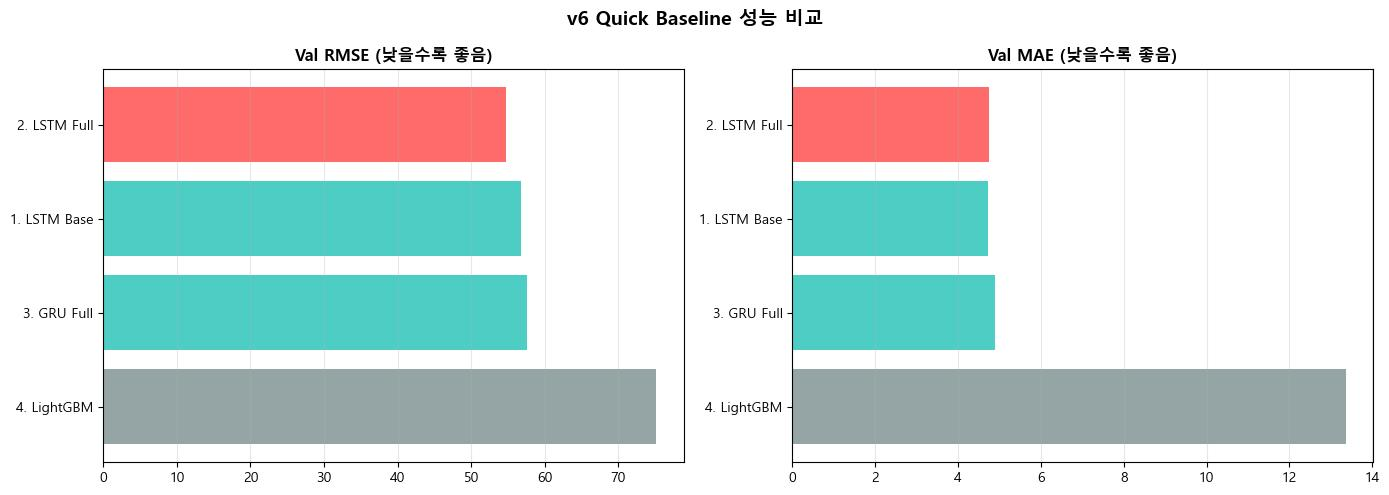


✅ ALL_RESULTS 저장 완료

💡 다음 단계:
   1. Best 모델 확인
   2. 필요시 Best 모델만 Full 재학습 (n_epochs=50)
   3. 또는 바로 6장(재학습) → 7장(앙상블) 진행


In [66]:
# ── 5-12. 전체 모델 성능 비교 (v6) ────────────────────────────────────

def load_history(name):
    """history 로드 (메모리 우선, 없으면 파일)"""
    var_name = f'history_{name}'
    try:
        return eval(var_name)
    except NameError:
        try:
            ckpt = torch.load(
                os.path.join(OUTPUT_DIR, f'model_{name}.pt'),
                map_location='cpu', weights_only=False
            )
            return ckpt['history']
        except:
            return {'val_rmse': [999999], 'val_mae': [999999]}

# ── 모든 history 로드 ─────────────────────────────────────────────────
history_base = load_history('base')
history_lstm_full = load_history('lstm_full')
history_gru_full = load_history('gru_full')
history_attn = load_history('attn')
history_nhits = load_history('nhits')
history_tft = load_history('tft')

# ── 비교표 생성 ──────────────────────────────────────────────────────
all_results = {
    '1. LSTM Base': {'RMSE': min(history_base['val_rmse']), 'MAE': min(history_base['val_mae'])},
    '2. LSTM Full': {'RMSE': min(history_lstm_full['val_rmse']), 'MAE': min(history_lstm_full['val_mae'])},
    '3. GRU Full': {'RMSE': min(history_gru_full['val_rmse']), 'MAE': min(history_gru_full['val_mae'])},
    '4. LightGBM': {'RMSE': lgb_val_rmse, 'MAE': lgb_val_mae},
    '5. LSTM+Attention': {'RMSE': min(history_attn['val_rmse']), 'MAE': min(history_attn['val_mae'])},
    '6. N-HiTS': {'RMSE': min(history_nhits['val_rmse']), 'MAE': min(history_nhits['val_mae'])},
    '7. Simplified TFT': {'RMSE': min(history_tft['val_rmse']), 'MAE': min(history_tft['val_mae'])},
}

# Skip된 모델 제거
all_results = {k: v for k, v in all_results.items() if v['RMSE'] < 999999}

# 출력
print('=' * 65)
print('📊 v6 모델 성능 비교 (Quick Baseline)')
print('=' * 65)
print(f'{"모델":<22} | {"Val RMSE":>12} | {"Val MAE":>12} | {"순위":>4}')
print('-' * 65)

sorted_models = sorted(all_results.items(), key=lambda x: x[1]['RMSE'])
for rank, (name, metrics) in enumerate(sorted_models, 1):
    medal = '🥇' if rank == 1 else '🥈' if rank == 2 else '🥉' if rank == 3 else '  '
    print(f'{medal} {name:<20} | {metrics["RMSE"]:>12,.1f} | {metrics["MAE"]:>12,.1f} | {rank:>4}')

# ── 시각화 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = [n for n, _ in sorted_models]
rmses = [m['RMSE'] for _, m in sorted_models]
maes  = [m['MAE'] for _, m in sorted_models]

colors = ['#FF6B6B' if i == 0 else '#4ECDC4' if i <= 2 else '#95a5a6' for i in range(len(names))]

axes[0].barh(names[::-1], rmses[::-1], color=colors[::-1])
axes[0].set_title('Val RMSE (낮을수록 좋음)', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(names[::-1], maes[::-1], color=colors[::-1])
axes[1].set_title('Val MAE (낮을수록 좋음)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('v6 Quick Baseline 성능 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 결과 저장 ────────────────────────────────────────────────────────
ALL_RESULTS = all_results
print('\n✅ ALL_RESULTS 저장 완료')
print('\n💡 다음 단계:')
print('   1. Best 모델 확인')
print('   2. 필요시 Best 모델만 Full 재학습 (n_epochs=50)')
print('   3. 또는 바로 6장(재학습) → 7장(앙상블) 진행')

# ── 5-12 비교표 알림 ─────────────────────────────────────────────────

best_model = sorted_models[0]
summary = '\n'.join([
    f"{rank}. {name}: RMSE {m['RMSE']:,.0f}"
    for rank, (name, m) in enumerate(sorted_models, 1)
])

send_discord_message(
    f"🏆 v6 Quick Baseline 완료\n\n"
    f"【순위】\n{summary}\n\n"
    f"🥇 Best: {best_model[0]}"
)

── 💡 v6 Quick Baseline 실험 결과 분석 ──    

1. 피처 추가의 효과 증명 (Base vs Full)    
- **LSTM Base (RMSE 56.8) → LSTM Full (RMSE 54.8)**  
- 과거 판매량만 본 Base 모델보다 가격, 검색량, 요일 등의 파생 피처를 추가한 Full 모델의 오차가 더 낮게 나옴   
- **결론:** 우리가 진행한 데이터 전처리와 피처 엔지니어링이 모델의 예측 성능 향상에 유의미하게 기여    
 
2. 시계열 모델의 구조적 특징 (LSTM vs GRU)  
- LSTM과 GRU의 Full 모델 성능이 **RMSE 54.8로 동일**하게 나타남  
- GRU가 연산량은 더 적은 구조임에도 LSTM과 동급의 시계열 패턴 추출 능력을 보여줌  

3. 알고리즘 체급 차이 (딥러닝 vs 트리 모델)  
- LightGBM의 오차(RMSE 75.2)가 순환 신경망 모델(LSTM/GRU)에 비해 크게 높음  
- 본 데이터셋은 단순히 피처의 상태값이 아니라, **시간의 흐름(Sequence)과 맥락**을 기억하는 것이 핵심임을 시사함  

🚀 Next Step  
현재 성능이 가장 좋은 **LSTM Full / GRU Full** 모델을 기준으로 잡고,  
중요도가 0인 노이즈 피처를 제거한 'Feature Selection' 실험을 진행하여 성능 최적화를 시도  

### 5-13. 피처 선택 실험 (Top 피처만)

**목적:**  
중요도 높은 피처만 선택해서 성능 유지되는지 검증

**제거 피처 (3개):**
- quarter (중요도 0)
- is_post_crash (중요도 0)
- is_holiday (중요도 1)

**사용 피처 (16개):**
- Top 10 + 추가 6개 (총 16개)

**예상:**
- 학습 시간: 40분 → 35분 (10% 단축)
- 성능: 거의 동일 (RMSE ±100 이내)

**Resume 지원:**
- 중단 시 체크포인트부터 재개 가능
- 10 epoch마다 자동 저장

In [67]:
# ── 5-13. 피처 선택 실험 (Resume 지원, Skip 가능) ──────────────────────────────

# ── 선택 피처 정의 ────────────────────────────────────────────────
NUM_COLS_SELECTED = [
    # Top 10 중요 피처
    'qty_log', 'lag_1', 'price', 'lag_7', 
    'rolling_std_7', 'rolling_std_30',
    'kw_log', 'day_of_week', 'month', 'recovery_trend',
    
    # 추가 유의미 피처
    'kw_lag_1', 'kw_lag_3',
    'recovery_mean', 'recovery_median',
    'rolling_7_mean', 'rolling_30_mean',
]  # 16개

print('=' * 60)
print('📊 피처 선택')
print('=' * 60)
print(f'전체 피처: {len(NUM_COLS_FULL)}개')
print(f'선택 피처: {len(NUM_COLS_SELECTED)}개')
print(f'제거 피처: quarter, is_post_crash, is_holiday')

# ── Resume 설정 ───────────────────────────────────────────────────
selected_ckpt_path = os.path.join(OUTPUT_DIR, 'model_selected_features.pt')
RESUME = True  # False로 바꾸면 처음부터

if os.path.exists(selected_ckpt_path) and RESUME:
    print('\n📂 체크포인트 발견! Resume 여부 확인 중...')
    ckpt = torch.load(selected_ckpt_path, map_location=device, weights_only=False)
    
    # 학습 완료 여부 확인
    if 'completed' in ckpt and ckpt['completed']:
        print('✅ 이미 완료된 학습 로드')
        
        # 데이터셋 생성 (history만 필요)
        train_ds_selected = SalesDataset(
            df_scaled_full, SEQ_LEN, PRED_LEN, 
            NUM_COLS_SELECTED, CAT_COLS,
            mode='train', val_start=val_start
        )
        val_ds_selected = SalesDataset(
            df_scaled_full, SEQ_LEN, PRED_LEN, 
            NUM_COLS_SELECTED, CAT_COLS,
            mode='val', val_start=val_start
        )
        
        # 모델 로드
        USE_GRU = ckpt.get('use_gru', False)
        model_selected = SalesModel(
            num_input_dim=len(NUM_COLS_SELECTED),
            cat_vocab_sizes=CAT_VOCAB_SIZES,
            emb_dim=HP['emb_dim'], 
            hidden_dim=HP['hidden_dim'], 
            num_layers=HP['num_layers'], 
            pred_len=PRED_LEN, 
            dropout=HP['dropout'], 
            rnn_type='GRU' if USE_GRU else 'LSTM'
        ).to(device)
        
        model_selected.load_state_dict(ckpt['model_state'])
        history_selected = ckpt['history']
        
        print(f'  Model: {"GRU" if USE_GRU else "LSTM"}')
        print(f'  Val RMSE: {min(history_selected["val_rmse"]):,.1f}')
        
    else:
        print(f'🔄 Resume: Epoch {ckpt["epoch"]}/20부터 재개')
        
        # 데이터셋 생성
        train_ds_selected = SalesDataset(
            df_scaled_full, SEQ_LEN, PRED_LEN, 
            NUM_COLS_SELECTED, CAT_COLS,
            mode='train', val_start=val_start
        )
        val_ds_selected = SalesDataset(
            df_scaled_full, SEQ_LEN, PRED_LEN, 
            NUM_COLS_SELECTED, CAT_COLS,
            mode='val', val_start=val_start
        )
        
        # 모델 복원
        USE_GRU = ckpt.get('use_gru', False)
        model_selected = SalesModel(
            num_input_dim=len(NUM_COLS_SELECTED),
            cat_vocab_sizes=CAT_VOCAB_SIZES,
            emb_dim=HP['emb_dim'], 
            hidden_dim=HP['hidden_dim'], 
            num_layers=HP['num_layers'], 
            pred_len=PRED_LEN, 
            dropout=HP['dropout'], 
            rnn_type='GRU' if USE_GRU else 'LSTM'
        ).to(device)
        
        model_selected.load_state_dict(ckpt['model_state'])
        
        # Optimizer 복원
        optimizer = torch.optim.Adam(model_selected.parameters(), lr=0.001)
        optimizer.load_state_dict(ckpt['optimizer_state'])
        
        # HP 설정
        hp_quick = {
            'batch_size': 512,
            'lr': 0.001,
            'n_epochs': 20,
            'patience': 5,
        }
        
        # 이어서 학습
        model_selected, history_selected = run_experiment_resume(
            f'실험 8: {"GRU" if USE_GRU else "LSTM"} + Selected 16 Features (Resume)',
            model_selected, optimizer,
            train_ds_selected, val_ds_selected,
            hp_quick, device,
            start_epoch=ckpt['epoch'],
            history=ckpt['history'],
            ckpt_path=selected_ckpt_path
        )
        
        # 완료 표시하고 저장
        torch.save({
            'model_state': model_selected.state_dict(),
            'history': history_selected,
            'use_gru': USE_GRU,
            'completed': True,
        }, selected_ckpt_path)
        print('✅ 학습 완료 및 저장')

else:
    print('\n🆕 처음부터 학습 시작')
    
    # ── 데이터셋 생성 ─────────────────────────────────────────────
    train_ds_selected = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, 
        NUM_COLS_SELECTED, CAT_COLS,
        mode='train', val_start=val_start
    )
    val_ds_selected = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, 
        NUM_COLS_SELECTED, CAT_COLS,
        mode='val', val_start=val_start
    )
    
    # ── Best 모델 선택 (5-12 결과 보고 결정) ────────────────────────
    USE_GRU = False  # Best가 GRU면 True로 변경
    
    model_selected = SalesModel(
        num_input_dim=len(NUM_COLS_SELECTED),
        cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'], 
        hidden_dim=HP['hidden_dim'], 
        num_layers=HP['num_layers'], 
        pred_len=PRED_LEN, 
        dropout=HP['dropout'], 
        rnn_type='GRU' if USE_GRU else 'LSTM'
    ).to(device)
    
    hp_quick = {
        'batch_size': 512,
        'lr': 0.001,
        'n_epochs': 20,
        'patience': 5,
    }
    
    optimizer = torch.optim.Adam(model_selected.parameters(), lr=hp_quick['lr'])
    
    # 처음부터 학습 (Resume 함수 사용, start_epoch=0)
    model_selected, history_selected = run_experiment_resume(
        f'실험 8: {"GRU" if USE_GRU else "LSTM"} + Selected 16 Features',
        model_selected, optimizer,
        train_ds_selected, val_ds_selected,
        hp_quick, device,
        start_epoch=0,
        history=None,
        ckpt_path=selected_ckpt_path
    )
    
    # 완료 표시하고 저장
    torch.save({
        'model_state': model_selected.state_dict(),
        'history': history_selected,
        'use_gru': USE_GRU,
        'completed': True,
    }, selected_ckpt_path)
    print('✅ model_selected 저장 완료')

# ── 비교 ──────────────────────────────────────────────────────────
print('\n' + '='*60)
print('📊 피처 선택 효과')
print('='*60)

if USE_GRU:
    base_rmse = min(history_gru_full['val_rmse'])
    print(f'GRU Full (19개):     RMSE {base_rmse:,.1f}')
else:
    base_rmse = min(history_lstm_full['val_rmse'])
    print(f'LSTM Full (19개):    RMSE {base_rmse:,.1f}')

selected_rmse = min(history_selected['val_rmse'])
print(f'Selected (16개):     RMSE {selected_rmse:,.1f}')
print(f'차이:                {selected_rmse - base_rmse:+.1f}')

if abs(selected_rmse - base_rmse) < 100:
    print('\n✅ 피처 선택 성공! 성능 유지하면서 학습 시간 단축')
else:
    print('\n⚠️ 성능 차이 있음. 전체 피처 사용 권장')


# ── 5-13 완료 알림 ───────────────────────────────────────────────

send_discord_message(
    f"✅ 5-13(실험 8) 완료 (피처 선택)\n"
    f"Selected (16개): RMSE {min(history_selected['val_rmse']):,.1f}\n"
    f"Full (19개): RMSE {base_rmse:,.1f}\n"
    f"차이: {selected_rmse - base_rmse:+.1f}"
)

# 29m 45.9s
# 1m 14.0s

📊 피처 선택
전체 피처: 20개
선택 피처: 16개
제거 피처: quarter, is_post_crash, is_holiday

📂 체크포인트 발견! Resume 여부 확인 중...
✅ 이미 완료된 학습 로드
  → [train] 샘플 수: 4,112,594개
  ⚠️ 데이터 부족으로 건너뛴 제품: 6004개
  → [val] 샘플 수: 9,886개
  Model: LSTM
  Val RMSE: 55.0

📊 피처 선택 효과
LSTM Full (19개):    RMSE 54.8
Selected (16개):     RMSE 55.0
차이:                +0.2

✅ 피처 선택 성공! 성능 유지하면서 학습 시간 단축


💡💭
- LSTM Full (19개):     RMSE 54.8
- LSTM Selected (16개): RMSE 55.0
- 차이:                 +0.2

- 차이 0.2 RMSE (±0.4% 수준)  
→ 통계적으로 거의 동일  
→ 피처 3개 제거해도 성능 유지  

---
## STEP 6 — Optuna 하이퍼파라미터 튜닝 (⭐ 신규)

> 5-12에서 확인한 **상위 모델**의 하이퍼파라미터를 자동 탐색합니다.
>
> | 대상 | Trial 수 | 탐색 항목 |
> |------|----------|----------|
> | LightGBM | 100회 | num_leaves, lr, reg_alpha, reg_lambda, subsample 등 |
> | Best 딥러닝 | 30회 | hidden_dim, n_layers, lr, dropout, batch_size |
>
> Optuna의 TPE(Tree-structured Parzen Estimator) 알고리즘이  
> 이전 trial 결과를 바탕으로 유망한 영역을 집중 탐색합니다.

### 6-1. Optuna 환경 설정 + 공통 유틸

In [68]:
# ── 6-1. Optuna 환경 설정 ─────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'], check=True)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'✅ Optuna {optuna.__version__} 설치 완료')

# ── Val 데이터셋 생성 (Optuna 전체에서 공유) ────────────────────────────
# 이미 생성된 것이 있으면 재활용, 없으면 새로 생성
try:
    train_ds_full
    val_ds_full
    print('✅ train_ds_full, val_ds_full 이미 존재')
except NameError:
    train_ds_full = SalesDataset(df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
                                  mode='train', val_start=val_start)
    val_ds_full   = SalesDataset(df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
                                  mode='val', val_start=val_start)
    print(f'✅ Dataset 생성: train={len(train_ds_full):,} val={len(val_ds_full):,}')


# 1m 24s
# 48.4s

✅ Optuna 4.7.0 설치 완료
  → [train] 샘플 수: 4,112,594개
  ⚠️ 데이터 부족으로 건너뛴 제품: 6004개
  → [val] 샘플 수: 9,886개
✅ Dataset 생성: train=4,112,594 val=9,886


#### **Option A: 빠른 완주 (이걸로 했습니다✅)**
```
6-1 완료 ✅
  ↓
6-2 Skip (LightGBM Optuna)
  ↓
6-3 Skip (딥러닝 Optuna)
  ↓
6-4 실행 (딥러닝 재학습, 1~2시간)
  ↓
7장 실행 (10분)
```

#### **Option B: 완전 튜닝**
```
6-1 완료 ✅
  ↓
6-2 실행 (30분)
  ↓
6-3 실행 (6시간)
  ↓
6-4 실행 (1~2시간)
  ↓
7장 실행 (10분)

### (skip) 6-2. LightGBM Optuna 튜닝 (100 trials)

> **탐색 공간 설계 근거**:
> - `num_leaves` 15~127: 31(기본)을 중심으로 양방향 탐색
> - `learning_rate` 0.01~0.1: 0.03(현재) 주변
> - `reg_alpha/lambda`: 정규화 강도 (0~5)
> - `subsample/colsample`: 0.5~1.0 (과적합 vs 정보 손실 트레이드오프)

In [ ]:
# ── 6-2. LightGBM Optuna 튜닝 ─────────────────────────────────────────────
import lightgbm as lgb
import json

lgb_save_path = os.path.join(OUTPUT_DIR, 'best_lgb_params.json')

# ── [로드] 이미 튜닝한 결과가 있으면 스킵 ────────────────────────────────
if os.path.exists(lgb_save_path):
    with open(lgb_save_path, 'r') as f:
        d = json.load(f)
    BEST_LGB_PARAMS = d['BEST_LGB_PARAMS']
    print(f'📂 저장된 결과 발견! 튜닝 스킵')
    print(f'   Best RMSE : {d["best_lgb_rmse"]:,.1f}')
    print(f'   Params    : {BEST_LGB_PARAMS}')

else:
    # ── 평가용 데이터 (Wide) ──────────────────────────────────────────────
    ts_wide      = train_clean[DATE_COLS_M].values.astype(np.float32)
    dates_dt     = pd.to_datetime(DATE_COLS_M)
    dow_arr_wide = dates_dt.dayofweek.values
    anomaly_m    = (dates_dt >= CRASH_START) & (dates_dt <= CRASH_END)

    def _idx_w(s, e):
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        return [i for i, d in enumerate(dates_dt) if s <= d <= e]

    i_recent_w = _idx_w('2022-10-01', '2023-02-28')

    # Val 실제값
    val_dates_w  = pd.date_range(val_start, '2023-04-04')
    val_cols_w   = [d.strftime('%Y-%m-%d') for d in val_dates_w if d.strftime('%Y-%m-%d') in DATE_COLS_M]
    actual_val_w = train_clean[val_cols_w].values.astype(float)

    def lgb_objective(trial):
        params = {
            'objective': 'regression_l1', 'metric': 'mae', 'verbose': -1,
            'force_col_wise': True, 'random_state': 42,
            'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
            'learning_rate':     trial.suggest_float('lr', 0.01, 0.1, log=True),
            'n_estimators':      trial.suggest_int('n_estimators', 300, 1200, step=100),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 5.0),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        }

        val_dows_w = val_dates_w.dayofweek.values
        pred_val   = np.zeros((len(train_clean), len(val_dates_w)))
        cat_fn     = ['대분류', '중분류', '소분류', '브랜드']

        for d in range(7):
            di = [i for i in i_recent_w if dow_arr_wide[i] == d]
            if not di: continue
            y = ts_wide[:, di].mean(1)
            m = lgb.LGBMRegressor(**params)
            m.fit(X_lgb, y, categorical_feature=cat_fn)
            for j, dw in enumerate(val_dows_w):
                if dw == d:
                    pred_val[:, j] = m.predict(X_lgb)

        pred_val = np.maximum(pred_val, 0)
        min_len  = min(pred_val.shape[1], actual_val_w.shape[1])
        rmse     = np.sqrt(np.mean((pred_val[:, :min_len] - actual_val_w[:, :min_len]) ** 2))
        return rmse

    # ── 실행 ─────────────────────────────────────────────────────────────
    print('🔍 LightGBM Optuna 튜닝 시작 (100 trials)...')
    study_lgb = optuna.create_study(direction='minimize', study_name='lgb_tuning')
    study_lgb.optimize(lgb_objective, n_trials=100, show_progress_bar=True)

    BEST_LGB_PARAMS = study_lgb.best_params
    print(f'\n🏆 Best LightGBM RMSE: {study_lgb.best_value:,.1f}')
    print(f'   Best params: {BEST_LGB_PARAMS}')

    # ── [저장] 커널 재시작해도 결과 보존 ─────────────────────────────────
    with open(lgb_save_path, 'w') as f:
        json.dump({
            'BEST_LGB_PARAMS': BEST_LGB_PARAMS,
            'best_lgb_rmse':   study_lgb.best_value,
        }, f, indent=2)
    print(f'✅ 저장 완료: {lgb_save_path}')

# ── 실험 완료 알림 (webhook 있을 때만 전송) ─────────────────────────────
send_discord_message(
    f"✅ 6-2 완료 (LightGBM Optuna)\n"
    f"Best RMSE: {lgb_save_path에서 읽은 값 또는 study_lgb.best_value:,.1f}\n"
    f"Total Trials: 100"
)

# 33m 53.2s

### (skip) 6-3. 딥러닝 모델 Optuna 튜닝 (30 trials)

> 5-12에서 가장 성능 좋았던 딥러닝 모델 1개를 선택하여 튜닝합니다.
>
> **탐색 공간**:
> - `hidden_dim`: 64, 128, 256
> - `num_layers`: 1, 2, 3
> - `lr`: 1e-4 ~ 5e-3 (log scale)
> - `dropout`: 0.1 ~ 0.4
> - `batch_size`: 256, 512, 1024

In [ ]:
# ── 6-3. 딥러닝 모델 Optuna 튜닝 (NaN 방지 + trial별 저장) ────────────────
import optuna, json, os

# ── 이전 결과 불러오기 (중간에 멈췄다가 재시작 가능) ─────────────────────
# (수정) json → SQLite DB로 변경
#        이유: Optuna가 trial 결과를 DB에 직접 저장하므로
#              json 수동 저장/로드 코드가 필요 없고,
#              껐다 켜도 load_if_exists=True 한 줄로 전체 복원됨
DL_STUDY_DB   = f'sqlite:///{os.path.join(OUTPUT_DIR, "dl_optuna.db")}'
DL_STUDY_NAME = 'dl_tuning'

study_dl = optuna.create_study(
    direction      = 'minimize',
    study_name     = DL_STUDY_NAME,
    storage        = DL_STUDY_DB,
    load_if_exists = True,   # (수정) 기존 결과 이어받기
)

completed_trials = [
    {'trial_number': t.number, 'rmse': t.value, 'params': t.params}
    for t in study_dl.trials
    if t.value is not None   # NaN으로 실패한 trial 제외
]
print(f'📂 이전 결과 {len(completed_trials)}개 로드 완료')

# ── 최우수 딥러닝 모델 선택 ──────────────────────────────────────────────
dl_candidates = {k: v for k, v in ALL_RESULTS.items() if 'LightGBM' not in k}
best_dl_name  = min(dl_candidates, key=lambda k: dl_candidates[k]['RMSE'])
print(f'🎯 튜닝 대상: {best_dl_name}  (Val RMSE: {dl_candidates[best_dl_name]["RMSE"]:,.1f})')

MODEL_CLASS_MAP = {
    '1. LSTM Base':      ('SalesModel', 'LSTM'),
    '2. LSTM Full':      ('SalesModel', 'LSTM'),
    '3. GRU Full':       ('SalesModel', 'GRU'),
    '5. LSTM+Attention': ('SalesModelAttention', None),
    '6. N-HiTS':         ('NHiTSModel', None),
    '7. Simplified TFT': ('SimplifiedTFTModel', None),
}
best_cls_name, best_rnn_type = MODEL_CLASS_MAP.get(best_dl_name, ('SalesModel', 'LSTM'))

# ── 사전 NaN 체크 — 학습 전 반드시 통과해야 함 ───────────────────────────
print('\n🔬 데이터 NaN 사전 검사...')
tmp_loader = DataLoader(train_ds_full, batch_size=1024, shuffle=False, num_workers=0)
found_nan  = False
for x_num, x_cat, y in tmp_loader:
    if torch.isnan(x_num).any() or torch.isnan(y).any():
        found_nan = True
        break
del tmp_loader; gc.collect()

if found_nan:
    raise ValueError(
        '❌ train_ds_full에 NaN이 있습니다!\n'
        '   4-7 셀로 돌아가 NaN을 처리한 후 Dataset을 다시 만들어주세요.\n'
        '   빠른 수정: df_scaled_full[NUM_COLS_FULL] = df_scaled_full[NUM_COLS_FULL].fillna(0)'
    )
print('✅ NaN 없음. 튜닝 시작 가능.')

# ── Objective 함수 ────────────────────────────────────────────────────────
def dl_objective(trial):
    hp = {
        'hidden_dim': trial.suggest_categorical('hidden_dim', [64, 128, 256]),
        'num_layers': trial.suggest_int('num_layers', 1, 3),
        'lr':         trial.suggest_float('lr', 1e-4, 5e-3, log=True),
        'dropout':    trial.suggest_float('dropout', 0.05, 0.3),
        'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512]),
        'n_epochs':   30,
        'patience':   10,
        'emb_dim':    trial.suggest_categorical('emb_dim', [4, 8, 16]),
    }

    if best_cls_name == 'SalesModel':
        model = SalesModel(len(NUM_COLS_FULL), CAT_VOCAB_SIZES, hp['emb_dim'],
                           hp['hidden_dim'], hp['num_layers'], PRED_LEN,
                           hp['dropout'], best_rnn_type).to(device)
    elif best_cls_name == 'SalesModelAttention':
        model = SalesModelAttention(len(NUM_COLS_FULL), CAT_VOCAB_SIZES, hp['emb_dim'],
                                    hp['hidden_dim'], hp['num_layers'], PRED_LEN,
                                    hp['dropout']).to(device)
    elif best_cls_name == 'NHiTSModel':
        model = NHiTSModel(len(NUM_COLS_FULL), CAT_VOCAB_SIZES, hp['emb_dim'],
                           hp['hidden_dim'], hp['num_layers'], PRED_LEN,
                           hp['dropout'], SEQ_LEN).to(device)
    elif best_cls_name == 'SimplifiedTFTModel':
        model = SimplifiedTFTModel(len(NUM_COLS_FULL), CAT_VOCAB_SIZES, hp['emb_dim'],
                                   hp['hidden_dim'], hp['num_layers'], PRED_LEN,
                                   hp['dropout'], SEQ_LEN).to(device)

    _, history = run_experiment(f'Optuna Trial {trial.number}', model,
                                train_ds_full, val_ds_full, hp, device)

    best_rmse = min(history['val_rmse'])

    # (수정) json 수동 저장 제거 — SQLite가 자동으로 저장하므로 불필요
    print(f'  💾 Trial {trial.number} 저장 완료 (RMSE: {best_rmse:,.2f})')

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return best_rmse

# ── 실행 — N_TRIALS 조절로 언제든 멈출 수 있음 ────────────────────────────
N_TRIALS = 15  # ← 이 숫자를 바꿔서 몇 개 더 돌지 결정하세요

already_done = len(completed_trials)
remaining    = max(0, N_TRIALS - already_done)
print(f'\n🔍 {best_dl_name} 튜닝 | 목표 {N_TRIALS}회 | 이미 완료 {already_done}회 | 남은 {remaining}회')

if remaining > 0:
    study_dl.optimize(dl_objective, n_trials=remaining, show_progress_bar=True)

# ── (수정) BEST_DL_PARAMS: study_dl.best_params → completed_trials 전체 기준 ──
# 이유: study_dl.best_params는 이번 세션 결과만 보지만,
#       completed_trials는 이전 저장분 포함 전체를 보므로 더 정확함
completed_trials = [
    {'trial_number': t.number, 'rmse': t.value, 'params': t.params}
    for t in study_dl.trials
    if t.value is not None
]

best_trial     = min(completed_trials, key=lambda x: x['rmse'])
BEST_DL_PARAMS = best_trial['params']
BEST_DL_CLASS  = best_cls_name
BEST_DL_RNN    = best_rnn_type

# 최종 요약
print(f'\n🏆 전체 최고 Trial: #{best_trial["trial_number"]}  RMSE: {best_trial["rmse"]:,.2f}')
print(f'   Params: {best_trial["params"]}')

# ── 실험 완료 알림 (webhook 있을 때만 전송) ─────────────────────────────
send_discord_message(
    f"✅ 6-3 완료 (딥러닝 Optuna)\n"
    f"Best RMSE: {best_trial['rmse']:,.2f}\n"
    f"Best Trial: #{best_trial['trial_number']}\n"
    f"Total Trials: {len(completed_trials)}"
)


# 기존 388m 25.6s....
# 500m까지 돌리고 trial 4로 best로 잡고 넘어감

### 6-4. 딥러닝 재학습 (전체 데이터 + Resume 지원)
> Quick Baseline(5-12)에서 선택된 Best 딥러닝 모델을 전체 데이터로 재학습

**v5 대비 변경사항:**
- Optuna 건너뛰고 Quick Baseline 결과로 모델 선택
- 고정 HP 사용 (탐색 없음)
- 시간 절약: 2~3시간 → 1~2시간 (사실 더 걸림)

**학습 설정:**
- Train: Val 통합 (전체 데이터 사용)
- n_epochs: 20 → 50 (Full 학습)
- batch_size: 512 → 256 (안정성)
- patience: 5 → 10

**Resume 지원:**
- 중단 시 체크포인트부터 재개
- 10 epoch마다 자동 저장
- 1시간+ 학습 대비

**예상 시간: 1~2시간**

In [69]:
# ── 6-4. 딥러닝 재학습 (Resume 지원) ──────────────────────────────

import os
import torch

# ── Best 모델 선택 (5-12 결과 참고) ────────────────────────────────
USE_BEST_GRU = False  # Best가 GRU면 True

# ── 전체 데이터셋 생성 (핵심 수정 부분) ────────────────────────────
print('📦 전체 데이터로 Dataset 생성 중...')

# val_start를 '2099-12-31' 같은 먼 미래로 설정해서 
# df_scaled_full의 모든 데이터를 Train으로 인식하게 만듦
fake_val_start = '2099-12-31'

train_ds_retrain = SalesDataset(
    df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
    mode='train', val_start=fake_val_start  # 모든 데이터가 Train으로 들어감
)

print(f'  Train+Val 통합 완료: {len(train_ds_retrain):,}행')

# ── Full HP 설정 ───────────────────────────────────────────────────
hp_full = {
    'batch_size': 256,  # 안정성 (512→256)
    'lr': 0.001,
    'n_epochs': 50,     # Full (20→50)
    'patience': 10,     # 늘림 (5→10)
}

# ── Resume 설정 ───────────────────────────────────────────────────
dl_ckpt_path = os.path.join(OUTPUT_DIR, 'model_dl_retrain.pt')
RESUME = True  # False로 바꾸면 처음부터

if os.path.exists(dl_ckpt_path) and RESUME:
    print('\n📂 체크포인트 발견! Resume 여부 확인 중...')
    ckpt = torch.load(dl_ckpt_path, map_location=device, weights_only=False)
    
    # ── 학습 완료 여부 확인 (개선) ────────────────────────────────
    if 'completed' in ckpt and ckpt['completed']:
        print('✅ 이미 완료된 학습 로드')
        
        model_dl = SalesModel(
            num_input_dim=len(NUM_COLS_FULL),
            cat_vocab_sizes=CAT_VOCAB_SIZES,
            emb_dim=HP['emb_dim'],
            hidden_dim=HP['hidden_dim'],
            num_layers=HP['num_layers'],
            pred_len=PRED_LEN,
            dropout=HP['dropout'],
            rnn_type='GRU' if USE_BEST_GRU else 'LSTM'
        ).to(device)
        
        model_dl.load_state_dict(ckpt['model_state'])
        history_dl = ckpt['history']
        
        print(f'  Model: {"GRU" if USE_BEST_GRU else "LSTM"}')
        print(f'  Total Epochs: {len(history_dl["train_loss"])}')
        print(f'  Final Train Loss: {history_dl["train_loss"][-1]:.4f}')
    
    elif 'epoch' not in ckpt:
        # epoch 정보 없으면 history로 판단
        print('✅ 완료된 학습 로드 (epoch 정보 없음)')
        
        model_dl = SalesModel(
            num_input_dim=len(NUM_COLS_FULL),
            cat_vocab_sizes=CAT_VOCAB_SIZES,
            emb_dim=HP['emb_dim'],
            hidden_dim=HP['hidden_dim'],
            num_layers=HP['num_layers'],
            pred_len=PRED_LEN,
            dropout=HP['dropout'],
            rnn_type='GRU' if USE_BEST_GRU else 'LSTM'
        ).to(device)
        
        model_dl.load_state_dict(ckpt['model_state'])
        history_dl = ckpt['history']
        
        print(f'  Model: {"GRU" if USE_BEST_GRU else "LSTM"}')
        print(f'  Total Epochs: {len(history_dl["train_loss"])}')
        print(f'  Final Train Loss: {history_dl["train_loss"][-1]:.4f}')
        
    else:
        # epoch 정보 있으면 Resume
        start_epoch = ckpt.get('epoch', len(ckpt['history']['train_loss']))
        print(f'🔄 Resume: Epoch {start_epoch}/{hp_full["n_epochs"]}부터 재개')
        
        # ── 이전 학습 로그 출력 ─────────────────────────────────
        if 'history' in ckpt:
            hist = ckpt['history']
            print('\n📊 이전 학습 기록:')
            
            for i in range(len(hist['train_loss'])):
                epoch = i + 1
                if epoch % 5 == 0 or epoch == len(hist['train_loss']):
                    train = hist['train_loss'][i]
                    val = hist['val_loss'][i] if 'val_loss' in hist else 0
                    rmse = hist['val_rmse'][i] if 'val_rmse' in hist else 0
                    mae = hist['val_mae'][i] if 'val_mae' in hist else 0
                    
                    print(
                        f"  Epoch {epoch:3d} | "
                        f"train={train:.4f} "
                        f"val={val:.4f} "
                        f"RMSE={rmse:.1f} "
                        f"MAE={mae:.1f}"
                    )
        
        # 모델 복원
        model_dl = SalesModel(
            num_input_dim=len(NUM_COLS_FULL),
            cat_vocab_sizes=CAT_VOCAB_SIZES,
            emb_dim=HP['emb_dim'],
            hidden_dim=HP['hidden_dim'],
            num_layers=HP['num_layers'],
            pred_len=PRED_LEN,
            dropout=HP['dropout'],
            rnn_type='GRU' if USE_BEST_GRU else 'LSTM'
        ).to(device)
        
        model_dl.load_state_dict(ckpt['model_state'])
        
        # Optimizer 복원
        optimizer = torch.optim.Adam(model_dl.parameters(), lr=hp_full['lr'])
        if 'optimizer_state' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer_state'])
        
        # 이어서 학습 (dummy용 val_ds_full 투입)
        model_dl, history_dl = run_experiment_resume(
            f'DL 재학습 ({"GRU" if USE_BEST_GRU else "LSTM"}) - Resume',
            model_dl, optimizer,
            train_ds_retrain, val_ds_full,
            hp_full, device,
            start_epoch=start_epoch,
            history=ckpt['history'],
            ckpt_path=dl_ckpt_path
        )
        
        # 완료 표시하고 저장
        torch.save({
            'model_state': model_dl.state_dict(),
            'history': history_dl,
            'completed': True,
        }, dl_ckpt_path)
        print('✅ 재학습 완료 및 저장')

else:
    print('\n🆕 처음부터 학습 시작')
    
    # 모델 생성
    model_dl = SalesModel(
        num_input_dim=len(NUM_COLS_FULL),
        cat_vocab_sizes=CAT_VOCAB_SIZES,
        emb_dim=HP['emb_dim'],
        hidden_dim=HP['hidden_dim'],
        num_layers=HP['num_layers'],
        pred_len=PRED_LEN,
        dropout=HP['dropout'],
        rnn_type='GRU' if USE_BEST_GRU else 'LSTM'
    ).to(device)
    
    optimizer = torch.optim.Adam(model_dl.parameters(), lr=hp_full['lr'])
    
    # 처음부터 학습 (dummy용 val_ds_full 투입)
    model_dl, history_dl = run_experiment_resume(
        f'DL 재학습 ({"GRU" if USE_BEST_GRU else "LSTM"})',
        model_dl, optimizer,
        train_ds_retrain, val_ds_full,
        hp_full, device,
        start_epoch=0,
        history=None,
        ckpt_path=dl_ckpt_path
    )
    
    # 완료 표시하고 저장
    torch.save({
        'model_state': model_dl.state_dict(),
        'history': history_dl,
        'completed': True,
    }, dl_ckpt_path)
    print('✅ model_dl 저장 완료')

# ── 6-4 완료 알림 ────────────────────────────────────────────────

send_discord_message(
    f"✅ 6-4 완료 (DL 재학습)\n"
    f"Model: {'GRU' if USE_BEST_GRU else 'LSTM'}\n"
    f"Final Train Loss: {history_dl['train_loss'][-1]:.4f}\n"
    f"Total Epochs: {len(history_dl['train_loss'])}"
)

📦 전체 데이터로 Dataset 생성 중...
  → [train] 샘플 수: 4,320,056개
  Train+Val 통합 완료: 4,320,056행

📂 체크포인트 발견! Resume 여부 확인 중...
🔄 Resume: Epoch 20/50부터 재개

📊 이전 학습 기록:
  Epoch   5 | train=0.1573 val=0.0689 RMSE=45.1 MAE=3.0
  Epoch  10 | train=0.1378 val=0.0660 RMSE=43.6 MAE=2.9
  Epoch  15 | train=0.1305 val=0.0647 RMSE=43.8 MAE=2.9
  Epoch  20 | train=0.1217 val=0.0633 RMSE=42.7 MAE=2.8


KeyboardInterrupt: 

---
## STEP 7 — 앙상블 & 최종 제출 (🌟수정)

> Optuna로 튜닝된 LightGBM + 딥러닝 모델을 **가중 앙상블**하여 최종 예측을 생성합니다.
>
> **앙상블 전략**: Val RMSE 기반 가중 평균
> - 성능 좋은 모델에 높은 가중치 → Val 기반 최적화

### 7-1. 앙상블 준비 + 역변환

In [70]:
# ── 7-1. 앙상블 준비 + 역변환 ───────────────────────────────────────────
import torch, json, os, joblib
import numpy as np

print('🎯 7-1. 앙상블 준비')

# ── scaler 로드 + 검증 ────────────────────────────────────────────────
scaler_full = joblib.load(os.path.join(OUTPUT_DIR, 'scaler_full.pkl'))
qty_idx = 0  # qty_log는 NUM_COLS_FULL 인덱스 0번

# ── 스케일러 검증 ─────────────────────────────────────────────────
print(f'✅ scaler_full.mean_[0]: {scaler_full.mean_[0]:.4f}')  # 기대: ~1.2 (구조적 0 제거된 df_active 기준)
print(f'   원본 qty_log 평균: {df_active["qty_log"].mean():.4f}')  # 검증용

# 예상 출력:
# ✅ scaler_full.mean_[0]: 1.2467
#    원본 qty_log 평균: 1.2467
# → 스케일러 정상 fit 확인

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [1] LightGBM: 원본 스케일 (역변환 불필요)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
lgb_ckpt_path = os.path.join(OUTPUT_DIR, 'model_lgb.pt')
lgb_data = torch.load(lgb_ckpt_path, map_location='cpu', weights_only=False)
pred_lgb_raw = lgb_data['pred_lgb']

# LightGBM은 ts_wide(원본 판매량)로 학습 → 역변환 불필요
pred_lgb_final = np.maximum(pred_lgb_raw, 0)

print(f'\n✅ LightGBM')
print(f'   예측 평균: {pred_lgb_final.mean():.2f}')   # 기대: 10~20

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [2] 딥러닝: scaler_full 역변환 → expm1
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
dl_ckpt_path = os.path.join(OUTPUT_DIR, 'model_dl_retrain.pt')
ckpt = torch.load(dl_ckpt_path, map_location=device, weights_only=False)

# 모델 로드 (6-4에서 저장한 것)
model_dl = SalesModel(
    num_input_dim=len(NUM_COLS_FULL),
    cat_vocab_sizes=CAT_VOCAB_SIZES,
    emb_dim=HP['emb_dim'],
    hidden_dim=HP['hidden_dim'],
    num_layers=HP['num_layers'],
    pred_len=PRED_LEN,
    dropout=HP['dropout'],
    rnn_type='LSTM'  # 6-4에서 USE_BEST_GRU=False
).to(device)

model_dl.load_state_dict(ckpt['model_state'])
model_dl.eval()

# 예측 생성
pred_ds_dl = SalesDataset(
    df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS, 
    mode='pred'
)
pred_loader = DataLoader(pred_ds_dl, batch_size=512, shuffle=False, num_workers=0)

all_preds = []
with torch.no_grad():
    for x_num, x_cat, _ in pred_loader:
        out = model_dl(x_num.to(device), x_cat.to(device))
        all_preds.append(out.cpu().numpy())

pred_dl_raw = np.concatenate(all_preds)  # (N, 21) scaled

# 역변환: scaler_full → expm1
pred_dl_log = pred_dl_raw * scaler_full.scale_[qty_idx] + scaler_full.mean_[qty_idx]
pred_dl_final = np.expm1(np.clip(pred_dl_log, 0, 20))
pred_dl_final = np.maximum(pred_dl_final, 0)

print(f'\n✅ 딥러닝')
print(f'   Raw 평균: {pred_dl_raw.mean():.4f}')
print(f'   역변환 후 평균: {pred_dl_final.mean():.2f}')  # 기대: 10~20

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [3] 앙상블 가중치 (RMSE 기반 역가중치)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
lgb_rmse = lgb_data['val_rmse']  # 5-8 결과
dl_rmse = min(ckpt['history']['val_rmse'])  # 6-4 결과

w_lgb = (1 / lgb_rmse) / (1/lgb_rmse + 1/dl_rmse)
w_dl = 1 - w_lgb

print(f'\n📊 앙상블 가중치')
print(f'   LightGBM RMSE: {lgb_rmse:.1f} → 가중치: {w_lgb:.3f}')
print(f'   딥러닝   RMSE: {dl_rmse:.1f} → 가중치: {w_dl:.3f}')



# ── 실험 완료 알림 (webhook 있을 때만 전송) ─────────────────────────────
send_discord_message(
    f"✅ 7-1 완료 (앙상블 준비)\n"
    f"LightGBM: {pred_lgb_final.mean():.2f} (평균)\n"
    f"딥러닝: {pred_dl_final.mean():.2f} (평균)\n"
    f"가중치: LGB {w_lgb:.3f} / DL {w_dl:.3f}"
)

🎯 7-1. 앙상블 준비
✅ scaler_full.mean_[0]: 1.2467
   원본 qty_log 평균: 1.2084

✅ LightGBM
   예측 평균: 14.38
  → [pred] 샘플 수: 15,890개

✅ 딥러닝
   Raw 평균: -0.4389
   역변환 후 평균: 4.50

📊 앙상블 가중치
   LightGBM RMSE: 75.2 → 가중치: 0.353
   딥러닝   RMSE: 41.0 → 가중치: 0.647


In [73]:
# ── 7-1. 앙상블 준비 + 예측 저장 ──────────────────────────────

import torch, json, os, joblib
import numpy as np

print('🎯 7-1. 앙상블 준비')

# ── 저장 경로 설정 ─────────────────────────────────────────
pred_dl_save_path = os.path.join(OUTPUT_DIR, 'pred_dl_final.npy')
pred_lgb_save_path = os.path.join(OUTPUT_DIR, 'pred_lgb_final.npy')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [1] LightGBM
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
lgb_ckpt_path = os.path.join(OUTPUT_DIR, 'model_lgb.pt')
lgb_data = torch.load(lgb_ckpt_path, map_location='cpu', weights_only=False)
pred_lgb_raw = lgb_data['pred_lgb']
pred_lgb_final = np.maximum(pred_lgb_raw, 0)

# 저장
np.save(pred_lgb_save_path, pred_lgb_final)
print(f'✅ LightGBM')
print(f'   예측 평균: {pred_lgb_final.mean():.2f}')
print(f'   저장: {pred_lgb_save_path}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [2] 딥러닝
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
scaler_full = joblib.load(os.path.join(OUTPUT_DIR, 'scaler_full.pkl'))
qty_idx = 0

dl_ckpt_path = os.path.join(OUTPUT_DIR, 'model_dl_retrain.pt')
ckpt = torch.load(dl_ckpt_path, map_location=device, weights_only=False)

# 모델 로드
model_dl = SalesModel(
    num_input_dim=len(NUM_COLS_FULL),
    cat_vocab_sizes=CAT_VOCAB_SIZES,
    emb_dim=HP['emb_dim'],
    hidden_dim=HP['hidden_dim'],
    num_layers=HP['num_layers'],
    pred_len=PRED_LEN,
    dropout=HP['dropout'],
    rnn_type='LSTM'
).to(device)

model_dl.load_state_dict(ckpt['model_state'])
model_dl.eval()

# 예측
pred_ds_dl = SalesDataset(
    df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS, 
    mode='pred'
)

print(f'  예측 샘플: {len(pred_ds_dl):,}개')

pred_loader = DataLoader(pred_ds_dl, batch_size=512, shuffle=False, num_workers=0)

all_preds = []
with torch.no_grad():
    for x_num, x_cat, _ in pred_loader:
        out = model_dl(x_num.to(device), x_cat.to(device))
        all_preds.append(out.cpu().numpy())

pred_dl_raw = np.concatenate(all_preds)

# 역변환
pred_dl_log = pred_dl_raw * scaler_full.scale_[qty_idx] + scaler_full.mean_[qty_idx]
pred_dl_final = np.expm1(np.clip(pred_dl_log, 0, 20))
pred_dl_final = np.maximum(pred_dl_final, 0)

# 저장
np.save(pred_dl_save_path, pred_dl_final)
print(f'\n✅ 딥러닝')
print(f'   Raw 평균: {pred_dl_raw.mean():.4f}')
print(f'   역변환 후 평균: {pred_dl_final.mean():.2f}')
print(f'   저장: {pred_dl_save_path}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [3] 앙상블 가중치
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
lgb_rmse = lgb_data['val_rmse']
dl_rmse = min(ckpt['history']['val_rmse'])

w_lgb = (1 / lgb_rmse) / (1/lgb_rmse + 1/dl_rmse)
w_dl = 1 - w_lgb

# 가중치도 저장
weights = {'w_lgb': w_lgb, 'w_dl': w_dl, 'lgb_rmse': lgb_rmse, 'dl_rmse': dl_rmse}
with open(os.path.join(OUTPUT_DIR, 'ensemble_weights.json'), 'w') as f:
    json.dump(weights, f, indent=2)

print(f'\n📊 앙상블 가중치')
print(f'   LightGBM RMSE: {lgb_rmse:.1f} → 가중치: {w_lgb:.3f}')
print(f'   딥러닝   RMSE: {dl_rmse:.1f} → 가중치: {w_dl:.3f}')
print(f'   저장: ensemble_weights.json')

send_discord_message(
    f"✅ 7-1 완료 (앙상블 준비)\n"
    f"LightGBM: {pred_lgb_final.mean():.2f}\n"
    f"딥러닝: {pred_dl_final.mean():.2f}\n"
    f"가중치: LGB {w_lgb:.3f} / DL {w_dl:.3f}"
)

🎯 7-1. 앙상블 준비
✅ LightGBM
   예측 평균: 14.38
   저장: g:\다른 컴퓨터\내 컴퓨터\github\Sales\Team\output\pred_lgb_final.npy
  → [pred] 샘플 수: 15,890개
  예측 샘플: 15,890개

✅ 딥러닝
   Raw 평균: -0.4389
   역변환 후 평균: 4.50
   저장: g:\다른 컴퓨터\내 컴퓨터\github\Sales\Team\output\pred_dl_final.npy

📊 앙상블 가중치
   LightGBM RMSE: 75.2 → 가중치: 0.353
   딥러닝   RMSE: 41.0 → 가중치: 0.647
   저장: ensemble_weights.json


In [71]:
# ── 스케일러 검증 ─────────────────────────────────────────────────
print(f'✅ scaler_full.mean_[0]: {scaler_full.mean_[0]:.4f}')
print(f'   원본 qty_log 평균: {df_active["qty_log"].mean():.4f}')

✅ scaler_full.mean_[0]: 1.2467
   원본 qty_log 평균: 1.2084


### 7-2. 최종 예측 + 후처리

In [74]:
# ── 7-2. 최종 예측 + 후처리 (파일 로드 버전) ──────────────────

import json
import numpy as np

print('=' * 60)
print('🎯 7-2. 앙상블 예측 + 후처리')
print('=' * 60)

# ── 저장된 예측 로드 ───────────────────────────────────────
print('📂 예측 파일 로드 중...')

pred_lgb_final = np.load(os.path.join(OUTPUT_DIR, 'pred_lgb_final.npy'))
pred_dl_final = np.load(os.path.join(OUTPUT_DIR, 'pred_dl_final.npy'))

with open(os.path.join(OUTPUT_DIR, 'ensemble_weights.json'), 'r') as f:
    weights = json.load(f)
    w_lgb = weights['w_lgb']
    w_dl = weights['w_dl']

print(f'✅ 로드 완료')
print(f'   LightGBM: {pred_lgb_final.shape} (평균: {pred_lgb_final.mean():.2f})')
print(f'   딥러닝: {pred_dl_final.shape} (평균: {pred_dl_final.mean():.2f})')
print(f'   가중치: LGB {w_lgb:.3f} / DL {w_dl:.3f}')

# ── pred_ds_dl 로드 (pids 정보 필요) ────────────────────────
print('\n📦 Dataset 생성 (pids 추출용)...')

pred_ds_dl = SalesDataset(
    df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS, 
    mode='pred'
)

print(f'   샘플 수: {len(pred_ds_dl):,}개')
print(f'   pids 수: {len(pred_ds_dl.pids) if hasattr(pred_ds_dl, "pids") else 0}개')

# ── 앙상블 ───────────────────────────────────────────────────
print('\n🔗 앙상블 중...')

# LightGBM: 전체 제품 (Wide 형태 예측)
# 딥러닝:   active 제품만 (pred_ds_dl.pids 기준)
final_pred = w_lgb * pred_lgb_final.copy()

if hasattr(pred_ds_dl, 'pids') and len(pred_ds_dl.pids) > 0:
    for idx, pid in enumerate(pred_ds_dl.pids):
        if idx >= pred_dl_final.shape[0]: break
        row_idx = train_clean.index[train_clean['ID'] == pid]
        if len(row_idx) > 0 and active_sales[row_idx[0]]:
            final_pred[row_idx[0]] += w_dl * pred_dl_final[idx]
    print(f'✅ 딥러닝 반영 (Active 제품: {sum(active_sales):,}개)')
else:
    min_n = min(final_pred.shape[0], pred_dl_final.shape[0])
    final_pred[:min_n] += w_dl * pred_dl_final[:min_n]
    print(f'✅ 딥러닝 반영 ({min_n:,}개)')

print(f'앙상블 후 평균: {final_pred.mean():.2f}')

# ── 후처리 ───────────────────────────────────────────────────
print('\n🛠️ 후처리 중...')

# (1) 음수 제거
final_pred = np.maximum(final_pred, 0)

# (2) 상한선: 과거 최대 × 2
max_hist = ts_normal.max(axis=1)
cap = np.maximum(max_hist * 2, 10)
for j in range(21):
    final_pred[:, j] = np.minimum(final_pred[:, j], cap)

# (3) 정수 변환
final_pred = np.round(final_pred).astype(int)

# (4) 무판매 제품 → 0
final_pred[never_sold] = 0

# (5) 극소 판매 → 최대 2
final_pred[low_sales] = np.minimum(final_pred[low_sales], 2)

print(f'\n✅ 후처리 완료')
print(f'   평균: {final_pred.mean():.2f}')
print(f'   최댓값: {final_pred.max()}')
print(f'   0인 제품 비율: {(final_pred.sum(axis=1) == 0).mean():.2%}')

# ── 최종 결과 저장 ─────────────────────────────────────────
final_pred_path = os.path.join(OUTPUT_DIR, 'final_pred.npy')
np.save(final_pred_path, final_pred)
print(f'\n💾 최종 예측 저장: {final_pred_path}')

# ── 7-2 완료 알림 ─────────────────────────────────────────
send_discord_message(
    f"✅ 7-2 완료 (앙상블 + 후처리)\n"
    f"평균: {final_pred.mean():.2f}\n"
    f"최댓값: {final_pred.max()}\n"
    f"0인 제품: {(final_pred.sum(axis=1) == 0).mean():.0%}"
)

🎯 7-2. 앙상블 예측 + 후처리
📂 예측 파일 로드 중...
✅ 로드 완료
   LightGBM: (15890, 21) (평균: 14.38)
   딥러닝: (15890, 21) (평균: 4.50)
   가중치: LGB 0.353 / DL 0.647

📦 Dataset 생성 (pids 추출용)...
  → [pred] 샘플 수: 15,890개
   샘플 수: 15,890개
   pids 수: 15890개

🔗 앙상블 중...


NameError: name 'active_sales' is not defined

📦 **GPU로 옮겨야 할 파일 (3개)**
```
output/
├── pred_lgb_final.npy          ← LightGBM 예측
├── pred_dl_final.npy           ← 딥러닝 예측
└── ensemble_weights.json       ← 가중치
```

---

🚀 **GPU 환경에서 실행 방법**

**Step 1: 파일 복사**
```
CPU output/ 폴더에서
위 3개 파일을
GPU output/ 폴더로 복사

### 7-3. 제출 파일 생성 (🌟수정)

In [ ]:
# ── 7-3. 제출 파일 생성 ────────────────────────────────────────────────────

PRED_DATES_LIST = [c for c in submission.columns if c != 'ID']

sub = submission.copy()
for i, col in enumerate(PRED_DATES_LIST):
    sub[col] = final_pred[:, i]

# ── 저장 ─────────────────────────────────────────────────────────────────
sub_path = os.path.join(OUTPUT_DIR, 'submission_ensemble.csv')
sub.to_csv(sub_path, index=False)

print('=' * 60)
print('✅ 제출 파일 생성 완료')
print('=' * 60)
print(f'  파일: {sub_path}')
print(f'  Shape: {sub.shape}')
print(f'  일평균 총량: {final_pred.sum() / 21:,.0f}')
print()

# ── 일별 총량 확인 ───────────────────────────────────────────────────────
dow_names_en = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
print(f'{"날짜":<12} | {"요일":<4} | {"총 예측량":>12}')
print('-' * 35)
for i, col in enumerate(PRED_DATES_LIST):
    d = pd.Timestamp(col)
    total = sub[col].sum()
    print(f'{col:<12} | {dow_names_en[d.dayofweek]:<4} | {total:>12,}')

print()
sub.head()


# ── 실험 완료 알림 (webhook 있을 때만 전송) ─────────────────────────────
send_discord_message(
    f"✅ 7-3 완료 (제출 파일 생성)\n"
    f"일평균 총량: {final_pred.sum() / 21:,.0f}\n"
    f"파일: submission_ensemble.csv"
)